# Fairness Baseline and Mitigation Methods
### From Stage to System: Bias Propagation in Clinical AI Pipelines
**Luwam Major Kefali**

**Hilina Fissha Woreta**

This notebook measures the baseline bias in the clinical pipeline and tests five fairness mitigation methods -- four established ones plus a pipeline-aware hybrid we built ourselves. The goal is to see how much each method improves fairness, what it costs in accuracy, and whether the improvement actually holds across the full pipeline.


## Setup

Loading the preprocessed data splits, the trained Stage 2 model, the calibrator, and the Stage 3 enrollment results from the previous notebooks.

In [1]:
import numpy as np
import pandas as pd
import pickle
import json
import warnings
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight

random_seed = 42

warnings.filterwarnings(
    "ignore",
    message=".*Setting an item of incompatible dtype.*",
    category=FutureWarning,
)

pre_dir = "/kaggle/input/notebooks/hilinafissha16/preprocessing"
clf_dir = "/kaggle/input/notebooks/hilinafissha16/readmission-risk-classifier"

train = pd.read_parquet(f"{pre_dir}/splits/train.parquet")
val   = pd.read_parquet(f"{pre_dir}/splits/val.parquet")
test  = pd.read_parquet(f"{pre_dir}/splits/test.parquet")

with open(f"{clf_dir}/stage2_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(f"{clf_dir}/stage2_calibrator.pkl", "rb") as f:
    calibrator = pickle.load(f)

with open(f"{clf_dir}/stage2_best_params.json") as f:
    best_params = json.load(f)

with open(f"{clf_dir}/stage2_encodings.json") as f:
    encodings = json.load(f)

stage3 = pd.read_parquet(f"{clf_dir}/stage3_results.parquet")

print("train:", train.shape)
print("val:  ", val.shape)
print("test: ", test.shape)
print("\nstage 3 baseline results:", stage3.shape)
print("\nloaded best_params:", best_params)
print("loaded encodings keys:", list(encodings.keys()))


train: (279569, 43)
val:   (60391, 43)
test:  (59409, 43)

stage 3 baseline results: (60391, 5)

loaded best_params: {'n_estimators': 452, 'learning_rate': 0.020767149061311156, 'max_depth': 8, 'subsample': 0.6778072213972235, 'colsample_bytree': 0.951018377700339, 'min_child_weight': 10}
loaded encodings keys: ['race', 'insurance', 'admission_type']


## Feature preparation

Setting up the feature columns the same way as in the classifier notebook. This needs to be consistent across notebooks so the model receives the same inputs.

In [2]:
cols_to_drop = [
    "subject_id", "hadm_id", "admittime", "dischtime",
    "readmitted_30d", "race_x_sex", "race_x_insurance",
    "race_clean", "insurance_clean", "sex", "admission_type",
    "hospital_expire_flag"
]

RACE_TO_ENC = encodings["race"]
RACES       = sorted(RACE_TO_ENC, key=RACE_TO_ENC.get)
INS_TO_ENC  = encodings["insurance"]
INS_GROUPS  = sorted(INS_TO_ENC, key=INS_TO_ENC.get)
ADMISSION_TO_ENC = encodings["admission_type"]

print("race encoding:", RACE_TO_ENC)
print("insurance encoding:", INS_TO_ENC)
print("admission type encoding:", ADMISSION_TO_ENC)

for df in [train, val, test]:
    df["sex_enc"]            = df["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df["race_enc"]           = df["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df["insurance_enc"]      = df["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df["admission_type_enc"] = df["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

feature_cols = [c for c in train.columns if c not in cols_to_drop]
feature_cols = list(dict.fromkeys(feature_cols))
target = "readmitted_30d"

x_train = train[feature_cols]
y_train = train[target]
x_val   = val[feature_cols]
y_val   = val[target]
x_test  = test[feature_cols]
y_test  = test[target]

print("\nfeatures:", len(feature_cols))


race encoding: {'Asian': 0, 'Black/African American': 1, 'Hispanic/Latino': 2, 'Other/Unknown': 3, 'White': 4}
insurance encoding: {'Medicaid': 0, 'Medicare': 1, 'Other': 2, 'Private': 3}
admission type encoding: {'AMBULATORY OBSERVATION': 0, 'DIRECT EMER.': 1, 'DIRECT OBSERVATION': 2, 'ELECTIVE': 3, 'EU OBSERVATION': 4, 'EW EMER.': 5, 'OBSERVATION ADMIT': 6, 'SURGICAL SAME DAY ADMISSION': 7, 'URGENT': 8}

features: 35


## Baseline fairness measurement

Before trying to fix anything, we need to know exactly how unfair the pipeline already is. We measure three things per racial group:

- **Enrollment rate** -- what fraction of patients from each group got enrolled in the care program
- **TPR (True Positive Rate)** -- of patients who actually got readmitted, what fraction got correctly enrolled
- **FPR (False Positive Rate)** -- of patients who were not readmitted, what fraction got enrolled anyway

We then compute the **demographic parity ratio**: the lowest enrollment rate divided by the highest. A score of 1.0 means perfect parity across groups. Lower means more disparity.

In [3]:
def compute_fairness_metrics(df, group_col, enrolled_col, outcome_col):
    results = []
    for group in df[group_col].unique():
        subset       = df[df[group_col] == group]
        readmitted   = subset[subset[outcome_col] == 1]
        not_readmit  = subset[subset[outcome_col] == 0]
        results.append({
            "group":           group,
            "n":               len(subset),
            "enrollment_rate": round(subset[enrolled_col].mean(), 3),
            "tpr":             round(readmitted[enrolled_col].mean(), 3) if len(readmitted) > 0 else 0,
            "fpr":             round(not_readmit[enrolled_col].mean(), 3) if len(not_readmit) > 0 else 0,
        })
    return pd.DataFrame(results).sort_values("enrollment_rate", ascending=False)

baseline_metrics = compute_fairness_metrics(stage3, "race_clean", "enrolled", "y_true")

min_rate = baseline_metrics["enrollment_rate"].min()
max_rate = baseline_metrics["enrollment_rate"].max()
dp_ratio = min_rate / max_rate

print("baseline fairness metrics by race:")
print(baseline_metrics.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio:.3f}")

metrics_excl = baseline_metrics[baseline_metrics["group"] != "Other/Unknown"]
dp_ratio_excl = metrics_excl["enrollment_rate"].min() / metrics_excl["enrollment_rate"].max()
print(f"\nsensitivity check -- dp_ratio excluding Other/Unknown: {dp_ratio_excl:.3f}")


baseline fairness metrics by race:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.140 0.312 0.088
       Hispanic/Latino  3097            0.123 0.285 0.075
                 Asian  2008            0.100 0.241 0.060
                 White 41320            0.098 0.226 0.063
         Other/Unknown  4864            0.052 0.206 0.028

demographic parity ratio: 0.371

sensitivity check -- dp_ratio excluding Other/Unknown: 0.700


In [4]:
baseline_metrics.to_parquet("/kaggle/working/baseline_fairness_metrics.parquet", index=False)


In [5]:
def compute_cfvr(score_fn, df, threshold):
    orig_scores   = score_fn(df)
    orig_enrolled = (orig_scores >= threshold).astype(int)
    any_flip = np.zeros(len(df), dtype=int)
    for race in RACES:
        mask = (df["race_clean"].values != race)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], "race_clean"] = race
        cf.loc[cf.index[mask], "race_enc"]   = RACE_TO_ENC[race]
        cf_scores   = score_fn(cf)
        cf_enrolled = (cf_scores >= threshold).astype(int)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    cfvr_val = round(float(any_flip.mean()), 4)
    breakdown = (
        df[["race_clean"]].copy()
        .assign(flipped=any_flip)
        .groupby("race_clean")["flipped"].mean()
        .round(4).reset_index()
        .rename(columns={"flipped": "cfvr"})
    )
    return cfvr_val, breakdown

def cfvr_binary(predict_fn, df):
    orig_enrolled = predict_fn(df)
    any_flip = np.zeros(len(df), dtype=int)
    for race in RACES:
        mask = (df["race_clean"].values != race)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], "race_clean"] = race
        cf.loc[cf.index[mask], "race_enc"]   = RACE_TO_ENC[race]
        cf_enrolled = predict_fn(cf)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    cfvr_val = round(float(any_flip.mean()), 4)
    breakdown = (
        df[["race_clean"]].copy()
        .assign(flipped=any_flip)
        .groupby("race_clean")["flipped"].mean()
        .round(4).reset_index()
        .rename(columns={"flipped": "cfvr"})
    )
    return cfvr_val, breakdown


In [6]:
base_scores_val = calibrator.predict(model.predict_proba(val[feature_cols])[:, 1])
threshold_base  = pd.Series(base_scores_val).quantile(0.90)

auroc_base = roc_auc_score(y_val, base_scores_val)
print(f"baseline AUROC: {auroc_base:.4f}")

def score_fn_base(df):
    return calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])

cfvr_base, cfvr_base_bd = compute_cfvr(score_fn_base, val, threshold_base)
print(f"\nbaseline CFVR: {cfvr_base}")
print("\nby race:")
print(cfvr_base_bd.to_string(index=False))


baseline AUROC: 0.7017

baseline CFVR: 0.0208

by race:
            race_clean   cfvr
                 Asian 0.0204
Black/African American 0.0301
       Hispanic/Latino 0.0255
         Other/Unknown 0.0130
                 White 0.0194


## Method 1: Reweighting

The idea here is simple. Minority patients are underrepresented in the training data, so the model doesn't learn as much about them. Reweighting fixes this by assigning a higher importance score to each minority patient during training.

We create a combined label of race and readmission outcome, then use sklearn's `compute_sample_weight` to calculate how much each patient should count. Asian patients get the highest weight since they're the smallest group. White patients get the lowest since they're the majority.

The model then trains on the same data but treats minority patients as more important.

In [7]:
def compute_reweighting(df, group_col, target_col):
    group_target = df[group_col] + "_" + df[target_col].astype(str)
    return compute_sample_weight(class_weight="balanced", y=group_target)

train_weights = compute_reweighting(train, "race_clean", "readmitted_30d")

temp = train[["race_clean"]].copy()
temp["weight"] = train_weights
print("mean weight by race:")
print(temp.groupby("race_clean")["weight"].mean().round(3).sort_values(ascending=False).to_string())


mean weight by race:
race_clean
Asian                     6.206
Hispanic/Latino           3.859
Other/Unknown             2.552
Black/African American    1.360
White                     0.290


Training the reweighted model with the same hyperparameters as the baseline.

In [8]:
model_rw = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    tree_method="hist",
    device="cuda",
    verbosity=1
)

model_rw.fit(
    x_train, y_train,
    sample_weight=train_weights,
    eval_set=[(x_val, y_val)],
    verbose=50
)

val_preds_rw = model_rw.predict_proba(x_val)[:, 1]
val_auc_rw   = roc_auc_score(y_val, val_preds_rw)
print(f"reweighted model AUROC: {val_auc_rw:.4f}")
print(f"baseline was:           {auroc_base:.4f}")


[0]	validation_0-auc:0.66530
[50]	validation_0-auc:0.68503
[100]	validation_0-auc:0.68748
[150]	validation_0-auc:0.68892
[200]	validation_0-auc:0.68986
[250]	validation_0-auc:0.69034
[300]	validation_0-auc:0.69079
[341]	validation_0-auc:0.69083
reweighted model AUROC: 0.6909
baseline was:           0.7017


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:49:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [9]:
iso_rw = IsotonicRegression(out_of_bounds="clip")
iso_rw.fit(val_preds_rw, y_val)
val_preds_rw_cal = iso_rw.predict(val_preds_rw)

threshold_rw = pd.Series(val_preds_rw_cal).quantile(0.90)
enrolled_rw  = (val_preds_rw_cal >= threshold_rw).astype(int)

val_with_race_rw = val[["race_clean"]].copy()
val_with_race_rw["enrolled"] = enrolled_rw
val_with_race_rw["y_true"]   = y_val.values

metrics_rw = compute_fairness_metrics(val_with_race_rw, "race_clean", "enrolled", "y_true")

min_rate_rw = metrics_rw["enrollment_rate"].min()
max_rate_rw = metrics_rw["enrollment_rate"].max()
dp_ratio_rw = min_rate_rw / max_rate_rw

print("reweighting fairness metrics:")
print(metrics_rw.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_rw:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change:                   {dp_ratio_rw - dp_ratio:+.3f}")

metrics_rw["method"]   = "reweighting"
metrics_rw["auroc"]    = val_auc_rw
metrics_rw["dp_ratio"] = dp_ratio_rw
metrics_rw.to_parquet("/kaggle/working/fairness_reweighting.parquet", index=False)


reweighting fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.116 0.273 0.068
                 White 41320            0.102 0.229 0.067
       Hispanic/Latino  3097            0.098 0.241 0.056
         Other/Unknown  4864            0.074 0.243 0.048
                 Asian  2008            0.070 0.186 0.038

demographic parity ratio: 0.603
baseline was:             0.371
change:                   +0.232


In [10]:
def score_fn_rw(df):
    return iso_rw.predict(model_rw.predict_proba(df[feature_cols])[:, 1])

cfvr_rw, cfvr_rw_bd = compute_cfvr(score_fn_rw, val, threshold_rw)
bmr_rw = round((cfvr_rw - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"reweighting CFVR: {cfvr_rw}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_rw:+.4f}")
print("\nby race:")
print(cfvr_rw_bd.to_string(index=False))


reweighting CFVR: 0.0744  (baseline: 0.0208)
BMR: +2.5769

by race:
            race_clean   cfvr
                 Asian 0.0603
Black/African American 0.1053
       Hispanic/Latino 0.0911
         Other/Unknown 0.0405
                 White 0.0710


## Method 2: Equalized Odds Post-Processing

This method doesn't change the training at all. Instead it adjusts the decision thresholds after the model has already made its predictions.

The baseline uses one single threshold (the 90th percentile) for everyone. The problem is that this same cutoff affects racial groups differently. Equalized odds post-processing finds a different threshold for each group that makes TPR and FPR as equal as possible across groups.

One thing worth noting: this method explicitly uses race to set thresholds, which is itself controversial from a fairness standpoint.

In [11]:
!pip install fairlearn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.2 MB/s eta 0:00:00


In [12]:
from fairlearn.postprocessing import ThresholdOptimizer

sensitive_train = train["race_clean"]
sensitive_val   = val["race_clean"]

model_for_eo = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    tree_method="hist",
    device="cuda",
    verbosity=0
)

model_for_eo.fit(x_train, y_train)

optimizer = ThresholdOptimizer(
    estimator=model_for_eo,
    constraints="equalized_odds",
    predict_method="predict_proba",
    objective="balanced_accuracy_score"
)

optimizer.fit(x_train, y_train, sensitive_features=sensitive_train)


ThresholdOptimizer(constraints='equalized_odds',
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.951018377700339,
                                           device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           im...
                                           interaction_constraints=None,
                                           learning_rate=0.020767149061311156,
                                           max_bin=None, max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=8,
                                           max_leaves=None, min_child_weight=10,
                                           missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=452, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   objective='balanced_accuracy_score',
                   predict_method='predict_proba')

In [13]:
eo_preds = optimizer.predict(x_val, sensitive_features=sensitive_val)

val_with_race_eo = val[["race_clean"]].copy()
val_with_race_eo["enrolled"] = eo_preds
val_with_race_eo["y_true"]   = y_val.values

metrics_eo = compute_fairness_metrics(val_with_race_eo, "race_clean", "enrolled", "y_true")

min_rate_eo = metrics_eo["enrollment_rate"].min()
max_rate_eo = metrics_eo["enrollment_rate"].max()
dp_ratio_eo = min_rate_eo / max_rate_eo
overall_rate_eo = eo_preds.mean()

print("equalized odds fairness metrics:")
print(metrics_eo.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_eo:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"reweighting was:          {dp_ratio_rw:.3f}")
print(f"change from baseline:     {dp_ratio_eo - dp_ratio:+.3f}")

print(f"\nnote: equalized_odds enrolls {overall_rate_eo*100:.1f}% of patients vs ~10-11% for the others, so it isn't directly comparable")

metrics_eo["method"]   = "equalized_odds"
metrics_eo["dp_ratio"] = dp_ratio_eo
metrics_eo.to_parquet("/kaggle/working/fairness_equalized_odds.parquet", index=False)


equalized odds fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
                 Asian  2008            0.387 0.592 0.330
Black/African American  9102            0.378 0.606 0.309
                 White 41320            0.361 0.566 0.305
       Hispanic/Latino  3097            0.356 0.575 0.291
         Other/Unknown  4864            0.352 0.601 0.314

demographic parity ratio: 0.910
baseline was:             0.371
reweighting was:          0.603
change from baseline:     +0.538

note: equalized_odds enrolls 36.3% of patients vs ~10-11% for the others, so it isn't directly comparable


In [14]:
def predict_fn_eo(df):
    return optimizer.predict(df[feature_cols], sensitive_features=df["race_clean"])

cfvr_eo, cfvr_eo_bd = cfvr_binary(predict_fn_eo, val)
bmr_eo = round((cfvr_eo - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"equalized odds CFVR: {cfvr_eo}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_eo:+.4f}")
print("\nby race:")
print(cfvr_eo_bd.to_string(index=False))


equalized odds CFVR: 0.3474  (baseline: 0.0208)
BMR: +15.7019

by race:
            race_clean   cfvr
                 Asian 0.3391
Black/African American 0.3522
       Hispanic/Latino 0.3455
         Other/Unknown 0.3141
                 White 0.3508


## Method 3: Adversarial Debiasing

This method changes the model itself during training rather than adjusting weights or thresholds. It works by training two networks simultaneously that are working against each other.

The **predictor** tries to predict readmission as accurately as possible. The **adversary** looks at the predictor's output and tries to guess the patient's race from it. The predictor is then penalized if the adversary can successfully guess race -- which forces it to produce predictions that carry no racial signal.

The lambda parameter controls the tradeoff. A higher lambda means more pressure on the predictor to hide racial information, at the cost of some predictive accuracy.

In [15]:
!pip install torch -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.1 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

x_train_tensor = torch.FloatTensor(x_train.values)
y_train_tensor = torch.FloatTensor(y_train.values)

race_encoder      = RACE_TO_ENC
race_train        = train["race_clean"].map(race_encoder).values
race_train_tensor = torch.LongTensor(race_train)

n_features = x_train.shape[1]
n_races    = len(race_encoder)

print("features:", n_features)
print("race groups:", n_races)


features: 35
race groups: 5


The predictor is a small neural network that outputs a readmission probability. The adversary takes that probability as input and tries to predict which racial group the patient belongs to.

In [17]:
class Predictor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x).squeeze()


class Adversary(nn.Module):
    def __init__(self, n_races):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, n_races)
        )
    def forward(self, x):
        return self.network(x.unsqueeze(1))


predictor = Predictor(n_features)
adversary = Adversary(n_races)


In [18]:
lambda_adv = 0.5

pred_optimizer = optim.Adam(predictor.parameters(), lr=0.001)
adv_optimizer  = optim.Adam(adversary.parameters(), lr=0.001)
task_loss_fn   = nn.BCELoss()
adv_loss_fn    = nn.CrossEntropyLoss()

dataset = TensorDataset(x_train_tensor, y_train_tensor, race_train_tensor)
loader  = DataLoader(dataset, batch_size=512, shuffle=True)

n_epochs = 20

for epoch in range(n_epochs):
    predictor.train()
    adversary.train()
    total_task_loss = 0
    total_adv_loss  = 0

    for x_batch, y_batch, race_batch in loader:
        pred_output = predictor(x_batch).detach()
        adv_output  = adversary(pred_output)
        adv_loss    = adv_loss_fn(adv_output, race_batch)
        adv_optimizer.zero_grad()
        adv_loss.backward()
        adv_optimizer.step()

        pred_output   = predictor(x_batch)
        task_loss     = task_loss_fn(pred_output, y_batch)
        adv_output    = adversary(pred_output)
        adv_loss      = adv_loss_fn(adv_output, race_batch)
        combined_loss = task_loss - lambda_adv * adv_loss
        pred_optimizer.zero_grad()
        combined_loss.backward()
        pred_optimizer.step()

        total_task_loss += task_loss.item()
        total_adv_loss  += adv_loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1}/{n_epochs} | task loss: {total_task_loss/len(loader):.4f} | adv loss: {total_adv_loss/len(loader):.4f}")

race_probs = train["race_clean"].value_counts(normalize=True).values
marginal_entropy = -np.sum(race_probs * np.log(race_probs))
print(f"\nmarginal entropy of race distribution: {marginal_entropy:.4f}  (vs ln(5)={np.log(5):.4f} for a uniform split)")


epoch 5/20 | task loss: 0.4859 | adv loss: 0.9980
epoch 10/20 | task loss: 0.4820 | adv loss: 0.9996
epoch 15/20 | task loss: 0.4816 | adv loss: 0.9981
epoch 20/20 | task loss: 0.4814 | adv loss: 0.9994

marginal entropy of race distribution: 1.0013  (vs ln(5)=1.6094 for a uniform split)


In [19]:
predictor.eval()
x_val_tensor = torch.FloatTensor(x_val.values)

with torch.no_grad():
    val_preds_adv = predictor(x_val_tensor).numpy()

iso_adv = IsotonicRegression(out_of_bounds="clip")
iso_adv.fit(val_preds_adv, y_val)
val_preds_adv_cal = iso_adv.predict(val_preds_adv)

threshold_adv = pd.Series(val_preds_adv_cal).quantile(0.90)
enrolled_adv  = (val_preds_adv_cal >= threshold_adv).astype(int)

val_with_race_adv = val[["race_clean"]].copy()
val_with_race_adv["enrolled"] = enrolled_adv
val_with_race_adv["y_true"]   = y_val.values

metrics_adv = compute_fairness_metrics(val_with_race_adv, "race_clean", "enrolled", "y_true")

min_rate_adv = metrics_adv["enrollment_rate"].min()
max_rate_adv = metrics_adv["enrollment_rate"].max()
dp_ratio_adv = min_rate_adv / max_rate_adv
val_auc_adv  = roc_auc_score(y_val, val_preds_adv)

print("adversarial debiasing fairness metrics:")
print(metrics_adv.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_adv:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change from baseline:     {dp_ratio_adv - dp_ratio:+.3f}")
print(f"\nAUROC: {val_auc_adv:.4f}")

metrics_adv["method"]   = "adversarial_debiasing"
metrics_adv["auroc"]    = val_auc_adv
metrics_adv["dp_ratio"] = dp_ratio_adv
metrics_adv.to_parquet("/kaggle/working/fairness_adversarial.parquet", index=False)


adversarial debiasing fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.133 0.301 0.082
       Hispanic/Latino  3097            0.129 0.293 0.081
                 White 41320            0.110 0.237 0.075
                 Asian  2008            0.090 0.222 0.053
         Other/Unknown  4864            0.063 0.213 0.040

demographic parity ratio: 0.474
baseline was:             0.371
change from baseline:     +0.102

AUROC: 0.6838


In [20]:
def score_fn_adv(df):
    x_t = torch.FloatTensor(df[feature_cols].values)
    predictor.eval()
    with torch.no_grad():
        raw = predictor(x_t).numpy()
    return iso_adv.predict(raw)

cfvr_adv, cfvr_adv_bd = compute_cfvr(score_fn_adv, val, threshold_adv)
bmr_adv = round((cfvr_adv - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"adversarial CFVR: {cfvr_adv}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_adv:+.4f}")
print("\nby race:")
print(cfvr_adv_bd.to_string(index=False))


adversarial CFVR: 0.0171  (baseline: 0.0208)
BMR: -0.1779

by race:
            race_clean   cfvr
                 Asian 0.0139
Black/African American 0.0254
       Hispanic/Latino 0.0223
         Other/Unknown 0.0109
                 White 0.0158


## Method 4: Counterfactual Data Augmentation

This method changes the training data rather than the model or thresholds. For every patient in the training set, we create copies with their race swapped to each of the other four racial groups. Everything else stays identical -- same age, same lab values, same comorbidities, same readmission outcome.

The model then trains on both original patients and their twins. Since an identical patient with a different race label has the same outcome, the model learns that race provides no useful information for predicting readmission. Any attempt to use race as a signal will immediately contradict itself.

In [21]:
races = RACES

twins = []
for race in races:
    other_races = [r for r in races if r != race]
    subset = train[train["race_clean"] == race].copy()
    for other_race in other_races:
        twin = subset.copy()
        twin["race_clean"] = other_race
        twins.append(twin)

twins_df = pd.concat(twins, ignore_index=True)
print(f"\noriginal training size: {len(train):,}")
print(f"twins created:          {len(twins_df):,}")
print(f"augmented dataset size: {len(train) + len(twins_df):,}")



original training size: 279,569
twins created:          1,118,276
augmented dataset size: 1,397,845


In [22]:
train_augmented = pd.concat([train, twins_df], ignore_index=True)

for df in [train_augmented]:
    df["sex_enc"]            = df["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df["race_enc"]           = df["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df["insurance_enc"]      = df["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df["admission_type_enc"] = df["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

x_train_aug = train_augmented[feature_cols]
y_train_aug = train_augmented[target]

model_cda = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train_aug == 0).sum() / (y_train_aug == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    tree_method="hist",
    device="cuda",
    verbosity=1
)

model_cda.fit(
    x_train_aug, y_train_aug,
    eval_set=[(x_val, y_val)],
    verbose=50
)

val_preds_cda = model_cda.predict_proba(x_val)[:, 1]
val_auc_cda   = roc_auc_score(y_val, val_preds_cda)
print(f"\nCDA model AUROC: {val_auc_cda:.4f}")
print(f"baseline was:    {auroc_base:.4f}")

race_idx = feature_cols.index("race_enc")
print(f"\nCDA model race_enc feature importance: {model_cda.feature_importances_[race_idx]:.6f}")


[0]	validation_0-auc:0.67288
[50]	validation_0-auc:0.68791
[100]	validation_0-auc:0.69074
[150]	validation_0-auc:0.69257
[200]	validation_0-auc:0.69410
[250]	validation_0-auc:0.69498
[300]	validation_0-auc:0.69540
[350]	validation_0-auc:0.69573
[400]	validation_0-auc:0.69593
[426]	validation_0-auc:0.69598

CDA model AUROC: 0.6960
baseline was:    0.7017

CDA model race_enc feature importance: 0.001010


In [23]:
iso_cda = IsotonicRegression(out_of_bounds="clip")
iso_cda.fit(val_preds_cda, y_val)
val_preds_cda_cal = iso_cda.predict(val_preds_cda)

threshold_cda = pd.Series(val_preds_cda_cal).quantile(0.90)
enrolled_cda  = (val_preds_cda_cal >= threshold_cda).astype(int)

val_with_race_cda = val[["race_clean"]].copy()
val_with_race_cda["enrolled"] = enrolled_cda
val_with_race_cda["y_true"]   = y_val.values

metrics_cda = compute_fairness_metrics(val_with_race_cda, "race_clean", "enrolled", "y_true")

min_rate_cda = metrics_cda["enrollment_rate"].min()
max_rate_cda = metrics_cda["enrollment_rate"].max()
dp_ratio_cda = min_rate_cda / max_rate_cda

print("CDA fairness metrics:")
print(metrics_cda.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_cda:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change from baseline:     {dp_ratio_cda - dp_ratio:+.3f}")

metrics_cda["method"]   = "counterfactual_data_augmentation"
metrics_cda["auroc"]    = val_auc_cda
metrics_cda["dp_ratio"] = dp_ratio_cda
metrics_cda.to_parquet("/kaggle/working/fairness_cda.parquet", index=False)


CDA fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.138 0.307 0.086
       Hispanic/Latino  3097            0.121 0.282 0.073
                 Asian  2008            0.102 0.234 0.066
                 White 41320            0.096 0.220 0.062
         Other/Unknown  4864            0.060 0.226 0.035

demographic parity ratio: 0.435
baseline was:             0.371
change from baseline:     +0.063


In [24]:
def score_fn_cda(df):
    return iso_cda.predict(model_cda.predict_proba(df[feature_cols])[:, 1])

cfvr_cda, cfvr_cda_bd = compute_cfvr(score_fn_cda, val, threshold_cda)
bmr_cda = round((cfvr_cda - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"CDA CFVR: {cfvr_cda}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_cda:+.4f}")
print("\nby race:")
print(cfvr_cda_bd.to_string(index=False))


CDA CFVR: 0.0  (baseline: 0.0208)
BMR: -1.0000

by race:
            race_clean  cfvr
                 Asian   0.0
Black/African American   0.0
       Hispanic/Latino   0.0
         Other/Unknown   0.0
                 White   0.0


## Method 4b: Path-Aware Counterfactual Data Augmentation

CDA (Method 4) builds each patient's race-swapped twin by holding every other feature exactly fixed. That implicitly treats the entire causal effect of race as illegitimate, including through features like insurance type that plausibly reflect unequal access rather than a patient's actual health. Following the path-specific fairness framework (Kilbertus et al. 2017; Nabi & Shpitser 2018; Chiappa 2019), we instead split the feature set into two groups, based on an explicit and stated assumption rather than anything the data alone can prove:

- presumed real health (held fixed under the race swap, same as CDA): the nine lab values, sixteen comorbidity flags, comorbidity_count, los_days, icu_los_total, n_icu_stays
- presumed unequal access (resampled to a realistic value for the counterfactual race instead of held fixed): insurance_clean, admission_type

To build a realistic twin, the resampled features are drawn from real patients of the target race who fall in the same clinical-severity stratum (binned by comorbidity count and age) as the source patient, rather than left unchanged or drawn from the whole population.

prior_admissions_12m is the single most influential feature in the model and is genuinely ambiguous: it could reflect chronic illness or reduced access to preventive care. Rather than assuming an answer, we test it both ways below and report the difference as an explicit sensitivity check.


In [25]:
PILE1_FEATURES = [
    "bicarbonate", "bun", "creatinine", "glucose", "hemoglobin",
    "platelets", "potassium", "sodium", "wbc",
    "cm_chf", "cm_arrhythmia", "cm_hypertension", "cm_cpd", "cm_diabetes",
    "cm_renal_failure", "cm_liver_disease", "cm_cancer", "cm_obesity", "cm_depression",
    "cm_anxiety", "cm_alcohol_abuse", "cm_drug_abuse", "cm_psychosis", "cm_coagulopathy", "cm_aids",
    "comorbidity_count", "los_days", "icu_los_total", "n_icu_stays",
]
PILE2_FEATURES = ["insurance_clean", "admission_type"]
N_STRATA_BINS = 4

def add_severity_strata(df):
    df = df.copy()
    df["_cc_bin"]  = pd.qcut(df["comorbidity_count"], N_STRATA_BINS, labels=False, duplicates="drop")
    df["_age_bin"] = pd.qcut(df["age"], N_STRATA_BINS, labels=False, duplicates="drop")
    df["_stratum"] = list(zip(df["_cc_bin"], df["_age_bin"]))
    return df

def build_path_aware_twins(source_df, races, resample_cols, seed):
    rng = np.random.RandomState(seed)
    df = add_severity_strata(source_df)

    pools = {}
    for key, g in df.groupby(["_stratum", "race_clean"]):
        pools[key] = g[resample_cols].reset_index(drop=True)

    twins = []
    for race in races:
        other_races = [r for r in races if r != race]
        subset = df[df["race_clean"] == race]
        for other_race in other_races:
            twin = subset.copy()
            twin["race_clean"] = other_race
            sampled_parts = []
            for stratum, idx in subset.groupby("_stratum").groups.items():
                n = len(idx)
                pool = pools.get((stratum, other_race))
                if pool is None or len(pool) == 0:
                    pool = df.loc[df["race_clean"] == other_race, resample_cols]
                if len(pool) == 0:
                    sampled = subset.loc[idx, resample_cols].reset_index(drop=True)
                else:
                    draw = rng.randint(0, len(pool), size=n)
                    sampled = pool.iloc[draw].reset_index(drop=True)
                sampled.index = idx
                sampled_parts.append(sampled)
            sampled_all = pd.concat(sampled_parts).sort_index()
            for col in resample_cols:
                twin[col] = sampled_all[col].values
            twins.append(twin)

    twins_df = pd.concat(twins, ignore_index=True)
    return twins_df.drop(columns=["_cc_bin", "_age_bin", "_stratum"])

print(f"pile 1 (held fixed, {len(PILE1_FEATURES)} features): real health")
print(f"pile 2 (resampled by stratum): {PILE2_FEATURES}")


pile 1 (held fixed, 29 features): real health
pile 2 (resampled by stratum): ['insurance_clean', 'admission_type']


In [26]:
train_pace = train.copy()
twins_pace = build_path_aware_twins(train_pace, RACES, PILE2_FEATURES, seed=random_seed)

print(f"original training size:  {len(train_pace):,}")
print(f"path-aware twins created: {len(twins_pace):,}")

train_augmented_pace = pd.concat([train_pace, twins_pace], ignore_index=True)

for df_ in [train_augmented_pace]:
    df_["sex_enc"]            = df_["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df_["race_enc"]           = df_["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df_["insurance_enc"]      = df_["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df_["admission_type_enc"] = df_["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

x_train_pace = train_augmented_pace[feature_cols]
y_train_pace = train_augmented_pace[target]

model_pace = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train_pace == 0).sum() / (y_train_pace == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    tree_method="hist",
    device="cuda",
    verbosity=1
)

model_pace.fit(
    x_train_pace, y_train_pace,
    eval_set=[(x_val, y_val)],
    verbose=50
)

val_preds_pace = model_pace.predict_proba(x_val)[:, 1]
val_auc_pace   = roc_auc_score(y_val, val_preds_pace)
print(f"\npath-aware CDA model AUROC: {val_auc_pace:.4f}")
print(f"CDA was:                    {val_auc_cda:.4f}")
print(f"baseline was:               {auroc_base:.4f}")

race_idx = feature_cols.index("race_enc")
print(f"\npath-aware CDA race_enc feature importance: {model_pace.feature_importances_[race_idx]:.6f}")

iso_pace = IsotonicRegression(out_of_bounds="clip")
iso_pace.fit(val_preds_pace, y_val)
val_preds_pace_cal = iso_pace.predict(val_preds_pace)

threshold_pace = pd.Series(val_preds_pace_cal).quantile(0.90)
enrolled_pace  = (val_preds_pace_cal >= threshold_pace).astype(int)

val_with_race_pace = val[["race_clean"]].copy()
val_with_race_pace["enrolled"] = enrolled_pace
val_with_race_pace["y_true"]   = y_val.values

metrics_pace = compute_fairness_metrics(val_with_race_pace, "race_clean", "enrolled", "y_true")
dp_ratio_pace = metrics_pace["enrollment_rate"].min() / metrics_pace["enrollment_rate"].max()

print("\npath-aware CDA fairness metrics:")
print(metrics_pace.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_pace:.3f}")
print(f"CDA was:                  {dp_ratio_cda:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")

def score_fn_pace(df):
    return iso_pace.predict(model_pace.predict_proba(df[feature_cols])[:, 1])

cfvr_pace, cfvr_pace_bd = compute_cfvr(score_fn_pace, val, threshold_pace)
bmr_pace = round((cfvr_pace - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"\npath-aware CDA CFVR: {cfvr_pace}  (baseline: {cfvr_base}, CDA: {cfvr_cda})")
print(f"BMR: {bmr_pace:+.4f}")
print("\nby race:")
print(cfvr_pace_bd.to_string(index=False))


original training size:  279,569
path-aware twins created: 1,118,276
[0]	validation_0-auc:0.67114
[50]	validation_0-auc:0.68329
[100]	validation_0-auc:0.68572
[150]	validation_0-auc:0.68769
[200]	validation_0-auc:0.68953
[250]	validation_0-auc:0.69060
[300]	validation_0-auc:0.69126
[350]	validation_0-auc:0.69172
[400]	validation_0-auc:0.69191
[450]	validation_0-auc:0.69206
[451]	validation_0-auc:0.69206

path-aware CDA model AUROC: 0.6921
CDA was:                    0.6960
baseline was:               0.7017

path-aware CDA race_enc feature importance: 0.011232

path-aware CDA fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.175 0.370 0.116
       Hispanic/Latino  3097            0.161 0.337 0.109
                 Asian  2008            0.127 0.273 0.087
                 White 41320            0.125 0.265 0.086
         Other/Unknown  4864            0.075 0.261 0.047

demographic parity ratio: 0.429
CDA was:          

In [27]:
PILE2_FEATURES_ACCESS = PILE2_FEATURES + ["prior_admissions_12m"]

twins_pace_sens = build_path_aware_twins(train_pace, RACES, PILE2_FEATURES_ACCESS, seed=random_seed)
train_augmented_sens = pd.concat([train_pace, twins_pace_sens], ignore_index=True)

for df_ in [train_augmented_sens]:
    df_["sex_enc"]            = df_["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df_["race_enc"]           = df_["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df_["insurance_enc"]      = df_["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df_["admission_type_enc"] = df_["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

x_train_sens = train_augmented_sens[feature_cols]
y_train_sens = train_augmented_sens[target]

model_sens = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train_sens == 0).sum() / (y_train_sens == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    tree_method="hist",
    device="cuda",
    verbosity=0
)
model_sens.fit(x_train_sens, y_train_sens, eval_set=[(x_val, y_val)], verbose=False)

val_preds_sens = model_sens.predict_proba(x_val)[:, 1]
val_auc_sens   = roc_auc_score(y_val, val_preds_sens)

iso_sens = IsotonicRegression(out_of_bounds="clip")
iso_sens.fit(val_preds_sens, y_val)
val_preds_sens_cal = iso_sens.predict(val_preds_sens)
threshold_sens = pd.Series(val_preds_sens_cal).quantile(0.90)
enrolled_sens  = (val_preds_sens_cal >= threshold_sens).astype(int)

val_with_race_sens = val[["race_clean"]].copy()
val_with_race_sens["enrolled"] = enrolled_sens
val_with_race_sens["y_true"]   = y_val.values
metrics_sens = compute_fairness_metrics(val_with_race_sens, "race_clean", "enrolled", "y_true")
dp_ratio_sens = metrics_sens["enrollment_rate"].min() / metrics_sens["enrollment_rate"].max()

def score_fn_sens(df):
    return iso_sens.predict(model_sens.predict_proba(df[feature_cols])[:, 1])

cfvr_sens, _ = compute_cfvr(score_fn_sens, val, threshold_sens)
bmr_sens = round((cfvr_sens - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0

print("Sensitivity check -- does treating prior_admissions_12m as access-driven change the result?\n")
sensitivity_table = pd.DataFrame([
    {"prior_admissions_treated_as": "real illness (held fixed)",  "auroc": round(val_auc_pace, 4), "dp_ratio": round(dp_ratio_pace, 3), "cfvr": cfvr_pace, "bmr": bmr_pace},
    {"prior_admissions_treated_as": "unequal access (resampled)", "auroc": round(val_auc_sens, 4), "dp_ratio": round(dp_ratio_sens, 3), "cfvr": cfvr_sens, "bmr": bmr_sens},
])
print(sensitivity_table.to_string(index=False))
sensitivity_table.to_parquet("/kaggle/working/fairness_path_aware_sensitivity.parquet", index=False)


Sensitivity check -- does treating prior_admissions_12m as access-driven change the result?

prior_admissions_treated_as  auroc  dp_ratio   cfvr     bmr
  real illness (held fixed) 0.6921     0.429 0.0039 -0.8125
 unequal access (resampled) 0.6780     0.554 0.0399  0.9183


## Method 4c: DoWhy Structural Causal Model Counterfactuals

Path-aware CDA (Method 4b) enforces the real-health / unequal-access split heuristically, by resampling access-pile features from real same-severity patients of the counterfactual race. This section formalizes the identical assumption as an explicit causal graph and generates counterfactuals with DoWhy's structural causal model tools, following the abduction-action-prediction procedure.

Causal graph: `race_enc -> insurance_enc`, `race_enc -> admission_type_enc`. No edge runs from race into any real-health feature (labs, comorbidities, severity scores), matching the same assumption as Method 4b. We fit a causal mechanism for each node on the training data, then for each patient compute a genuine unit-level counterfactual: infer their latent noise term given their *own* observed race and access-pile values (abduction), intervene on race (action), and predict what their access-pile values would have been under the intervened race using the fitted mechanism and that same inferred noise (prediction). This differs from Method 4b in one respect worth noting explicitly: rather than borrowing another real patient's access values for a same-severity match, it estimates what *this specific patient's own* access circumstances would plausibly have been, holding their individual unobserved characteristics fixed.

Real-health features are held fixed exactly as in Method 4b, since they have no parent in the causal graph and are therefore untouched by any intervention on race.


In [28]:
!pip install dowhy networkx -q
import networkx as nx
from dowhy import gcm

SCM_NODES = ["race_enc", "insurance_enc", "admission_type_enc"]

causal_graph = nx.DiGraph()
causal_graph.add_nodes_from(SCM_NODES)
causal_graph.add_edges_from([
    ("race_enc", "insurance_enc"),
    ("race_enc", "admission_type_enc"),
])

train_scm_df = train[SCM_NODES].copy()
train_scm_df["insurance_enc"]      = train_scm_df["insurance_enc"].astype("category")
train_scm_df["admission_type_enc"] = train_scm_df["admission_type_enc"].astype("category")

scm = gcm.InvertibleStructuralCausalModel(causal_graph)
gcm.auto.assign_causal_mechanisms(scm, train_scm_df)
gcm.fit(scm, train_scm_df)

print("fitted structural causal model over:", SCM_NODES)
print("causal graph edges:", list(causal_graph.edges()))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 53.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 88.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62

Fitting causal mechanism of node admission_type_enc: 100%|██████████| 3/3 [00:01<00:00,  1.57it/s]

fitted structural causal model over: ['race_enc', 'insurance_enc', 'admission_type_enc']
causal graph edges: [('race_enc', 'insurance_enc'), ('race_enc', 'admission_type_enc')]


In [29]:
ENC_TO_INS = {v: k for k, v in INS_TO_ENC.items()}
ENC_TO_ADM = {v: k for k, v in ADMISSION_TO_ENC.items()}
VALID_INS_VALS = np.array(sorted(INS_TO_ENC.values()))
VALID_ADM_VALS = np.array(sorted(ADMISSION_TO_ENC.values()))

def _snap_to_valid(values, valid_vals):
    values = np.asarray(values, dtype=float)
    idx = np.abs(values[:, None] - valid_vals[None, :]).argmin(axis=1)
    return valid_vals[idx].astype(int)

def build_dowhy_twins(source_df, races, seed):
    np.random.seed(seed)
    twins = []
    for race in races:
        target_enc = RACE_TO_ENC[race]
        subset = source_df[source_df["race_clean"] != race]
        if len(subset) == 0:
            continue
        obs = subset[SCM_NODES].copy()
        obs["insurance_enc"]      = obs["insurance_enc"].astype("category")
        obs["admission_type_enc"] = obs["admission_type_enc"].astype("category")

        cf_result = gcm.counterfactual_samples(
            scm,
            {"race_enc": lambda x, v=target_enc: v},
            observed_data=obs,
        )

        cf_ins = _snap_to_valid(cf_result["insurance_enc"].values, VALID_INS_VALS)
        cf_adm = _snap_to_valid(cf_result["admission_type_enc"].values, VALID_ADM_VALS)

        twin = subset.copy()
        twin["race_clean"]         = race
        twin["race_enc"]           = target_enc
        twin["insurance_enc"]      = cf_ins
        twin["admission_type_enc"] = cf_adm
        twin["insurance_clean"]    = pd.Series(cf_ins).map(ENC_TO_INS).values
        twin["admission_type"]     = pd.Series(cf_adm).map(ENC_TO_ADM).values
        twins.append(twin)

    return pd.concat(twins, ignore_index=True)

twins_dowhy = build_dowhy_twins(train, RACES, seed=random_seed)
print(f"original training size: {len(train):,}")
print(f"DoWhy SCM twins created: {len(twins_dowhy):,}")

train_augmented_dowhy = pd.concat([train, twins_dowhy], ignore_index=True)

x_train_dowhy = train_augmented_dowhy[feature_cols]
y_train_dowhy = train_augmented_dowhy[target]

model_dowhy = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train_dowhy == 0).sum() / (y_train_dowhy == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    tree_method="hist",
    device="cuda",
    verbosity=0
)
model_dowhy.fit(x_train_dowhy, y_train_dowhy, eval_set=[(x_val, y_val)], verbose=False)

val_preds_dowhy = model_dowhy.predict_proba(x_val)[:, 1]
val_auc_dowhy   = roc_auc_score(y_val, val_preds_dowhy)
print(f"\nDoWhy SCM model AUROC: {val_auc_dowhy:.4f}")
print(f"path-aware CDA was:    {val_auc_pace:.4f}")
print(f"baseline was:          {auroc_base:.4f}")

iso_dowhy = IsotonicRegression(out_of_bounds="clip")
iso_dowhy.fit(val_preds_dowhy, y_val)
val_preds_dowhy_cal = iso_dowhy.predict(val_preds_dowhy)

threshold_dowhy = pd.Series(val_preds_dowhy_cal).quantile(0.90)
enrolled_dowhy  = (val_preds_dowhy_cal >= threshold_dowhy).astype(int)

val_with_race_dowhy = val[["race_clean"]].copy()
val_with_race_dowhy["enrolled"] = enrolled_dowhy
val_with_race_dowhy["y_true"]   = y_val.values

metrics_dowhy = compute_fairness_metrics(val_with_race_dowhy, "race_clean", "enrolled", "y_true")
dp_ratio_dowhy = metrics_dowhy["enrollment_rate"].min() / metrics_dowhy["enrollment_rate"].max()

print("\nDoWhy SCM fairness metrics:")
print(metrics_dowhy.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_dowhy:.3f}")
print(f"path-aware CDA was:       {dp_ratio_pace:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")


original training size: 279,569
DoWhy SCM twins created: 1,118,276

DoWhy SCM model AUROC: 0.6961
path-aware CDA was:    0.6921
baseline was:          0.7017

DoWhy SCM fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.140 0.308 0.088
       Hispanic/Latino  3097            0.124 0.283 0.077
                 Asian  2008            0.105 0.255 0.064
                 White 41320            0.099 0.225 0.064
         Other/Unknown  4864            0.060 0.219 0.036

demographic parity ratio: 0.429
path-aware CDA was:       0.429
baseline was:             0.371


In [30]:
def score_fn_dowhy(df):
    return iso_dowhy.predict(model_dowhy.predict_proba(df[feature_cols])[:, 1])

cfvr_dowhy, cfvr_dowhy_bd = compute_cfvr(score_fn_dowhy, val, threshold_dowhy)
bmr_dowhy = round((cfvr_dowhy - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0

print(f"DoWhy SCM CFVR: {cfvr_dowhy}  (baseline: {cfvr_base}, path-aware CDA: {cfvr_pace})")
print(f"BMR: {bmr_dowhy:+.4f}")
print("\nby race:")
print(cfvr_dowhy_bd.to_string(index=False))


DoWhy SCM CFVR: 0.0035  (baseline: 0.0208, path-aware CDA: 0.0039)
BMR: -0.8317

by race:
            race_clean   cfvr
                 Asian 0.0030
Black/African American 0.0048
       Hispanic/Latino 0.0045
         Other/Unknown 0.0031
                 White 0.0032


## Method 5: Pipeline-Aware Hybrid (FairnessAdjustment)

A small fairness adjustment layer trains on top of the frozen XGBoost + calibrator. It takes (xgb_score, race_enc) as input and learns to correct scores to reduce counterfactual violations while preserving predictive accuracy. Lambda=1.0 balances task loss and fairness loss.

The fairness loss is margin-weighted and worst-case over races, not a flat average. CFVR only counts a patient once their score crosses the enrollment threshold under a counterfactual race, so a raw mean absolute counterfactual difference mostly measures patients who were never near the threshold anyway and drowns out the few who are. The loss instead (1) weights each patient's counterfactual penalty by a Gaussian kernel centered on the anticipated 90th-percentile threshold, so patients near the decision boundary matter far more than patients sitting safely on either side, and (2) uses the worst-case (max) gap across all four other races per patient rather than one randomly sampled race, matching CFVR's own "any-flip" definition instead of a diluted average of it.

score_fn_pa passes race changes through both XGBoost features AND the FA layer, fully capturing the pipeline counterfactual.


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(random_seed)

xgb_preds_tr = calibrator.predict(model.predict_proba(train[feature_cols])[:, 1])
xgb_preds_vl = calibrator.predict(model.predict_proba(val[feature_cols])[:, 1])

other_races_per_patient = [[r for r in RACES if r != rc] for rc in train["race_clean"]]
n_other = len(RACES) - 1

cf_scores_all = np.zeros((len(train), n_other))
cf_races_all  = np.zeros((len(train), n_other))

for k in range(n_other):
    train_cf_k = train.copy()
    train_cf_k["race_clean"] = [others[k] for others in other_races_per_patient]
    train_cf_k["race_enc"]   = train_cf_k["race_clean"].map(RACE_TO_ENC)
    cf_scores_all[:, k] = calibrator.predict(model.predict_proba(train_cf_k[feature_cols])[:, 1])
    cf_races_all[:, k]  = train_cf_k["race_enc"].values

cf_diff = np.abs(xgb_preds_tr[:, None] - cf_scores_all).max(axis=1)
print(f"pre-adjustment mean CF diff (worst-case over races): {cf_diff.mean():.4f}  max: {cf_diff.max():.4f}")

threshold_proxy   = np.quantile(xgb_preds_tr, 0.90)
margin_bandwidth  = xgb_preds_tr.std() * 0.5
print(f"margin weighting centered at anticipated threshold {threshold_proxy:.4f} (bandwidth {margin_bandwidth:.4f})")


class FairnessAdjustment(nn.Module):
    def __init__(self):
        super().__init__()
        self.adjust = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, score, race_enc):
        return self.adjust(torch.stack([score, race_enc], dim=1)).squeeze()


xgb_tr_t    = torch.FloatTensor(xgb_preds_tr)
y_tr_t_pa   = torch.FloatTensor(train[target].values)
race_tr_t   = torch.FloatTensor(train["race_enc"].values)
cf_scores_t = torch.FloatTensor(cf_scores_all)
cf_races_t  = torch.FloatTensor(cf_races_all)
xgb_vl_t    = torch.FloatTensor(xgb_preds_vl)
race_vl_t   = torch.FloatTensor(val["race_enc"].values)

dataset_fa = TensorDataset(xgb_tr_t, y_tr_t_pa, race_tr_t, cf_scores_t, cf_races_t)
loader_fa  = DataLoader(dataset_fa, batch_size=512, shuffle=True)
bce_pa     = nn.BCELoss()

LAMBDA_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0]
pareto_rows   = []

lambda_artifacts = {}

for lambda_fairness in LAMBDA_VALUES:
    print(f"\nlambda = {lambda_fairness}")

    torch.manual_seed(random_seed)
    fa_model     = FairnessAdjustment()
    optimizer_fa = optim.Adam(fa_model.parameters(), lr=0.001)
    best_auc_pa  = 0
    best_state_pa = None

    for epoch in range(30):
        fa_model.train()
        tot_task = 0
        tot_fair = 0
        for xo, yb, ro, xc_all, rc_all in loader_fa:
            po = fa_model(xo, ro)
            weight = torch.exp(-((xo - threshold_proxy) ** 2) / (2 * margin_bandwidth ** 2))

            fair_terms = []
            for k in range(xc_all.shape[1]):
                pc_k = fa_model(xc_all[:, k], rc_all[:, k])
                fair_terms.append(torch.abs(po - pc_k))
            fair_worst = torch.stack(fair_terms, dim=1).max(dim=1).values
            fl = torch.mean(weight * fair_worst)

            tl = bce_pa(po, yb)
            loss = tl + lambda_fairness * fl
            optimizer_fa.zero_grad()
            loss.backward()
            optimizer_fa.step()
            tot_task += tl.item()
            tot_fair += fl.item()
        fa_model.eval()
        with torch.no_grad():
            vp = fa_model(xgb_vl_t, race_vl_t).numpy()
        auc_pa = roc_auc_score(y_val, vp)
        if auc_pa > best_auc_pa:
            best_auc_pa   = auc_pa
            best_state_pa = {k: v.clone() for k, v in fa_model.state_dict().items()}
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/30 | task: {tot_task/len(loader_fa):.4f} | fair(margin,worst-case): {tot_fair/len(loader_fa):.4f} | AUROC: {auc_pa:.4f}")

    fa_model.load_state_dict(best_state_pa)

    fa_model.eval()
    with torch.no_grad():
        val_preds_pa = fa_model(xgb_vl_t, race_vl_t).numpy()

    iso_pa_lam = IsotonicRegression(out_of_bounds="clip")
    iso_pa_lam.fit(val_preds_pa, y_val)
    val_preds_pa_cal = iso_pa_lam.predict(val_preds_pa)

    threshold_pa_lam = pd.Series(val_preds_pa_cal).quantile(0.90)
    enrolled_pa_lam  = (val_preds_pa_cal >= threshold_pa_lam).astype(int)

    val_pa_lam = val[["race_clean"]].copy()
    val_pa_lam["enrolled"] = enrolled_pa_lam
    val_pa_lam["y_true"]   = y_val.values

    metrics_lam  = compute_fairness_metrics(val_pa_lam, "race_clean", "enrolled", "y_true")
    dp_ratio_lam = metrics_lam["enrollment_rate"].min() / metrics_lam["enrollment_rate"].max()

    def score_fn_lam(df, _fa=fa_model, _iso=iso_pa_lam):
        xgb_s  = calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])
        xgb_t_ = torch.FloatTensor(xgb_s)
        race_t_ = torch.FloatTensor(df["race_enc"].values)
        _fa.eval()
        with torch.no_grad():
            pa_s = _fa(xgb_t_, race_t_).numpy()
        return _iso.predict(pa_s)

    cfvr_lam, _ = compute_cfvr(score_fn_lam, val, threshold_pa_lam)
    bmr_lam = round((cfvr_lam - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0


    pareto_rows.append({
        "lambda":   lambda_fairness,
        "auroc":    round(best_auc_pa, 4),
        "dp_ratio": round(dp_ratio_lam, 3),
        "cfvr":     cfvr_lam,
        "bmr":      bmr_lam,
    })

    lambda_artifacts[lambda_fairness] = {
        "state":     {k: v.clone() for k, v in fa_model.state_dict().items()},
        "iso":       iso_pa_lam,
        "threshold": threshold_pa_lam,
    }

pareto_df = pd.DataFrame(pareto_rows)
print("\nPareto front -- pipeline-aware hybrid:")
print(pareto_df.to_string(index=False))

pareto_df.to_csv("/kaggle/working/lambda_pareto.csv", index=False)

selected_lambda_pa = pareto_df.loc[pareto_df["cfvr"].idxmin(), "lambda"]
print(f"\nselected lambda (min validation CFVR): {selected_lambda_pa}")

_selected   = pareto_df[pareto_df["lambda"] == selected_lambda_pa].iloc[0]
best_auc_pa = _selected["auroc"]
dp_ratio_pa = _selected["dp_ratio"]
cfvr_pa     = _selected["cfvr"]
bmr_pa      = _selected["bmr"]

_artifacts = lambda_artifacts[selected_lambda_pa]
fa_model.load_state_dict(_artifacts["state"])
_iso_pa_selected = _artifacts["iso"]

def score_fn_pa(df, _fa=fa_model, _iso=_iso_pa_selected):
    xgb_s   = calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])
    xgb_t_  = torch.FloatTensor(xgb_s)
    race_t_ = torch.FloatTensor(df["race_enc"].values)
    _fa.eval()
    with torch.no_grad():
        pa_s = _fa(xgb_t_, race_t_).numpy()
    return _iso.predict(pa_s)

threshold_pa = _artifacts["threshold"]
enrolled_pa  = (score_fn_pa(val) >= threshold_pa).astype(int)


pre-adjustment mean CF diff (worst-case over races): 0.0374  max: 0.2627
margin weighting centered at anticipated threshold 0.4022 (bandwidth 0.0664)

lambda = 0.1
  epoch 10/30 | task: 0.4441 | fair(margin,worst-case): 0.0071 | AUROC: 0.7016
  epoch 20/30 | task: 0.4430 | fair(margin,worst-case): 0.0062 | AUROC: 0.7013
  epoch 30/30 | task: 0.4429 | fair(margin,worst-case): 0.0057 | AUROC: 0.7015

lambda = 0.5
  epoch 10/30 | task: 0.4439 | fair(margin,worst-case): 0.0060 | AUROC: 0.7016
  epoch 20/30 | task: 0.4430 | fair(margin,worst-case): 0.0050 | AUROC: 0.7013
  epoch 30/30 | task: 0.4430 | fair(margin,worst-case): 0.0048 | AUROC: 0.7013

lambda = 1.0
  epoch 10/30 | task: 0.4442 | fair(margin,worst-case): 0.0049 | AUROC: 0.7016
  epoch 20/30 | task: 0.4434 | fair(margin,worst-case): 0.0043 | AUROC: 0.7017
  epoch 30/30 | task: 0.4436 | fair(margin,worst-case): 0.0043 | AUROC: 0.7016

lambda = 2.0
  epoch 10/30 | task: 0.4440 | fair(margin,worst-case): 0.0041 | AUROC: 0.7016
  ep

In [32]:
print(f"lambda={selected_lambda_pa} results (selected by min validation CFVR):")
print(f"  AUROC:    {best_auc_pa:.4f}  (baseline: {auroc_base:.4f})")
print(f"  dp_ratio: {dp_ratio_pa:.3f}  (baseline: {dp_ratio:.3f})")
print(f"  CFVR:     {cfvr_pa}  (baseline: {cfvr_base})")
print(f"  BMR:      {bmr_pa:+.4f}")

pa_result = pd.DataFrame([{
    "method":   "pipeline_aware_hybrid",
    "lambda":   selected_lambda_pa,
    "auroc":    best_auc_pa,
    "dp_ratio": dp_ratio_pa,
    "cfvr":     cfvr_pa,
    "bmr":      bmr_pa,
}])
pa_result.to_parquet("/kaggle/working/fairness_pipeline_aware.parquet", index=False)


lambda=0.5 results (selected by min validation CFVR):
  AUROC:    0.7017  (baseline: 0.7017)
  dp_ratio: 0.359  (baseline: 0.371)
  CFVR:     0.0219  (baseline: 0.0208)
  BMR:      +0.0529


## Summary

Comparing all methods against the baseline. dp_ratio = min/max enrollment rate across racial groups (1.0 = perfect parity). CFVR (Counterfactual Fairness Violation Rate) = fraction of patients whose enrollment decision changes when their race is counterfactually swapped to any other group. BMR (Bias Migration Ratio) = (CFVR_method - CFVR_baseline) / CFVR_baseline -- negative values mean the method reduced counterfactual violations.


In [33]:
from sklearn.metrics import f1_score

results = pd.DataFrame([
    {"method": "baseline",              "auroc": round(auroc_base, 4),  "dp_ratio": round(dp_ratio, 3),     "cfvr": cfvr_base, "bmr": 0.0,       "f1": round(f1_score(y_val, (base_scores_val >= threshold_base).astype(int)), 4)},
    {"method": "reweighting",           "auroc": round(val_auc_rw, 4),  "dp_ratio": round(dp_ratio_rw, 3),  "cfvr": cfvr_rw,   "bmr": bmr_rw,    "f1": round(f1_score(y_val, enrolled_rw), 4)},
    {"method": "equalized_odds",        "auroc": float('nan'),          "dp_ratio": round(dp_ratio_eo, 3),  "cfvr": cfvr_eo,   "bmr": bmr_eo,    "f1": round(f1_score(y_val, eo_preds), 4)},
    {"method": "adversarial_debiasing", "auroc": round(val_auc_adv, 4), "dp_ratio": round(dp_ratio_adv, 3), "cfvr": cfvr_adv,  "bmr": bmr_adv,   "f1": round(f1_score(y_val, enrolled_adv), 4)},
    {"method": "cda",                   "auroc": round(val_auc_cda, 4), "dp_ratio": round(dp_ratio_cda, 3), "cfvr": cfvr_cda,  "bmr": bmr_cda,   "f1": round(f1_score(y_val, enrolled_cda), 4)},
    {"method": "path_aware_cda",        "auroc": round(val_auc_pace, 4),"dp_ratio": round(dp_ratio_pace, 3),"cfvr": cfvr_pace, "bmr": bmr_pace,  "f1": round(f1_score(y_val, enrolled_pace), 4)},
    {"method": "dowhy_scm",             "auroc": round(val_auc_dowhy, 4),"dp_ratio": round(dp_ratio_dowhy, 3),"cfvr": cfvr_dowhy, "bmr": bmr_dowhy, "f1": round(f1_score(y_val, enrolled_dowhy), 4)},
    {"method": "pipeline_aware_hybrid", "auroc": round(best_auc_pa, 4), "dp_ratio": round(dp_ratio_pa, 3),  "cfvr": cfvr_pa,   "bmr": bmr_pa,    "f1": round(f1_score(y_val, enrolled_pa), 4)},
])

print("full results:")
print(results.to_string(index=False))
print("note: equalized_odds AUROC is NaN because ThresholdOptimizer gives binary decisions, not scores")

results.to_parquet("/kaggle/working/fairness_full_results.parquet", index=False)


full results:
               method  auroc  dp_ratio   cfvr     bmr     f1
             baseline 0.7017     0.371 0.0208  0.0000 0.3278
          reweighting 0.6909     0.603 0.0744  2.5769 0.3203
       equalized_odds    NaN     0.910 0.3474 15.7019 0.4234
adversarial_debiasing 0.6838     0.474 0.0171 -0.1779 0.3281
                  cda 0.6960     0.435 0.0000 -1.0000 0.3232
       path_aware_cda 0.6921     0.429 0.0039 -0.8125 0.3545
            dowhy_scm 0.6961     0.429 0.0035 -0.8317 0.3266
pipeline_aware_hybrid 0.7017     0.359 0.0219  0.0529 0.3340
note: equalized_odds AUROC is NaN because ThresholdOptimizer gives binary decisions, not scores


## Extended Experimental Matrix: Sex and Insurance Axes

Running the same dp_ratio and CFVR analysis across two additional protected attribute axes. No retraining -- we reuse all trained models and just change what attribute gets swapped in the counterfactual.


In [34]:
SEXES      = sorted(val["sex"].dropna().unique().tolist())
SEX_TO_ENC = {"Male": 0, "Female": 1}

import numpy as np
assert set(val["insurance_clean"].dropna().unique()) == set(INS_TO_ENC.keys()), "val has insurance categories not in the loaded encoding"

print("sex groups:", SEXES)
print("insurance groups:", INS_GROUPS)

enrolled_base = (base_scores_val >= threshold_base).astype(int)


def compute_cfvr_attr(score_fn, df, threshold, group_col, enc_col, groups, enc_map):
    orig_scores   = score_fn(df)
    orig_enrolled = (orig_scores >= threshold).astype(int)
    any_flip = np.zeros(len(df), dtype=int)
    for g in groups:
        mask = (df[group_col].values != g)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], group_col] = g
        cf.loc[cf.index[mask], enc_col]   = enc_map[g]
        cf_scores   = score_fn(cf)
        cf_enrolled = (cf_scores >= threshold).astype(int)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)


def cfvr_binary_attr(predict_fn, df, group_col, enc_col, groups, enc_map):
    orig_enrolled = predict_fn(df)
    any_flip = np.zeros(len(df), dtype=int)
    for g in groups:
        mask = (df[group_col].values != g)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], group_col] = g
        cf.loc[cf.index[mask], enc_col]   = enc_map[g]
        cf_enrolled = predict_fn(cf)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)


def dp_ratio_from_enrolled(enrolled_arr, group_series):
    rates = pd.Series(enrolled_arr).groupby(group_series.values).mean()
    return round(rates.min() / rates.max(), 3)


sex groups: ['Female', 'Male']
insurance groups: ['Medicaid', 'Medicare', 'Other', 'Private']


In [35]:
sex_results = []

method_configs = [
    ("baseline",              score_fn_base, threshold_base,  enrolled_base,  None),
    ("reweighting",           score_fn_rw,   threshold_rw,    enrolled_rw,    None),
    ("equalized_odds",        None,          None,            eo_preds,       predict_fn_eo),
    ("adversarial_debiasing", score_fn_adv,  threshold_adv,   enrolled_adv,   None),
    ("cda",                   score_fn_cda,  threshold_cda,   enrolled_cda,   None),
    ("path_aware_cda",        score_fn_pace, threshold_pace,  enrolled_pace,  None),
    ("dowhy_scm",              score_fn_dowhy,threshold_dowhy, enrolled_dowhy, None),
    ("pipeline_aware_hybrid", score_fn_pa,   threshold_pa,    enrolled_pa,    None),
]

cfvr_base_sex = compute_cfvr_attr(
    score_fn_base, val, threshold_base, "sex", "sex_enc", SEXES, SEX_TO_ENC
)

for method, score_fn, threshold, enrolled_arr, bin_fn in method_configs:
    dp_s = dp_ratio_from_enrolled(enrolled_arr, val["sex"])
    if bin_fn is not None:
        cfvr_s = cfvr_binary_attr(bin_fn, val, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    else:
        cfvr_s = compute_cfvr_attr(score_fn, val, threshold, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    bmr_s = round((cfvr_s - cfvr_base_sex) / cfvr_base_sex, 4) if cfvr_base_sex > 0 else 0.0
    sex_results.append({"method": method, "dp_ratio_sex": dp_s, "cfvr_sex": cfvr_s, "bmr_sex": bmr_s})
    print(f"{method:35s} dp_ratio={dp_s:.3f}  cfvr={cfvr_s}  bmr={bmr_s:+.4f}")

sex_df = pd.DataFrame(sex_results)


baseline                            dp_ratio=0.799  cfvr=0.0141  bmr=+0.0000
reweighting                         dp_ratio=0.825  cfvr=0.0096  bmr=-0.3191
equalized_odds                      dp_ratio=0.860  cfvr=0.0709  bmr=+4.0284
adversarial_debiasing               dp_ratio=0.795  cfvr=0.0138  bmr=-0.0213
cda                                 dp_ratio=0.796  cfvr=0.0142  bmr=+0.0071
path_aware_cda                      dp_ratio=0.808  cfvr=0.0181  bmr=+0.2837
dowhy_scm                           dp_ratio=0.813  cfvr=0.0125  bmr=-0.1135
pipeline_aware_hybrid               dp_ratio=0.809  cfvr=0.0143  bmr=+0.0142


In [36]:
ins_results = []

cfvr_base_ins = compute_cfvr_attr(
    score_fn_base, val, threshold_base,
    "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
)

for method, score_fn, threshold, enrolled_arr, bin_fn in method_configs:
    dp_i = dp_ratio_from_enrolled(enrolled_arr, val["insurance_clean"])
    if bin_fn is not None:
        cfvr_i = cfvr_binary_attr(
            bin_fn, val, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
        )
    else:
        cfvr_i = compute_cfvr_attr(
            score_fn, val, threshold,
            "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
        )
    bmr_i = round((cfvr_i - cfvr_base_ins) / cfvr_base_ins, 4) if cfvr_base_ins > 0 else 0.0
    ins_results.append({"method": method, "dp_ratio_ins": dp_i, "cfvr_ins": cfvr_i, "bmr_ins": bmr_i})
    print(f"{method:35s} dp_ratio={dp_i:.3f}  cfvr={cfvr_i}  bmr={bmr_i:+.4f}")

ins_df = pd.DataFrame(ins_results)


baseline                            dp_ratio=0.317  cfvr=0.0108  bmr=+0.0000
reweighting                         dp_ratio=0.329  cfvr=0.0106  bmr=-0.0185
equalized_odds                      dp_ratio=0.572  cfvr=0.0909  bmr=+7.4167
adversarial_debiasing               dp_ratio=0.351  cfvr=0.0114  bmr=+0.0556
cda                                 dp_ratio=0.327  cfvr=0.0117  bmr=+0.0833
path_aware_cda                      dp_ratio=0.416  cfvr=0.002  bmr=-0.8148
dowhy_scm                           dp_ratio=0.357  cfvr=0.0133  bmr=+0.2315
pipeline_aware_hybrid               dp_ratio=0.319  cfvr=0.0117  bmr=+0.0833


In [37]:
val["group_race_sex"] = val["race_clean"] + " | " + val["sex"]
val["group_race_ins"] = val["race_clean"] + " | " + val["insurance_clean"]

intersect_rows = []
for method, _, _, enrolled_arr, _ in method_configs:
    dp_rs = dp_ratio_from_enrolled(enrolled_arr, val["group_race_sex"])
    dp_ri = dp_ratio_from_enrolled(enrolled_arr, val["group_race_ins"])
    intersect_rows.append({
        "method": method,
        "dp_ratio_race_x_sex": dp_rs,
        "dp_ratio_race_x_ins": dp_ri,
    })
    print(f"{method:35s} race_x_sex={dp_rs:.3f}  race_x_ins={dp_ri:.3f}")

intersect_df = pd.DataFrame(intersect_rows)

tmp = val[["group_race_sex"]].copy()
tmp["enrolled"] = enrolled_base
subgroup_rates = tmp.groupby("group_race_sex")["enrolled"].mean().sort_values()
print("\nbottom 5 intersectional subgroups (baseline enrollment rate):")
print(subgroup_rates.head(5).round(3).to_string())


baseline                            race_x_sex=0.284  race_x_ins=0.074
reweighting                         race_x_sex=0.377  race_x_ins=0.073
equalized_odds                      race_x_sex=0.745  race_x_ins=0.377
adversarial_debiasing               race_x_sex=0.355  race_x_ins=0.035
cda                                 race_x_sex=0.335  race_x_ins=0.112
path_aware_cda                      race_x_sex=0.343  race_x_ins=0.122
dowhy_scm                           race_x_sex=0.339  race_x_ins=0.145
pipeline_aware_hybrid               race_x_sex=0.295  race_x_ins=0.069

bottom 5 intersectional subgroups (baseline enrollment rate):
group_race_sex
Other/Unknown | Male      0.050
Other/Unknown | Female    0.054
Asian | Female            0.079
White | Female            0.088
White | Male              0.108


In [38]:
race_base = pd.DataFrame([
    {"method": "baseline",              "dp_ratio_race": round(dp_ratio, 3),     "cfvr_race": cfvr_base, "bmr_race": 0.0},
    {"method": "reweighting",           "dp_ratio_race": round(dp_ratio_rw, 3),  "cfvr_race": cfvr_rw,   "bmr_race": bmr_rw},
    {"method": "equalized_odds",        "dp_ratio_race": round(dp_ratio_eo, 3),  "cfvr_race": cfvr_eo,   "bmr_race": bmr_eo},
    {"method": "adversarial_debiasing", "dp_ratio_race": round(dp_ratio_adv, 3), "cfvr_race": cfvr_adv,  "bmr_race": bmr_adv},
    {"method": "cda",                   "dp_ratio_race": round(dp_ratio_cda, 3), "cfvr_race": cfvr_cda,  "bmr_race": bmr_cda},
    {"method": "path_aware_cda",        "dp_ratio_race": round(dp_ratio_pace, 3),"cfvr_race": cfvr_pace, "bmr_race": bmr_pace},
    {"method": "dowhy_scm",             "dp_ratio_race": round(dp_ratio_dowhy, 3),"cfvr_race": cfvr_dowhy, "bmr_race": bmr_dowhy},
    {"method": "pipeline_aware_hybrid", "dp_ratio_race": round(dp_ratio_pa, 3),  "cfvr_race": cfvr_pa,   "bmr_race": bmr_pa},
])

matrix = (
    race_base
    .merge(sex_df,       on="method")
    .merge(ins_df,       on="method")
    .merge(intersect_df, on="method")
)

print("\nRACE AXIS")
print(matrix[["method", "dp_ratio_race", "cfvr_race", "bmr_race"]].to_string(index=False))

print("\nSEX AXIS")
print(matrix[["method", "dp_ratio_sex", "cfvr_sex", "bmr_sex"]].to_string(index=False))

print("\nINSURANCE AXIS")
print(matrix[["method", "dp_ratio_ins", "cfvr_ins", "bmr_ins"]].to_string(index=False))

print("\nINTERSECTIONAL dp_ratio")
print(matrix[["method", "dp_ratio_race_x_sex", "dp_ratio_race_x_ins"]].to_string(index=False))

matrix.to_parquet("/kaggle/working/full_experimental_matrix.parquet", index=False)



RACE AXIS
               method  dp_ratio_race  cfvr_race  bmr_race
             baseline          0.371     0.0208    0.0000
          reweighting          0.603     0.0744    2.5769
       equalized_odds          0.910     0.3474   15.7019
adversarial_debiasing          0.474     0.0171   -0.1779
                  cda          0.435     0.0000   -1.0000
       path_aware_cda          0.429     0.0039   -0.8125
            dowhy_scm          0.429     0.0035   -0.8317
pipeline_aware_hybrid          0.359     0.0219    0.0529

SEX AXIS
               method  dp_ratio_sex  cfvr_sex  bmr_sex
             baseline         0.799    0.0141   0.0000
          reweighting         0.825    0.0096  -0.3191
       equalized_odds         0.860    0.0709   4.0284
adversarial_debiasing         0.795    0.0138  -0.0213
                  cda         0.796    0.0142   0.0071
       path_aware_cda         0.808    0.0181   0.2837
            dowhy_scm         0.813    0.0125  -0.1135
pipeline_aware_hy

Equalized odds gap: TPR and FPR gap by group for each method's actual enrollment decision. No counterfactual involved here.


In [39]:
def compute_eo_gap(y_true, y_pred, group_labels, groups):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tprs, fprs = {}, {}
    for g in groups:
        mask = (group_labels == g)
        if mask.sum() == 0:
            continue
        pos = y_true[mask] == 1
        neg = y_true[mask] == 0
        if pos.sum() > 0:
            tprs[g] = y_pred[mask][pos].mean()
        if neg.sum() > 0:
            fprs[g] = y_pred[mask][neg].mean()
    tpr_gap = max(tprs.values()) - min(tprs.values()) if len(tprs) > 1 else 0.0
    fpr_gap = max(fprs.values()) - min(fprs.values()) if len(fprs) > 1 else 0.0
    return round(float(tpr_gap), 4), round(float(fpr_gap), 4)

enrolled_lookup = {
    "baseline":              enrolled_base,
    "reweighting":           enrolled_rw,
    "equalized_odds":        eo_preds,
    "adversarial_debiasing": enrolled_adv,
    "cda":                   enrolled_cda,
    "path_aware_cda":        enrolled_pace,
    "dowhy_scm":             enrolled_dowhy,
    "pipeline_aware_hybrid": enrolled_pa,
}

method_order_all_val = list(enrolled_lookup.keys())

eo_gap_groups = {
    "race":      (val["race_clean"].values,     RACES),
    "sex":       (val["sex"].values,             SEXES),
    "insurance": (val["insurance_clean"].values, INS_GROUPS),
}

eo_gap_rows = []
for m, preds in enrolled_lookup.items():
    for ax, (labels, groups) in eo_gap_groups.items():
        tpr_gap, fpr_gap = compute_eo_gap(y_val.values, preds, labels, groups)
        eo_gap_rows.append({"method": m, "axis": ax, "tpr_gap": tpr_gap, "fpr_gap": fpr_gap})

eo_gap_df = pd.DataFrame(eo_gap_rows)

print("TPR gap by method and axis:")
print(eo_gap_df.pivot(index="method", columns="axis", values="tpr_gap").reindex(method_order_all_val).to_string())
print("\nFPR gap by method and axis:")
print(eo_gap_df.pivot(index="method", columns="axis", values="fpr_gap").reindex(method_order_all_val).to_string())

eo_gap_df.to_parquet("/kaggle/working/eo_gap.parquet", index=False)


TPR gap by method and axis:
axis                   insurance    race     sex
method                                          
baseline                  0.1838  0.1069  0.0378
reweighting               0.1683  0.0872  0.0338
equalized_odds            0.1880  0.0398  0.0647
adversarial_debiasing     0.1911  0.0875  0.0402
cda                       0.1800  0.0872  0.0341
path_aware_cda            0.1792  0.1086  0.0418
dowhy_scm                 0.1749  0.0888  0.0347
pipeline_aware_hybrid     0.1893  0.1318  0.0374

FPR gap by method and axis:
axis                   insurance    race     sex
method                                          
baseline                  0.0631  0.0597  0.0153
reweighting               0.0550  0.0297  0.0121
equalized_odds            0.1617  0.0390  0.0471
adversarial_debiasing     0.0590  0.0427  0.0176
cda                       0.0601  0.0513  0.0166
path_aware_cda            0.0675  0.0694  0.0201
dowhy_scm                 0.0604  0.0529  0.0143
pipeline_awa

Calibration error per method, broken down by race, sex, insurance, and both intersections. Equalized odds is skipped since it only outputs a 0/1 decision, not a probability.


In [40]:
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return round(ece / len(y_true), 4)

ece_score_fns = {
    "baseline":              score_fn_base,
    "reweighting":           score_fn_rw,
    "adversarial_debiasing": score_fn_adv,
    "cda":                   score_fn_cda,
    "path_aware_cda":        score_fn_pace,
    "dowhy_scm":             score_fn_dowhy,
    "pipeline_aware_hybrid": score_fn_pa,
}

ece_group_cols = {
    "race": "race_clean", "sex": "sex", "insurance": "insurance_clean",
    "race_x_sex": "group_race_sex", "race_x_ins": "group_race_ins",
}

ece_summary_rows = []
ece_detail_rows  = []
for m, fn in ece_score_fns.items():
    probs = fn(val)
    overall_ece = compute_ece(y_val.values, probs)
    worst_by_axis = {}
    for ax, gcol in ece_group_cols.items():
        for g in val[gcol].dropna().unique():
            mask = val[gcol].values == g
            g_ece = compute_ece(y_val.values[mask], probs[mask])
            ece_detail_rows.append({"method": m, "axis": ax, "group": g, "n": int(mask.sum()), "ece": g_ece})
        worst_by_axis[ax] = max(r["ece"] for r in ece_detail_rows if r["method"] == m and r["axis"] == ax)
    ece_summary_rows.append({
        "method":            m,
        "ece_overall":       overall_ece,
        "ece_max_race":      worst_by_axis["race"],
        "ece_max_sex":       worst_by_axis["sex"],
        "ece_max_insurance": worst_by_axis["insurance"],
        "ece_max_race_x_sex": worst_by_axis["race_x_sex"],
        "ece_max_race_x_ins": worst_by_axis["race_x_ins"],
    })

ece_summary_df = pd.DataFrame(ece_summary_rows)
ece_detail_df  = pd.DataFrame(ece_detail_rows)

print(ece_summary_df.to_string(index=False))

ece_summary_df.to_parquet("/kaggle/working/ece_summary.parquet", index=False)
ece_detail_df.to_parquet("/kaggle/working/ece_detail.parquet", index=False)


               method  ece_overall  ece_max_race  ece_max_sex  ece_max_insurance  ece_max_race_x_sex  ece_max_race_x_ins
             baseline          0.0        0.0160       0.0019             0.0117              0.0301              0.0790
          reweighting          0.0        0.0469       0.0028             0.0184              0.0567              0.1410
adversarial_debiasing          0.0        0.0578       0.0039             0.0225              0.0648              0.0877
                  cda          0.0        0.0523       0.0019             0.0176              0.0577              0.0756
       path_aware_cda          0.0        0.0498       0.0011             0.0263              0.0567              0.0734
            dowhy_scm          0.0        0.0484       0.0028             0.0235              0.0530              0.0891
pipeline_aware_hybrid          0.0        0.0155       0.0014             0.0118              0.0246              0.0743


Path-specific effects for the race axis, reusing the DoWhy graph from the CDA section. The direct effect is the CFVR already computed above. Indirect effect holds race fixed but shifts insurance and admission type through the causal graph. Total effect changes both. The mediator counterfactuals are built once per race and reused across all eight methods.


In [41]:
def build_mediator_cf_full(df, target_race):
    target_enc = RACE_TO_ENC[target_race]
    mask = (df["race_clean"].values != target_race)
    mediated = df.copy()
    if mask.sum() == 0:
        return mediated, mask

    idx_mask = mediated.index[mask]
    obs = mediated.loc[idx_mask, SCM_NODES].copy()
    obs["insurance_enc"]      = obs["insurance_enc"].astype("category")
    obs["admission_type_enc"] = obs["admission_type_enc"].astype("category")

    cf_result = gcm.counterfactual_samples(
        scm,
        {"race_enc": lambda x, v=target_enc: v},
        observed_data=obs,
    )
    cf_ins = _snap_to_valid(cf_result["insurance_enc"].values, VALID_INS_VALS)
    cf_adm = _snap_to_valid(cf_result["admission_type_enc"].values, VALID_ADM_VALS)

    mediated.loc[idx_mask, "insurance_enc"]      = cf_ins
    mediated.loc[idx_mask, "admission_type_enc"] = cf_adm
    mediated.loc[idx_mask, "insurance_clean"]    = pd.Series(cf_ins, index=idx_mask).map(ENC_TO_INS).values
    mediated.loc[idx_mask, "admission_type"]     = pd.Series(cf_adm, index=idx_mask).map(ENC_TO_ADM).values
    return mediated, mask

def compute_path_effects(fn, threshold, df, mediator_cf, is_binary=False):
    if is_binary:
        orig_enrolled = fn(df)
    else:
        orig_enrolled = (fn(df) >= threshold).astype(int)

    any_flip_indirect = np.zeros(len(df), dtype=int)
    any_flip_total    = np.zeros(len(df), dtype=int)

    for race, (mediated, mask) in mediator_cf.items():
        if mask.sum() == 0:
            continue

        if is_binary:
            indirect_enrolled = fn(mediated)
        else:
            indirect_enrolled = (fn(mediated) >= threshold).astype(int)
        flipped_indirect = ((indirect_enrolled != orig_enrolled) & mask).astype(int)
        any_flip_indirect = np.maximum(any_flip_indirect, flipped_indirect)

        total_df = mediated.copy()
        idx_mask = total_df.index[mask]
        total_df.loc[idx_mask, "race_clean"] = race
        total_df.loc[idx_mask, "race_enc"]   = RACE_TO_ENC[race]
        if is_binary:
            total_enrolled = fn(total_df)
        else:
            total_enrolled = (fn(total_df) >= threshold).astype(int)
        flipped_total = ((total_enrolled != orig_enrolled) & mask).astype(int)
        any_flip_total = np.maximum(any_flip_total, flipped_total)

    return round(float(any_flip_indirect.mean()), 4), round(float(any_flip_total.mean()), 4)

mediator_cf = {race: build_mediator_cf_full(val, race) for race in RACES}

direct_effect_lookup = {
    "baseline": cfvr_base, "reweighting": cfvr_rw, "equalized_odds": cfvr_eo,
    "adversarial_debiasing": cfvr_adv, "cda": cfvr_cda, "path_aware_cda": cfvr_pace,
    "dowhy_scm": cfvr_dowhy, "pipeline_aware_hybrid": cfvr_pa,
}

path_effect_methods = {
    "baseline":              (score_fn_base,  threshold_base,  False),
    "reweighting":           (score_fn_rw,    threshold_rw,    False),
    "equalized_odds":        (predict_fn_eo,  None,            True),
    "adversarial_debiasing": (score_fn_adv,   threshold_adv,   False),
    "cda":                   (score_fn_cda,   threshold_cda,   False),
    "path_aware_cda":        (score_fn_pace,  threshold_pace,  False),
    "dowhy_scm":             (score_fn_dowhy, threshold_dowhy, False),
    "pipeline_aware_hybrid": (score_fn_pa,    threshold_pa,    False),
}

path_rows = []
for m, (fn, thr, is_bin) in path_effect_methods.items():
    indirect, total = compute_path_effects(fn, thr, val, mediator_cf, is_binary=is_bin)
    path_rows.append({
        "method":          m,
        "direct_effect":   direct_effect_lookup[m],
        "indirect_effect": indirect,
        "total_effect":    total,
    })

path_effects_df = pd.DataFrame(path_rows)
print(path_effects_df.to_string(index=False))

path_effects_df.to_parquet("/kaggle/working/path_specific_effects.parquet", index=False)


               method  direct_effect  indirect_effect  total_effect
             baseline         0.0208           0.0038        0.0215
          reweighting         0.0744           0.0037        0.0737
       equalized_odds         0.3474           0.0809        0.3489
adversarial_debiasing         0.0171           0.0032        0.0209
                  cda         0.0000           0.0036        0.0036
       path_aware_cda         0.0039           0.0006        0.0041
            dowhy_scm         0.0035           0.0042        0.0041
pipeline_aware_hybrid         0.0219           0.0041        0.0230


dp_ratio, CFVR, and BMR for the race x sex and race x insurance intersections, same any-flip definition as everywhere else, just swapping both columns together. Scores are cached once so the bootstrap version further down can reuse them.


In [42]:
combos_race_sex = [tuple(x) for x in val[["race_clean", "sex"]].drop_duplicates().values]
combos_race_ins = [tuple(x) for x in val[["race_clean", "insurance_clean"]].drop_duplicates().values]

def precompute_pair_scores(df, methods_dict, col_a, enc_a, col_b, enc_b, combos):
    ecol_a, enc_map_a = enc_a
    ecol_b, enc_map_b = enc_b
    cf_scores_pair = {m: {} for m in methods_dict}
    for name, (fn, thr, is_bin) in methods_dict.items():
        for val_a, val_b in combos:
            mask = (df[col_a].values != val_a) | (df[col_b].values != val_b)
            cf = df.copy()
            idx_mask = cf.index[mask]
            cf.loc[idx_mask, col_a]  = val_a
            cf.loc[idx_mask, ecol_a] = enc_map_a[val_a]
            cf.loc[idx_mask, col_b]  = val_b
            cf.loc[idx_mask, ecol_b] = enc_map_b[val_b]
            cf_scores_pair[name][(val_a, val_b)] = fn(cf)
    return cf_scores_pair

def cfvr_pair_from_cache(orig_scores, cf_scores_pair, name, threshold, is_binary, true_a, true_b, combos):
    orig = orig_scores[name]
    orig_enr = orig if is_binary else (orig >= threshold).astype(int)
    any_flip = np.zeros(len(orig_enr), dtype=int)
    for val_a, val_b in combos:
        if (val_a, val_b) not in cf_scores_pair[name]:
            continue
        mask = (true_a != val_a) | (true_b != val_b)
        cfs = cf_scores_pair[name][(val_a, val_b)]
        cf_enr = cfs if is_binary else (cfs >= threshold).astype(int)
        flipped = ((cf_enr != orig_enr) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)

orig_scores_pair = {m: fn(val) for m, (fn, thr, is_bin) in path_effect_methods.items()}

true_race = val["race_clean"].values
true_sex  = val["sex"].values
true_ins  = val["insurance_clean"].values

cf_scores_pair_rs = precompute_pair_scores(val, path_effect_methods, "race_clean", ("race_enc", RACE_TO_ENC), "sex", ("sex_enc", SEX_TO_ENC), combos_race_sex)
cf_scores_pair_ri = precompute_pair_scores(val, path_effect_methods, "race_clean", ("race_enc", RACE_TO_ENC), "insurance_clean", ("insurance_enc", INS_TO_ENC), combos_race_ins)

intersect_cfvr_rows = []
for m, (fn, thr, is_bin) in path_effect_methods.items():
    cfvr_rs = cfvr_pair_from_cache(orig_scores_pair, cf_scores_pair_rs, m, thr, is_bin, true_race, true_sex, combos_race_sex)
    cfvr_ri = cfvr_pair_from_cache(orig_scores_pair, cf_scores_pair_ri, m, thr, is_bin, true_race, true_ins, combos_race_ins)
    intersect_cfvr_rows.append({"method": m, "cfvr_race_x_sex": cfvr_rs, "cfvr_race_x_ins": cfvr_ri})

intersect_cfvr_df = pd.DataFrame(intersect_cfvr_rows)

base_rs = intersect_cfvr_df.loc[intersect_cfvr_df["method"] == "baseline", "cfvr_race_x_sex"].values[0]
base_ri = intersect_cfvr_df.loc[intersect_cfvr_df["method"] == "baseline", "cfvr_race_x_ins"].values[0]
intersect_cfvr_df["bmr_race_x_sex"] = intersect_cfvr_df["cfvr_race_x_sex"].apply(lambda c: round((c - base_rs) / base_rs, 4) if base_rs > 0 else 0.0)
intersect_cfvr_df["bmr_race_x_ins"] = intersect_cfvr_df["cfvr_race_x_ins"].apply(lambda c: round((c - base_ri) / base_ri, 4) if base_ri > 0 else 0.0)

print(intersect_cfvr_df.to_string(index=False))

intersect_cfvr_df.to_parquet("/kaggle/working/intersectional_cfvr.parquet", index=False)


               method  cfvr_race_x_sex  cfvr_race_x_ins  bmr_race_x_sex  bmr_race_x_ins
             baseline           0.0338           0.0319          0.0000          0.0000
          reweighting           0.0842           0.0849          1.4911          1.6614
       equalized_odds           0.4975           0.6558         13.7189         19.5580
adversarial_debiasing           0.0311           0.0298         -0.0799         -0.0658
                  cda           0.0142           0.0117         -0.5799         -0.6332
       path_aware_cda           0.0217           0.0057         -0.3580         -0.8213
            dowhy_scm           0.0162           0.0182         -0.5207         -0.4295
pipeline_aware_hybrid           0.0365           0.0336          0.0799          0.0533


## Level 2 Counterfactual Fairness: VAE-Based Latent Counterfactuals

Every CFVR number above is a Level 1 counterfactual: swap one protected attribute, hold everything else exactly fixed. This section builds the Level 2 approach and extends it across the same three axes the rest of this notebook already tests at Level 1: race, sex, and insurance.

One conditional VAE is trained on the clinical and utilization features, with race, sex, insurance, and admission type all excluded from what the encoder sees, so the latent representation is built only from non-descendants of the protected attributes rather than just being adversarially discouraged from using them. Three adversaries, one per protected attribute, push that latent representation toward independence using the same alternating-optimizer trick as Method 3. The decoder is conditioned on all three attributes at once, so a race counterfactual is generated by decoding the same latent vector with sex and insurance left at the patient's real values and only the race conditioning changed. This mirrors exactly how Level 1 treats each axis: change one attribute, hold the rest fixed.

The reconstruction noise floor, decoding each patient under their own true race, sex, and insurance with no intervention at all, is the same regardless of which axis is being tested, since it only measures how much the encode-decode round trip itself perturbs a patient's score. It's computed once per method and subtracted from all three adjusted CFVR numbers below.

In [43]:
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

RACE_LIST  = RACES
N_RACES    = len(RACE_LIST)
N_SEXES    = len(SEXES)
N_INS      = len(INS_GROUPS)
LATENT_DIM = 16

PROTECTED_COLS   = ["race_enc", "sex_enc", "insurance_enc", "admission_type_enc"]
vae_feature_cols = [c for c in feature_cols if c not in PROTECTED_COLS]

scaler_enc  = StandardScaler()
x_train_enc = scaler_enc.fit_transform(train[vae_feature_cols].values)
x_val_enc   = scaler_enc.transform(val[vae_feature_cols].values)

scaler_full  = StandardScaler()
x_train_full = scaler_full.fit_transform(train[feature_cols].values)
x_val_full   = scaler_full.transform(val[feature_cols].values)

race_train_vae = train["race_clean"].map(RACE_TO_ENC).values
race_val_vae   = val["race_clean"].map(RACE_TO_ENC).values
sex_train_vae  = train["sex"].map(SEX_TO_ENC).values
sex_val_vae    = val["sex"].map(SEX_TO_ENC).values
ins_train_vae  = train["insurance_clean"].map(INS_TO_ENC).values
ins_val_vae    = val["insurance_clean"].map(INS_TO_ENC).values

n_feat_enc  = x_train_enc.shape[1]
n_feat_full = x_train_full.shape[1]

class VAEEncoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
        )
        self.mu_head     = nn.Linear(64, latent_dim)
        self.logvar_head = nn.Linear(64, latent_dim)

    def forward(self, x):
        h = self.shared(x)
        return self.mu_head(h), self.logvar_head(h)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim, cond_dim, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, n_features),
        )

    def forward(self, z, cond):
        return self.network(torch.cat([z, cond], dim=1))


class VAEAdversary(nn.Module):
    def __init__(self, latent_dim, n_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, z):
        return self.network(z)


def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


COND_DIM = N_RACES + N_SEXES + N_INS

vae_encoder  = VAEEncoder(n_feat_enc, LATENT_DIM)
vae_decoder  = VAEDecoder(LATENT_DIM, COND_DIM, n_feat_full)
vae_adv_race = VAEAdversary(LATENT_DIM, N_RACES)
vae_adv_sex  = VAEAdversary(LATENT_DIM, N_SEXES)
vae_adv_ins  = VAEAdversary(LATENT_DIM, N_INS)

print("VAE built -- latent dim:", LATENT_DIM, " encoder features:", n_feat_enc, " reconstructed features:", n_feat_full)

VAE built -- latent dim: 16  encoder features: 31  reconstructed features: 35


In [44]:
x_train_enc_t  = torch.FloatTensor(x_train_enc)
x_train_full_t = torch.FloatTensor(x_train_full)
race_train_t   = torch.LongTensor(race_train_vae)
sex_train_t    = torch.LongTensor(sex_train_vae)
ins_train_t    = torch.LongTensor(ins_train_vae)
race_train_oh  = F.one_hot(race_train_t, num_classes=N_RACES).float()
sex_train_oh   = F.one_hot(sex_train_t,  num_classes=N_SEXES).float()
ins_train_oh   = F.one_hot(ins_train_t,  num_classes=N_INS).float()
cond_train     = torch.cat([race_train_oh, sex_train_oh, ins_train_oh], dim=1)

vae_dataset = TensorDataset(x_train_enc_t, x_train_full_t, race_train_t, sex_train_t, ins_train_t, cond_train)
vae_loader  = DataLoader(vae_dataset, batch_size=512, shuffle=True)

enc_dec_optimizer = optim.Adam(
    list(vae_encoder.parameters()) + list(vae_decoder.parameters()), lr=0.001
)
vae_adv_optimizer = optim.Adam(
    list(vae_adv_race.parameters()) + list(vae_adv_sex.parameters()) + list(vae_adv_ins.parameters()), lr=0.001
)
vae_adv_loss_fn = nn.CrossEntropyLoss()

lambda_vae_adv = 0.3
beta_kl        = 0.01
n_epochs_vae   = 40

for epoch in range(n_epochs_vae):
    vae_encoder.train(); vae_decoder.train()
    vae_adv_race.train(); vae_adv_sex.train(); vae_adv_ins.train()
    total_recon, total_kl, total_adv = 0.0, 0.0, 0.0

    for x_enc_b, x_full_b, race_b, sex_b, ins_b, cond_b in vae_loader:
        mu, logvar = vae_encoder(x_enc_b)
        z = reparameterize(mu, logvar).detach()
        adv_loss = (
            vae_adv_loss_fn(vae_adv_race(z), race_b)
            + vae_adv_loss_fn(vae_adv_sex(z), sex_b)
            + vae_adv_loss_fn(vae_adv_ins(z), ins_b)
        )
        vae_adv_optimizer.zero_grad()
        adv_loss.backward()
        vae_adv_optimizer.step()

        mu, logvar = vae_encoder(x_enc_b)
        z = reparameterize(mu, logvar)
        recon = vae_decoder(z, cond_b)
        recon_loss = F.mse_loss(recon, x_full_b)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        adv_loss_enc = (
            vae_adv_loss_fn(vae_adv_race(z), race_b)
            + vae_adv_loss_fn(vae_adv_sex(z), sex_b)
            + vae_adv_loss_fn(vae_adv_ins(z), ins_b)
        )
        combined_loss = recon_loss + beta_kl * kl_loss - lambda_vae_adv * adv_loss_enc

        enc_dec_optimizer.zero_grad()
        combined_loss.backward()
        enc_dec_optimizer.step()

        total_recon += recon_loss.item()
        total_kl    += kl_loss.item()
        total_adv   += adv_loss_enc.item()

    if (epoch + 1) % 5 == 0:
        nb_ = len(vae_loader)
        print(f"epoch {epoch+1}/{n_epochs_vae} | recon: {total_recon/nb_:.4f} | kl: {total_kl/nb_:.4f} | adv: {total_adv/nb_:.4f}")

epoch 5/40 | recon: 0.1006 | kl: 3.1800 | adv: 2.7249
epoch 10/40 | recon: 0.0837 | kl: 3.1962 | adv: 2.7218
epoch 15/40 | recon: 0.0747 | kl: 3.3208 | adv: 2.7248
epoch 20/40 | recon: 0.0715 | kl: 3.3555 | adv: 2.7494
epoch 25/40 | recon: 0.0678 | kl: 3.2498 | adv: 2.7474
epoch 30/40 | recon: 0.0648 | kl: 3.2153 | adv: 2.7414
epoch 35/40 | recon: 0.0608 | kl: 3.1499 | adv: 2.7431
epoch 40/40 | recon: 0.0615 | kl: 3.2132 | adv: 2.7457


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

vae_encoder.eval()
x_val_enc_t = torch.FloatTensor(x_val_enc)
with torch.no_grad():
    mu_val, _ = vae_encoder(x_val_enc_t)
z_val_np = mu_val.numpy()

probe_targets = {
    "race":      race_val_vae,
    "sex":       sex_val_vae,
    "insurance": ins_val_vae,
}

for name, y_true in probe_targets.items():
    probe = LogisticRegression(max_iter=1000)
    probe.fit(z_val_np, y_true)
    preds = probe.predict(z_val_np)
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average="macro")
    majority = pd.Series(y_true).value_counts(normalize=True).max()
    verdict = "close to majority-class baseline" if acc <= majority + 0.03 else "beats majority-class baseline by a meaningful margin"
    print(f"{name:10s} probe accuracy: {acc:.3f}  majority baseline: {majority:.3f}  macro-F1: {f1:.3f}  -- {verdict}")

race       probe accuracy: 0.685  majority baseline: 0.684  macro-F1: 0.170  -- close to majority-class baseline
sex        probe accuracy: 0.545  majority baseline: 0.505  macro-F1: 0.544  -- beats majority-class baseline by a meaningful margin
insurance  probe accuracy: 0.513  majority baseline: 0.514  macro-F1: 0.181  -- close to majority-class baseline


In [46]:
BINARY_LIKE_COLS = [c for c in feature_cols if c.startswith("cm_")]
SNAP_COLS = {"admission_type_enc": np.array(sorted(ADMISSION_TO_ENC.values()))}
ENC_TO_RACE = {v: k for k, v in RACE_TO_ENC.items()}

def decode_patients(mu_batch, race_vals, sex_vals, ins_vals):
    race_oh = F.one_hot(torch.LongTensor(race_vals), num_classes=N_RACES).float()
    sex_oh  = F.one_hot(torch.LongTensor(sex_vals),  num_classes=N_SEXES).float()
    ins_oh  = F.one_hot(torch.LongTensor(ins_vals),  num_classes=N_INS).float()
    cond = torch.cat([race_oh, sex_oh, ins_oh], dim=1)
    with torch.no_grad():
        recon_scaled = vae_decoder(mu_batch, cond).numpy()
    recon_raw = scaler_full.inverse_transform(recon_scaled)
    recon_df = pd.DataFrame(recon_raw, columns=feature_cols)

    for c in BINARY_LIKE_COLS:
        recon_df[c] = recon_df[c].round().clip(0, 1).astype(int)
    for c, valid_vals in SNAP_COLS.items():
        vals = recon_df[c].values
        idx = np.abs(vals[:, None] - valid_vals[None, :]).argmin(axis=1)
        recon_df[c] = valid_vals[idx]

    recon_df["race_enc"]      = race_vals
    recon_df["race_clean"]    = pd.Series(race_vals).map(ENC_TO_RACE).values
    recon_df["sex_enc"]       = sex_vals
    recon_df["insurance_enc"] = ins_vals
    return recon_df

vae_encoder.eval()
with torch.no_grad():
    mu_val_full, _ = vae_encoder(torch.FloatTensor(x_val_enc))

level2_axes = {
    "race":      (race_val_vae, RACE_TO_ENC, RACES),
    "sex":       (sex_val_vae,  SEX_TO_ENC,  SEXES),
    "insurance": (ins_val_vae,  INS_TO_ENC,  INS_GROUPS),
}

level2_methods = {
    "baseline":              (score_fn_base,  threshold_base,  False),
    "reweighting":           (score_fn_rw,    threshold_rw,    False),
    "equalized_odds":        (predict_fn_eo,  None,            True),
    "adversarial_debiasing": (score_fn_adv,   threshold_adv,   False),
    "cda":                   (score_fn_cda,   threshold_cda,   False),
    "path_aware_cda":        (score_fn_pace,  threshold_pace,  False),
    "dowhy_scm":             (score_fn_dowhy, threshold_dowhy, False),
    "pipeline_aware_hybrid": (score_fn_pa,    threshold_pa,    False),
}

cfvr_level1_lookup = {
    "race":      dict(zip(matrix["method"], matrix["cfvr_race"])),
    "sex":       dict(zip(matrix["method"], matrix["cfvr_sex"])),
    "insurance": dict(zip(matrix["method"], matrix["cfvr_ins"])),
}

In [47]:
def precompute_level2(df, mu_full, race_vals_true, sex_vals_true, ins_vals_true, axes_def, methods_dict):
    n = len(df)
    orig_scores = {}
    cf_scores = {m: {ax: {} for ax in axes_def} for m in methods_dict}
    for name, (fn, thr, is_bin) in methods_dict.items():
        orig_scores[name] = fn(df)
        for axis, (orig_vals, enc_map, groups) in axes_def.items():
            for g in groups:
                target_enc = enc_map[g]
                mask = orig_vals != target_enc
                if mask.sum() == 0:
                    continue
                race_vals = race_vals_true.copy()
                sex_vals  = sex_vals_true.copy()
                ins_vals  = ins_vals_true.copy()
                if axis == "race":
                    race_vals = np.full(n, target_enc)
                elif axis == "sex":
                    sex_vals = np.full(n, target_enc)
                else:
                    ins_vals = np.full(n, target_enc)
                cf_df = decode_patients(mu_full, race_vals, sex_vals, ins_vals)
                cf_scores[name][axis][g] = fn(cf_df)
    return orig_scores, cf_scores

def cfvr_from_cache(orig_scores, cf_scores, axes_def, name, axis, threshold, is_binary):
    orig_vals, enc_map, groups = axes_def[axis]
    orig = orig_scores[name]
    orig_enr = orig if is_binary else (orig >= threshold).astype(int)
    any_flip = np.zeros(len(orig_enr), dtype=int)
    for g in groups:
        if g not in cf_scores[name][axis]:
            continue
        target_enc = enc_map[g]
        mask = orig_vals != target_enc
        cfs = cf_scores[name][axis][g]
        cf_enr = cfs if is_binary else (cfs >= threshold).astype(int)
        flipped = ((cf_enr != orig_enr) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)

def noise_floor_from_decode(df, mu_full, race_vals_true, sex_vals_true, ins_vals_true, fn, threshold, is_binary):
    orig = fn(df)
    orig_enr = orig if is_binary else (orig >= threshold).astype(int)
    same_df = decode_patients(mu_full, race_vals_true, sex_vals_true, ins_vals_true)
    recon = fn(same_df)
    recon_enr = recon if is_binary else (recon >= threshold).astype(int)
    flipped = (recon_enr != orig_enr).astype(int)
    return round(float(flipped.mean()), 4)

orig_scores_l2, cf_scores_l2 = precompute_level2(
    val, mu_val_full, race_val_vae, sex_val_vae, ins_val_vae, level2_axes, level2_methods
)

level2_rows = []
for name, (fn, thr, is_bin) in level2_methods.items():
    noise_floor = noise_floor_from_decode(val, mu_val_full, race_val_vae, sex_val_vae, ins_val_vae, fn, thr, is_bin)
    row = {"method": name, "noise_floor": noise_floor}
    for axis in level2_axes:
        cfvr_l1 = cfvr_level1_lookup[axis][name]
        cfvr_l2 = cfvr_from_cache(orig_scores_l2, cf_scores_l2, level2_axes, name, axis, thr, is_bin)
        row[f"cfvr_l1_{axis}"] = cfvr_l1
        row[f"cfvr_l2_{axis}"] = cfvr_l2
        row[f"cfvr_l2_adj_{axis}"] = round(cfvr_l2 - noise_floor, 4)
    level2_rows.append(row)
    print(f"{name:22s} noise_floor={noise_floor:.4f}")
    for axis in level2_axes:
        print(f"  {axis:10s} L1={row[f'cfvr_l1_{axis}']:.4f}  L2={row[f'cfvr_l2_{axis}']:.4f}  adjusted={row[f'cfvr_l2_adj_{axis}']:+.4f}")

level2_df = pd.DataFrame(level2_rows)

for axis in level2_axes:
    base_cfvr_l2 = level2_df.loc[level2_df["method"] == "baseline", f"cfvr_l2_{axis}"].values[0]
    level2_df[f"bmr_l2_{axis}"] = level2_df[f"cfvr_l2_{axis}"].apply(
        lambda c: round((c - base_cfvr_l2) / base_cfvr_l2, 4) if base_cfvr_l2 > 0 else 0.0
    )

level2_df.to_parquet("/kaggle/working/level2_vae_full_matrix.parquet", index=False)

baseline               noise_floor=0.0418
  race       L1=0.0208  L2=0.0539  adjusted=+0.0121
  sex        L1=0.0141  L2=0.0431  adjusted=+0.0013
  insurance  L1=0.0108  L2=0.0502  adjusted=+0.0084
reweighting            noise_floor=0.0413
  race       L1=0.0744  L2=0.0774  adjusted=+0.0361
  sex        L1=0.0096  L2=0.0423  adjusted=+0.0010
  insurance  L1=0.0106  L2=0.0494  adjusted=+0.0081
equalized_odds         noise_floor=0.1496
  race       L1=0.3474  L2=0.3655  adjusted=+0.2159
  sex        L1=0.0709  L2=0.1525  adjusted=+0.0029
  insurance  L1=0.0909  L2=0.1982  adjusted=+0.0486
adversarial_debiasing  noise_floor=0.0306
  race       L1=0.0171  L2=0.0423  adjusted=+0.0117
  sex        L1=0.0138  L2=0.0333  adjusted=+0.0027
  insurance  L1=0.0114  L2=0.0357  adjusted=+0.0051
cda                    noise_floor=0.0414
  race       L1=0.0000  L2=0.0479  adjusted=+0.0065
  sex        L1=0.0142  L2=0.0432  adjusted=+0.0018
  insurance  L1=0.0117  L2=0.0503  adjusted=+0.0089
path_aware

Same intersectional treatment for Level 2. The joint VAE decoder already takes race, sex, and insurance as three separate conditioning slots, so an intersectional counterfactual just means varying two of those slots together instead of one, no new model needed.


In [48]:
combos_race_sex_enc = [tuple(x) for x in np.unique(np.stack([race_val_vae, sex_val_vae], axis=1), axis=0)]
combos_race_ins_enc = [tuple(x) for x in np.unique(np.stack([race_val_vae, ins_val_vae], axis=1), axis=0)]

def precompute_level2_pair(mu_full, race_vals_true, sex_vals_true, ins_vals_true, combos, methods_dict, vary):
    n = len(race_vals_true)
    cf_scores_pair = {m: {} for m in methods_dict}
    for name, (fn, thr, is_bin) in methods_dict.items():
        for a_val, b_val in combos:
            race_vals = race_vals_true.copy()
            sex_vals  = sex_vals_true.copy()
            ins_vals  = ins_vals_true.copy()
            if vary == "race_sex":
                race_vals = np.full(n, a_val)
                sex_vals  = np.full(n, b_val)
            else:
                race_vals = np.full(n, a_val)
                ins_vals  = np.full(n, b_val)
            cf_df = decode_patients(mu_full, race_vals, sex_vals, ins_vals)
            cf_scores_pair[name][(a_val, b_val)] = fn(cf_df)
    return cf_scores_pair

def cfvr_pair_level2_from_cache(orig_scores, cf_scores_pair, name, threshold, is_binary, true_a, true_b, combos):
    orig = orig_scores[name]
    orig_enr = orig if is_binary else (orig >= threshold).astype(int)
    any_flip = np.zeros(len(orig_enr), dtype=int)
    for a_val, b_val in combos:
        if (a_val, b_val) not in cf_scores_pair[name]:
            continue
        mask = (true_a != a_val) | (true_b != b_val)
        cfs = cf_scores_pair[name][(a_val, b_val)]
        cf_enr = cfs if is_binary else (cfs >= threshold).astype(int)
        flipped = ((cf_enr != orig_enr) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)

cf_scores_l2_rs = precompute_level2_pair(mu_val_full, race_val_vae, sex_val_vae, ins_val_vae, combos_race_sex_enc, level2_methods, vary="race_sex")
cf_scores_l2_ri = precompute_level2_pair(mu_val_full, race_val_vae, sex_val_vae, ins_val_vae, combos_race_ins_enc, level2_methods, vary="race_ins")

level2_intersect_rows = []
for name, (fn, thr, is_bin) in level2_methods.items():
    noise_floor = level2_df.loc[level2_df["method"] == name, "noise_floor"].values[0]
    cfvr_rs = cfvr_pair_level2_from_cache(orig_scores_l2, cf_scores_l2_rs, name, thr, is_bin, race_val_vae, sex_val_vae, combos_race_sex_enc)
    cfvr_ri = cfvr_pair_level2_from_cache(orig_scores_l2, cf_scores_l2_ri, name, thr, is_bin, race_val_vae, ins_val_vae, combos_race_ins_enc)
    level2_intersect_rows.append({
        "method": name,
        "cfvr_l2_race_x_sex": cfvr_rs,
        "cfvr_l2_adj_race_x_sex": round(cfvr_rs - noise_floor, 4),
        "cfvr_l2_race_x_ins": cfvr_ri,
        "cfvr_l2_adj_race_x_ins": round(cfvr_ri - noise_floor, 4),
    })

level2_intersect_df = pd.DataFrame(level2_intersect_rows)

base_rs_l2 = level2_intersect_df.loc[level2_intersect_df["method"] == "baseline", "cfvr_l2_race_x_sex"].values[0]
base_ri_l2 = level2_intersect_df.loc[level2_intersect_df["method"] == "baseline", "cfvr_l2_race_x_ins"].values[0]
level2_intersect_df["bmr_l2_race_x_sex"] = level2_intersect_df["cfvr_l2_race_x_sex"].apply(lambda c: round((c - base_rs_l2) / base_rs_l2, 4) if base_rs_l2 > 0 else 0.0)
level2_intersect_df["bmr_l2_race_x_ins"] = level2_intersect_df["cfvr_l2_race_x_ins"].apply(lambda c: round((c - base_ri_l2) / base_ri_l2, 4) if base_ri_l2 > 0 else 0.0)

print(level2_intersect_df.to_string(index=False))

level2_intersect_df.to_parquet("/kaggle/working/level2_intersectional_cfvr.parquet", index=False)


               method  cfvr_l2_race_x_sex  cfvr_l2_adj_race_x_sex  cfvr_l2_race_x_ins  cfvr_l2_adj_race_x_ins  bmr_l2_race_x_sex  bmr_l2_race_x_ins
             baseline              0.0611                  0.0193              0.0651                  0.0233             0.0000             0.0000
          reweighting              0.0852                  0.0439              0.0912                  0.0499             0.3944             0.4009
       equalized_odds              0.4947                  0.3451              0.6478                  0.4982             7.0966             8.9508
adversarial_debiasing              0.0487                  0.0181              0.0503                  0.0197            -0.2029            -0.2273
                  cda              0.0557                  0.0143              0.0593                  0.0179            -0.0884            -0.0891
       path_aware_cda              0.0709                  0.0207              0.0726                  0.0224   

## Statistical Analysis

Bootstrap confidence intervals (1000 resamples) on CFVR for each method, a paired bootstrap test against baseline (the same patients get resampled for every method on each draw, so the difference is paired), Benjamini-Hochberg correction across the 5 x 3 = 15 comparisons, and Cohen's h as the effect size since CFVR is a rate, not a continuous score.

Precompute all counterfactual scores once so the bootstrap loop is pure numpy, no model re-inference per resample.


In [49]:
axes_cfg = {
    "race":      ("race_clean",      "race_enc",      RACES,      RACE_TO_ENC),
    "sex":       ("sex",             "sex_enc",       SEXES,      SEX_TO_ENC),
    "insurance": ("insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC),
}

def score_fn_base(df):
    return calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])

continuous_methods = {
    "baseline":              (score_fn_base, threshold_base),
    "reweighting":           (score_fn_rw,   threshold_rw),
    "adversarial_debiasing": (score_fn_adv,  threshold_adv),
    "cda":                   (score_fn_cda,  threshold_cda),
    "path_aware_cda":        (score_fn_pace, threshold_pace),
    "dowhy_scm":             (score_fn_dowhy, threshold_dowhy),
    "pipeline_aware_hybrid": (score_fn_pa,   threshold_pa),
}

n_val = len(val)

orig_scores = {m: fn(val) for m, (fn, _) in continuous_methods.items()}
eo_orig     = eo_preds.copy()

cf_scores = {m: {ax: {} for ax in axes_cfg} for m in continuous_methods}
cf_eo     = {ax: {} for ax in axes_cfg}

for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
    for g in groups:
        mask = (val[gcol].values != g)
        if mask.sum() == 0:
            continue
        cf = val.copy()
        cf.loc[cf.index[mask], gcol] = g
        cf.loc[cf.index[mask], ecol] = enc_map[g]
        for m, (fn, _) in continuous_methods.items():
            cf_scores[m][ax][g] = fn(cf)
        cf_eo[ax][g] = predict_fn_eo(cf)


In [50]:
N_BOOTSTRAP = 1000
np.random.seed(42)

all_method_keys = list(continuous_methods) + ["equalized_odds"]
boot_cfvr = {m: {ax: np.zeros(N_BOOTSTRAP) for ax in axes_cfg} for m in all_method_keys}

for b in range(N_BOOTSTRAP):
    idx = np.random.choice(n_val, n_val, replace=True)

    for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
        orig_groups = val[gcol].values[idx]

        for m, (fn, thr) in continuous_methods.items():
            orig_enr = (orig_scores[m][idx] >= thr).astype(int)
            any_flip = np.zeros(len(idx), dtype=int)
            for g in groups:
                if g not in cf_scores[m][ax]:
                    continue
                mask_g  = (orig_groups != g)
                cf_enr  = (cf_scores[m][ax][g][idx] >= thr).astype(int)
                flipped = ((cf_enr != orig_enr) & mask_g).astype(int)
                any_flip = np.maximum(any_flip, flipped)
            boot_cfvr[m][ax][b] = any_flip.mean()

        orig_enr_eo = eo_orig[idx]
        any_flip_eo = np.zeros(len(idx), dtype=int)
        for g in groups:
            if g not in cf_eo[ax]:
                continue
            mask_g      = (orig_groups != g)
            cf_enr_eo   = cf_eo[ax][g][idx]
            flipped     = ((cf_enr_eo != orig_enr_eo) & mask_g).astype(int)
            any_flip_eo = np.maximum(any_flip_eo, flipped)
        boot_cfvr["equalized_odds"][ax][b] = any_flip_eo.mean()

    if (b + 1) % 100 == 0:
        print(f"bootstrap {b+1}/{N_BOOTSTRAP}")


bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [51]:
!pip install statsmodels -q
from scipy import stats
from statsmodels.stats.multitest import multipletests

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

method_order = [
    "baseline", "reweighting", "equalized_odds",
    "adversarial_debiasing", "cda", "path_aware_cda", "dowhy_scm", "pipeline_aware_hybrid"
]
axes_list = ["race", "sex", "insurance"]

stat_rows = []
for ax in axes_list:
    base_boot = boot_cfvr["baseline"][ax]
    for m in method_order:
        m_boot  = boot_cfvr[m][ax]
        ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])

        if m == "baseline":
            p_val, h = float("nan"), 0.0
            diff_ci_lo = diff_ci_hi = 0.0
        else:
            diff = base_boot - m_boot
            diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])

            p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
            h = cohens_h(base_boot.mean(), m_boot.mean())

        stat_rows.append({
            "method":     m,
            "axis":       ax,
            "cfvr_mean":  round(float(m_boot.mean()), 4),
            "ci_lo":      round(float(ci_lo), 4),
            "ci_hi":      round(float(ci_hi), 4),
            "diff_ci_lo": round(float(diff_ci_lo), 4),
            "diff_ci_hi": round(float(diff_ci_hi), 4),
            "p_value":    round(p_val, 6) if not (p_val != p_val) else float("nan"),
            "cohens_h":   round(h, 3),
        })

stat_df = pd.DataFrame(stat_rows)

mask = stat_df["method"] != "baseline"
pvals = stat_df.loc[mask, "p_value"].fillna(1.0).values
_, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
stat_df.loc[mask, "p_adj"] = p_adj.round(6)

for ax in axes_list:
    print(f"\n{ax.upper()} AXIS")
    sub = stat_df[stat_df["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))
    print("  significant if diff_ci excludes 0 (or p_adj < 0.05); cohens_h: 0.2=small, 0.5=medium, 0.8=large")

stat_df.to_parquet("/kaggle/working/statistical_results.parquet", index=False)



RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0208 0.0197 0.0220      0.0000      0.0000    NaN     0.000
          reweighting     0.0744 0.0724 0.0767     -0.0559     -0.0515 0.0000    -0.263
       equalized_odds     0.3471 0.3433 0.3509     -0.3303     -0.3223 0.0000    -0.970
adversarial_debiasing     0.0171 0.0161 0.0182      0.0022      0.0051 0.0000     0.027
                  cda     0.0000 0.0000 0.0000      0.0197      0.0220 0.0000     0.290
       path_aware_cda     0.0039 0.0035 0.0044      0.0157      0.0181 0.0000     0.164
            dowhy_scm     0.0035 0.0031 0.0039      0.0162      0.0185 0.0000     0.171
pipeline_aware_hybrid     0.0219 0.0207 0.0232     -0.0023     -0.0000 0.0476    -0.007
  significant if diff_ci excludes 0 (or p_adj < 0.05); cohens_h: 0.2=small, 0.5=medium, 0.8=large

SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h

In [52]:
def bootstrap_pair(orig_scores, cf_scores_pair, combos, n, methods_dict, true_a, true_b, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    boot = {m: np.zeros(n_bootstrap) for m in methods_dict}
    for b in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        a_idx = true_a[idx]
        b_idx = true_b[idx]
        for name, (fn, thr, is_bin) in methods_dict.items():
            orig_idx = orig_scores[name][idx]
            orig_enr = orig_idx if is_bin else (orig_idx >= thr).astype(int)
            any_flip = np.zeros(len(idx), dtype=int)
            for val_a, val_b in combos:
                if (val_a, val_b) not in cf_scores_pair[name]:
                    continue
                mask = (a_idx != val_a) | (b_idx != val_b)
                cfs = cf_scores_pair[name][(val_a, val_b)][idx]
                cf_enr = cfs if is_bin else (cfs >= thr).astype(int)
                flipped = ((cf_enr != orig_enr) & mask).astype(int)
                any_flip = np.maximum(any_flip, flipped)
            boot[name][b] = any_flip.mean()
        if (b + 1) % 200 == 0:
            print(f"bootstrap {b+1}/{n_bootstrap}")
    return boot

def significance_table_pair(boot, method_order_, axis_name):
    rows = []
    base_boot = boot["baseline"]
    for m in method_order_:
        m_boot = boot[m]
        ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])
        if m == "baseline":
            p_val, h = float("nan"), 0.0
            diff_ci_lo = diff_ci_hi = 0.0
        else:
            diff = base_boot - m_boot
            diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])
            p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
            h = cohens_h(base_boot.mean(), m_boot.mean())
        rows.append({
            "method": m, "axis": axis_name,
            "cfvr_mean": round(float(m_boot.mean()), 4),
            "ci_lo": round(float(ci_lo), 4),
            "ci_hi": round(float(ci_hi), 4),
            "diff_ci_lo": round(float(diff_ci_lo), 4),
            "diff_ci_hi": round(float(diff_ci_hi), 4),
            "p_value": round(p_val, 6) if not (p_val != p_val) else float("nan"),
            "cohens_h": round(h, 3),
        })
    df = pd.DataFrame(rows)
    mask = df["method"] != "baseline"
    pvals = df.loc[mask, "p_value"].fillna(1.0).values
    _, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
    df.loc[mask, "p_adj"] = p_adj.round(6)
    return df

boot_cfvr_rs = bootstrap_pair(orig_scores_pair, cf_scores_pair_rs, combos_race_sex, len(val), path_effect_methods, true_race, true_sex)
boot_cfvr_ri = bootstrap_pair(orig_scores_pair, cf_scores_pair_ri, combos_race_ins, len(val), path_effect_methods, true_race, true_ins)

stat_df_rs = significance_table_pair(boot_cfvr_rs, method_order, "race_x_sex")
stat_df_ri = significance_table_pair(boot_cfvr_ri, method_order, "race_x_ins")
stat_df_intersect = pd.concat([stat_df_rs, stat_df_ri], ignore_index=True)

for ax_name, df_ in [("RACE x SEX", stat_df_rs), ("RACE x INSURANCE", stat_df_ri)]:
    print(f"\n{ax_name}")
    print(df_[["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]].to_string(index=False))

stat_df_intersect.to_parquet("/kaggle/working/statistical_results_intersectional.parquet", index=False)


bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000
bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000

RACE x SEX
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0338 0.0324 0.0352      0.0000      0.0000    NaN     0.000
          reweighting     0.0842 0.0821 0.0864     -0.0525     -0.0483    0.0    -0.219
       equalized_odds     0.4976 0.4937 0.5015     -0.4682     -0.4595    0.0    -1.196
adversarial_debiasing     0.0311 0.0297 0.0325      0.0009      0.0044    0.0     0.015
                  cda     0.0142 0.0133 0.0151      0.0183      0.0210    0.0     0.131
       path_aware_cda     0.0217 0.0205 0.0229      0.0103      0.0137    0.0     0.074
            dowhy_scm     0.0162 0.0152 0.0172      0.0163      0.0188    0.0     0.114
pipeline_aware_hybrid     0.0365 0.0350 0.0380     -0.0037     -0.0016    0.0    -0.014

RAC

## Level 2 Statistical Analysis

Same treatment as Level 1: 1000 bootstrap resamples of the val set, a paired test against baseline on each resample, Benjamini-Hochberg correction across the method-by-axis comparisons, and Cohen's h. The VAE decode itself is not repeated per resample, the counterfactual scores cached above are just re-indexed by the bootstrap draw, so this reuses the same underlying decodes as the point estimates above.

In [53]:
def bootstrap_level2(orig_scores, cf_scores, axes_def, n, methods_dict, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    boot = {m: {ax: np.zeros(n_bootstrap) for ax in axes_def} for m in methods_dict}
    for b in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        for name, (fn, thr, is_bin) in methods_dict.items():
            orig_idx = orig_scores[name][idx]
            orig_enr = orig_idx if is_bin else (orig_idx >= thr).astype(int)
            for axis, (orig_vals, enc_map, groups) in axes_def.items():
                grp_idx = orig_vals[idx]
                any_flip = np.zeros(len(idx), dtype=int)
                for g in groups:
                    if g not in cf_scores[name][axis]:
                        continue
                    target_enc = enc_map[g]
                    mask_g = grp_idx != target_enc
                    cfs = cf_scores[name][axis][g][idx]
                    cf_enr = cfs if is_bin else (cfs >= thr).astype(int)
                    flipped = ((cf_enr != orig_enr) & mask_g).astype(int)
                    any_flip = np.maximum(any_flip, flipped)
                boot[name][axis][b] = any_flip.mean()
        if (b + 1) % 100 == 0:
            print(f"bootstrap {b+1}/{n_bootstrap}")
    return boot

boot_cfvr_l2 = bootstrap_level2(orig_scores_l2, cf_scores_l2, level2_axes, len(val), level2_methods)

bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [54]:
def significance_table_level2(boot, axes_list_, method_order_):
    rows = []
    for ax in axes_list_:
        base_boot = boot["baseline"][ax]
        for m in method_order_:
            m_boot = boot[m][ax]
            ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])
            if m == "baseline":
                p_val, h = float("nan"), 0.0
                diff_ci_lo = diff_ci_hi = 0.0
            else:
                diff = base_boot - m_boot
                diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])
                p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
                h = cohens_h(base_boot.mean(), m_boot.mean())
            rows.append({
                "method": m, "axis": ax,
                "cfvr_mean": round(float(m_boot.mean()), 4),
                "ci_lo": round(float(ci_lo), 4),
                "ci_hi": round(float(ci_hi), 4),
                "diff_ci_lo": round(float(diff_ci_lo), 4),
                "diff_ci_hi": round(float(diff_ci_hi), 4),
                "p_value": round(p_val, 6) if not (p_val != p_val) else float("nan"),
                "cohens_h": round(h, 3),
            })
    df = pd.DataFrame(rows)
    mask = df["method"] != "baseline"
    pvals = df.loc[mask, "p_value"].fillna(1.0).values
    _, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
    df.loc[mask, "p_adj"] = p_adj.round(6)
    return df

stat_df_l2 = significance_table_level2(boot_cfvr_l2, axes_list, method_order)

for ax in axes_list:
    print(f"\n{ax.upper()} AXIS")
    sub = stat_df_l2[stat_df_l2["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))

stat_df_l2.to_parquet("/kaggle/working/statistical_results_level2.parquet", index=False)


RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0539 0.0520 0.0557      0.0000      0.0000    NaN     0.000
          reweighting     0.0774 0.0752 0.0796     -0.0253     -0.0217  0.000    -0.095
       equalized_odds     0.3655 0.3615 0.3693     -0.3157     -0.3073  0.000    -0.830
adversarial_debiasing     0.0423 0.0406 0.0440      0.0099      0.0133  0.000     0.054
                  cda     0.0478 0.0461 0.0496      0.0048      0.0074  0.000     0.028
       path_aware_cda     0.0597 0.0578 0.0616     -0.0078     -0.0038  0.000    -0.025
            dowhy_scm     0.0498 0.0481 0.0516      0.0028      0.0054  0.000     0.018
pipeline_aware_hybrid     0.0549 0.0530 0.0567     -0.0018     -0.0001  0.042    -0.004

SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h
             baseline     0.0431 0.0415 0.0447      0.0000      0.0000      NaN     0.000
       

In [55]:
boot_cfvr_l2_rs = bootstrap_pair(orig_scores_l2, cf_scores_l2_rs, combos_race_sex_enc, len(val), level2_methods, race_val_vae, sex_val_vae)
boot_cfvr_l2_ri = bootstrap_pair(orig_scores_l2, cf_scores_l2_ri, combos_race_ins_enc, len(val), level2_methods, race_val_vae, ins_val_vae)

stat_df_l2_rs = significance_table_pair(boot_cfvr_l2_rs, method_order, "race_x_sex")
stat_df_l2_ri = significance_table_pair(boot_cfvr_l2_ri, method_order, "race_x_ins")
stat_df_l2_intersect = pd.concat([stat_df_l2_rs, stat_df_l2_ri], ignore_index=True)

for ax_name, df_ in [("RACE x SEX", stat_df_l2_rs), ("RACE x INSURANCE", stat_df_l2_ri)]:
    print(f"\n{ax_name}")
    print(df_[["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]].to_string(index=False))

stat_df_l2_intersect.to_parquet("/kaggle/working/statistical_results_level2_intersectional.parquet", index=False)


bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000
bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000

RACE x SEX
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0611 0.0591 0.0630      0.0000      0.0000    NaN     0.000
          reweighting     0.0852 0.0831 0.0875     -0.0260     -0.0223    0.0    -0.093
       equalized_odds     0.4948 0.4910 0.4988     -0.4378     -0.4296    0.0    -1.061
adversarial_debiasing     0.0486 0.0469 0.0505      0.0105      0.0142    0.0     0.055
                  cda     0.0557 0.0538 0.0576      0.0041      0.0067    0.0     0.023
       path_aware_cda     0.0709 0.0688 0.0729     -0.0116     -0.0078    0.0    -0.039
            dowhy_scm     0.0573 0.0553 0.0592      0.0024      0.0050    0.0     0.016
pipeline_aware_hybrid     0.0633 0.0612 0.0652     -0.0031     -0.0013    0.0    -0.009

RAC

## MPPD: Real-Patient Fairness Cross-Check

Every individual-fairness number so far (CFVR, BMR) is measured against synthetic counterfactual twins -- patients built by swapping race and, for CDA and path-aware CDA, resampling certain features. CDA's perfect 0.0000 CFVR is measured against patients it manufactured itself. As an independent check that does not depend on any counterfactual-construction assumption, we borrow the Mean Predicted Probability Difference (MPPD) from Xu, Hwang et al. (2025): find real patients from different racial groups who are clinically similar on their actual observed health, and check whether each method's score treats them consistently.

Clinical similarity is defined using the same "presumed real health" feature set from the path-aware CDA split (labs, comorbidities, comorbidity count, length of stay, ICU utilization) plus age -- deliberately excluding race, insurance, and admission type, since those are exactly what we are testing for. Every non-White patient is matched to their nearest real neighbor (standardized Euclidean distance over these features) among White patients, the largest group in this cohort. MPPD is the average absolute difference in predicted score between each patient and their matched real counterpart -- lower means the model treats clinically similar real patients consistently regardless of race.


In [56]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

MPPD_FEATURES = PILE1_FEATURES + ["age"]

scaler_mppd = StandardScaler()
X_mppd = scaler_mppd.fit_transform(val[MPPD_FEATURES].values)

race_arr = val["race_clean"].values
reference_race = val["race_clean"].value_counts().idxmax()
print(f"MPPD reference group: {reference_race}")

ref_pos = np.where(race_arr == reference_race)[0]
nn_ref  = NearestNeighbors(n_neighbors=1).fit(X_mppd[ref_pos])

mppd_matches = {}
for race in RACES:
    if race == reference_race:
        continue
    g_pos = np.where(race_arr == race)[0]
    if len(g_pos) == 0:
        continue
    _, nn_rel = nn_ref.kneighbors(X_mppd[g_pos])
    matched_pos = ref_pos[nn_rel.flatten()]
    mppd_matches[race] = (g_pos, matched_pos)
    print(f"{race:25s} matched to {len(g_pos)} nearest {reference_race} neighbors")

mppd_rows = []
for m in continuous_methods:
    scores = orig_scores[m]
    for race, (g_pos, matched_pos) in mppd_matches.items():
        diffs = np.abs(scores[g_pos] - scores[matched_pos])
        mppd_rows.append({"method": m, "race": race, "mppd": round(float(diffs.mean()), 4), "n_pairs": len(g_pos)})

eo_scores_arr = eo_orig.astype(float)
for race, (g_pos, matched_pos) in mppd_matches.items():
    diffs = np.abs(eo_scores_arr[g_pos] - eo_scores_arr[matched_pos])
    mppd_rows.append({"method": "equalized_odds", "race": race, "mppd": round(float(diffs.mean()), 4), "n_pairs": len(g_pos)})

mppd_df = pd.DataFrame(mppd_rows)
mppd_pivot = mppd_df.pivot(index="method", columns="race", values="mppd").reindex(method_order)

print(f"\nMPPD -- each non-reference patient matched to their nearest real {reference_race} neighbor by clinical similarity")
print("(lower = more consistent treatment of clinically similar real patients across race; equalized_odds is a 0/1 decision gap, not a probability gap)")
print(mppd_pivot.to_string())

mppd_df.to_parquet("/kaggle/working/mppd_results.parquet", index=False)


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7dcfcb96b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

MPPD reference group: White
Asian                     matched to 2008 nearest White neighbors
Black/African American    matched to 9102 nearest White neighbors
Hispanic/Latino           matched to 3097 nearest White neighbors
Other/Unknown             matched to 4864 nearest White neighbors

MPPD -- each non-reference patient matched to their nearest real White neighbor by clinical similarity
(lower = more consistent treatment of clinically similar real patients across race; equalized_odds is a 0/1 decision gap, not a probability gap)
race                    Asian  Black/African American  Hispanic/Latino  Other/Unknown
method                                                                               
baseline               0.0868                  0.1004           0.0982         0.1002
reweighting            0.0875                  0.0980           0.0942         0.0875
equalized_odds         0.3113                  0.3234           0.3197         0.3310
adversarial_debiasing  0.0762

## Figures

Figure 1: BMR heatmap (methods × axes). Negative = method reduced CFVR vs baseline (good).

Figure 2: CFVR with 95% bootstrap CIs per axis.


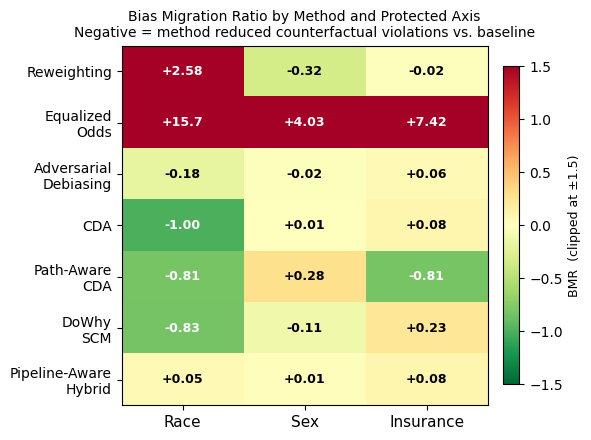

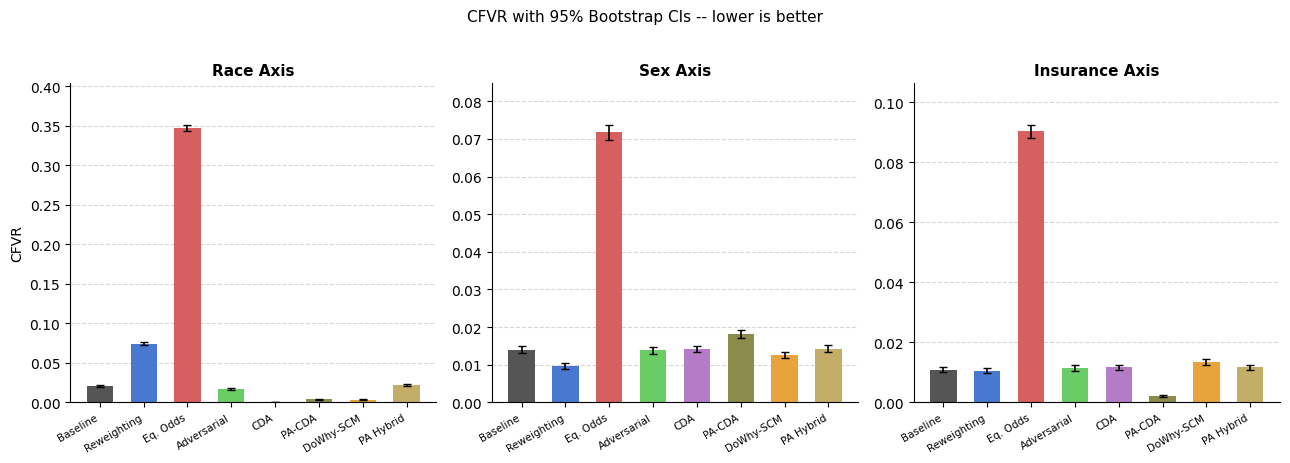

In [57]:
import matplotlib.pyplot as plt
import numpy as np

methods_keys  = ["reweighting", "equalized_odds", "adversarial_debiasing", "cda", "path_aware_cda", "dowhy_scm", "pipeline_aware_hybrid"]
methods_short = ["Reweighting", "Equalized\nOdds", "Adversarial\nDebiasing", "CDA", "Path-Aware\nCDA", "DoWhy\nSCM", "Pipeline-Aware\nHybrid"]
method_order  = ["baseline"] + methods_keys
method_labels = ["Baseline", "Reweighting", "Eq. Odds", "Adversarial", "CDA", "PA-CDA", "DoWhy-SCM", "PA Hybrid"]

bmr_matrix = np.array([
    [float(matrix.loc[matrix["method"]==m, "bmr_race"].values[0]),
     float(matrix.loc[matrix["method"]==m, "bmr_sex"].values[0]),
     float(matrix.loc[matrix["method"]==m, "bmr_ins"].values[0])]
    for m in methods_keys
])

cfvr_data = {}
for ax_key in ["race", "sex", "insurance"]:
    cfvr_data[ax_key] = {}
    for m in method_order:
        row = stat_df[(stat_df["method"]==m) & (stat_df["axis"]==ax_key)].iloc[0]
        cfvr_data[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1, ax1 = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1.imshow(bmr_matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1.set_xticks(range(3))
ax1.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1.set_yticks(range(7))
ax1.set_yticklabels(methods_short, fontsize=10)
for i in range(7):
    for j in range(3):
        cell_val = bmr_matrix[i, j]
        label = f"{cell_val:+.2f}" if abs(cell_val) < 10 else f"{cell_val:+.1f}"
        color = "white" if abs(cell_val) > 0.8 else "black"
        ax1.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1.colorbar(im, ax=ax1, fraction=0.04, pad=0.04)
cbar.set_label("BMR  (clipped at ±1.5)", fontsize=9)
ax1.set_title("Bias Migration Ratio by Method and Protected Axis\n"
              "Negative = method reduced counterfactual violations vs. baseline", fontsize=10)
fig1.tight_layout()
fig1.savefig("/kaggle/working/fig1_bmr_heatmap.png", dpi=150, bbox_inches="tight")

method_colors = ["#555555","#4878CF","#D65F5F","#6ACC65","#B47CC7","#8C8C4A","#E8A33D","#C4AD66"]
ax_keys   = ["race", "sex", "insurance"]
ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes    = [max(cfvr_data["race"][m][2] for m in method_order) * 1.15,
             max(cfvr_data["sex"][m][2]  for m in method_order) * 1.15,
             max(cfvr_data["insurance"][m][2] for m in method_order) * 1.15]

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(ax_keys, ax_titles, ymaxes)):
    ax = axes2[col]
    for i, m in enumerate(method_order):
        mean, lo, hi = cfvr_data[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_labels, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2.suptitle("CFVR with 95% Bootstrap CIs -- lower is better", fontsize=11, y=1.02)
fig2.tight_layout()
fig2.savefig("/kaggle/working/fig2_cfvr_bars.png", dpi=150, bbox_inches="tight")
plt.show()


Figures 4 and 5 below repeat figures 1 and 2 using Level 2 numbers: the BMR heatmap and the CFVR bars now come from the VAE-based counterfactuals and their bootstrap CIs instead of the naive attribute swap.

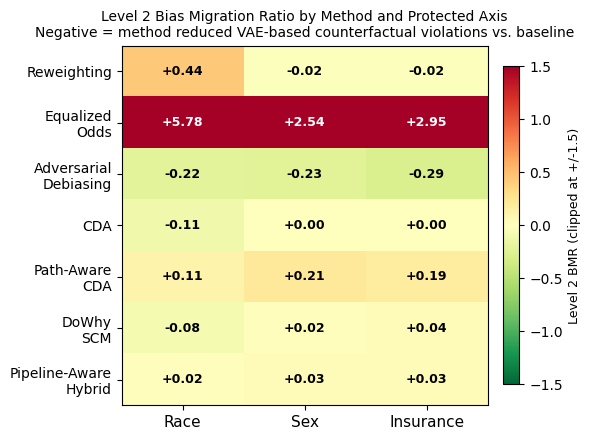

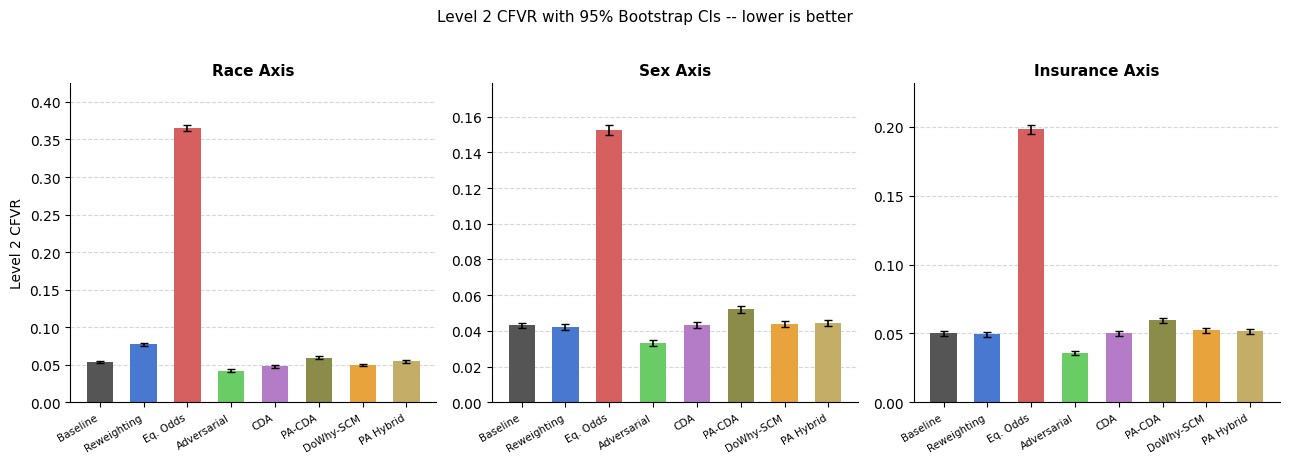

In [58]:
bmr_matrix_l2 = np.array([
    [float(level2_df.loc[level2_df["method"]==m, "bmr_l2_race"].values[0]),
     float(level2_df.loc[level2_df["method"]==m, "bmr_l2_sex"].values[0]),
     float(level2_df.loc[level2_df["method"]==m, "bmr_l2_insurance"].values[0])]
    for m in methods_keys
])

cfvr_data_l2 = {}
for ax_key in axes_list:
    cfvr_data_l2[ax_key] = {}
    for m in method_order:
        row = stat_df_l2[(stat_df_l2["method"]==m) & (stat_df_l2["axis"]==ax_key)].iloc[0]
        cfvr_data_l2[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1_l2, ax1_l2 = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1_l2.imshow(bmr_matrix_l2, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1_l2.set_xticks(range(3))
ax1_l2.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1_l2.set_yticks(range(len(methods_keys)))
ax1_l2.set_yticklabels(methods_short, fontsize=10)
for i in range(len(methods_keys)):
    for j in range(3):
        cell_val = bmr_matrix_l2[i, j]
        label = f"{cell_val:+.2f}" if abs(cell_val) < 10 else f"{cell_val:+.1f}"
        color = "white" if abs(cell_val) > 0.8 else "black"
        ax1_l2.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1_l2.colorbar(im, ax=ax1_l2, fraction=0.04, pad=0.04)
cbar.set_label("Level 2 BMR (clipped at +/-1.5)", fontsize=9)
ax1_l2.set_title("Level 2 Bias Migration Ratio by Method and Protected Axis\n"
                  "Negative = method reduced VAE-based counterfactual violations vs. baseline", fontsize=10)
fig1_l2.tight_layout()
fig1_l2.savefig("/kaggle/working/fig1_bmr_heatmap_level2.png", dpi=150, bbox_inches="tight")

ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes = [max(cfvr_data_l2[ax][m][2] for m in method_order) * 1.15 for ax in axes_list]

fig2_l2, axes2_l2 = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(axes_list, ax_titles, ymaxes)):
    ax = axes2_l2[col]
    for i, m in enumerate(method_order):
        mean, lo, hi = cfvr_data_l2[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_labels, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("Level 2 CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2_l2.suptitle("Level 2 CFVR with 95% Bootstrap CIs -- lower is better", fontsize=11, y=1.02)
fig2_l2.tight_layout()
fig2_l2.savefig("/kaggle/working/fig2_cfvr_bars_level2.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: Pipeline-Aware Pareto Frontier

AUROC vs CFVR tradeoff across lambda values. Each point is one trained model. Top-left = ideal (high accuracy, low counterfactual violations). The baseline is shown for reference.


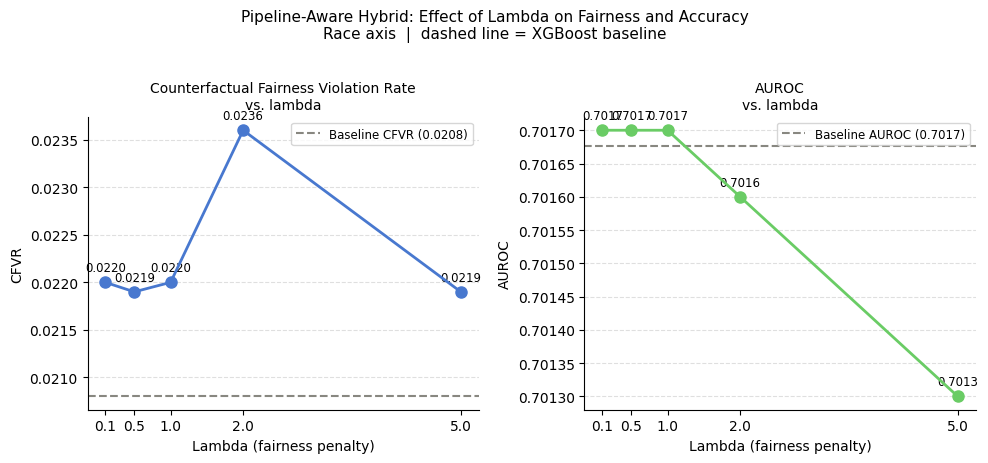

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

pareto_df = pd.read_csv("/kaggle/working/lambda_pareto.csv").sort_values("lambda").reset_index(drop=True)

fig, (ax_cfvr, ax_auc) = plt.subplots(1, 2, figsize=(10, 4.5))

lam = pareto_df["lambda"].values
cfvr = pareto_df["cfvr"].values
auroc = pareto_df["auroc"].values

color = "#4878CF"

ax_cfvr.plot(lam, cfvr, marker="o", color=color, linewidth=2, markersize=8, zorder=5)
ax_cfvr.axhline(cfvr_base, color="#888780", linestyle="--", linewidth=1.5, label=f"Baseline CFVR ({cfvr_base:.4f})")
for x, y in zip(lam, cfvr):
    ax_cfvr.annotate(f"{y:.4f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8.5)
ax_cfvr.set_xlabel("Lambda (fairness penalty)", fontsize=10)
ax_cfvr.set_ylabel("CFVR", fontsize=10)
ax_cfvr.set_title("Counterfactual Fairness Violation Rate\nvs. lambda", fontsize=10)
ax_cfvr.set_xticks(lam)
ax_cfvr.legend(fontsize=8.5)
ax_cfvr.spines["top"].set_visible(False)
ax_cfvr.spines["right"].set_visible(False)
ax_cfvr.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_cfvr.set_axisbelow(True)

ax_auc.plot(lam, auroc, marker="o", color="#6ACC65", linewidth=2, markersize=8, zorder=5)
ax_auc.axhline(auroc_base, color="#888780", linestyle="--", linewidth=1.5, label=f"Baseline AUROC ({auroc_base:.4f})")
for x, y in zip(lam, auroc):
    ax_auc.annotate(f"{y:.4f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8.5)
ax_auc.set_xlabel("Lambda (fairness penalty)", fontsize=10)
ax_auc.set_ylabel("AUROC", fontsize=10)
ax_auc.set_title("AUROC\nvs. lambda", fontsize=10)
ax_auc.set_xticks(lam)
ax_auc.legend(fontsize=8.5)
ax_auc.spines["top"].set_visible(False)
ax_auc.spines["right"].set_visible(False)
ax_auc.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_auc.set_axisbelow(True)

fig.suptitle("Pipeline-Aware Hybrid: Effect of Lambda on Fairness and Accuracy\n"
             "Race axis  |  dashed line = XGBoost baseline", fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig("/kaggle/working/fig3_lambda_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


In [60]:
axes_s2 = {
    "race":      (RACES,      "race_clean"),
    "sex":       (SEXES,      "sex"),
    "insurance": (INS_GROUPS, "insurance_clean"),
}

stage2_rows = []
for m in continuous_methods:
    orig = orig_scores[m]
    for ax, (groups, gcol) in axes_s2.items():
        max_delta = np.zeros(n_val)
        for g in groups:
            if g not in cf_scores[m][ax]:
                continue
            delta = np.abs(orig - cf_scores[m][ax][g])
            max_delta = np.maximum(max_delta, delta)
        for delta_thr in [0.005, 0.01, 0.02, 0.05]:
            cfvr_s2 = round((max_delta > delta_thr).mean(), 4)
            stage2_rows.append({"method": m, "axis": ax, "delta": delta_thr, "cfvr_stage2": cfvr_s2})

stage2_df = pd.DataFrame(stage2_rows)

print("STAGE 2 vs STAGE 3 (delta=0.01), by method")
for m in continuous_methods:
    print(f"\n{m}")
    for ax_name in ["race", "sex", "insurance"]:
        s2 = stage2_df[(stage2_df["method"]==m) & (stage2_df["axis"]==ax_name) & (stage2_df["delta"]==0.01)]["cfvr_stage2"].values[0]
        s3 = cfvr_level1_lookup[ax_name][m]
        absorb = round(1 - s3/s2, 3) if s2 > 0 else float("nan")
        print(f"  {ax_name:<12} stage2={s2:<8.4f} stage3={s3:<8.4f} {absorb:.1%} absorbed by threshold")

stage2_df.to_parquet("/kaggle/working/stage2_cfvr.parquet", index=False)


STAGE 2 vs STAGE 3 (delta=0.01), by method

baseline
  race         stage2=0.8599   stage3=0.0208   97.6% absorbed by threshold
  sex          stage2=0.4465   stage3=0.0141   96.8% absorbed by threshold
  insurance    stage2=0.4785   stage3=0.0108   97.7% absorbed by threshold

reweighting
  race         stage2=0.9494   stage3=0.0744   92.2% absorbed by threshold
  sex          stage2=0.4184   stage3=0.0096   97.7% absorbed by threshold
  insurance    stage2=0.4740   stage3=0.0106   97.8% absorbed by threshold

adversarial_debiasing
  race         stage2=0.3408   stage3=0.0171   95.0% absorbed by threshold
  sex          stage2=0.4737   stage3=0.0138   97.1% absorbed by threshold
  insurance    stage2=0.4468   stage3=0.0114   97.4% absorbed by threshold

cda
  race         stage2=0.0000   stage3=0.0000   nan% absorbed by threshold
  sex          stage2=0.4579   stage3=0.0142   96.9% absorbed by threshold
  insurance    stage2=0.4685   stage3=0.0117   97.5% absorbed by threshold

path_a

## Final Test-Set Evaluation

Everything above was developed and tuned on val. This section is a single, final pass on the held-out test set. No thresholds are re-derived here -- we apply the exact thresholds already fixed above and see how the numbers hold up on data none of the methods have touched.


In [61]:
continuous_methods_test = {
    "baseline":              (score_fn_base, threshold_base),
    "reweighting":           (score_fn_rw,   threshold_rw),
    "adversarial_debiasing": (score_fn_adv,  threshold_adv),
    "cda":                   (score_fn_cda,  threshold_cda),
    "path_aware_cda":        (score_fn_pace, threshold_pace),
    "dowhy_scm":             (score_fn_dowhy, threshold_dowhy),
    "pipeline_aware_hybrid": (score_fn_pa,   threshold_pa),
}

test_scores   = {m: fn(test) for m, (fn, _) in continuous_methods_test.items()}
test_enrolled = {m: (test_scores[m] >= thr).astype(int) for m, (_, thr) in continuous_methods_test.items()}
test_enrolled["equalized_odds"] = predict_fn_eo(test)

test_auroc = {m: roc_auc_score(y_test, s) for m, s in test_scores.items()}

method_order_all = ["baseline", "reweighting", "equalized_odds", "adversarial_debiasing", "cda", "path_aware_cda", "dowhy_scm", "pipeline_aware_hybrid"]
for m in method_order_all:
    auc_str = f"{test_auroc[m]:.4f}" if m in test_auroc else "n/a"
    print(f"{m:25s} enrollment_rate={test_enrolled[m].mean():.3f}  auroc={auc_str}")


baseline                  enrollment_rate=0.095  auroc=0.7006
reweighting               enrollment_rate=0.094  auroc=0.6919
equalized_odds            enrollment_rate=0.355  auroc=n/a
adversarial_debiasing     enrollment_rate=0.104  auroc=0.6845
cda                       enrollment_rate=0.094  auroc=0.6970
path_aware_cda            enrollment_rate=0.124  auroc=0.6932
dowhy_scm                 enrollment_rate=0.097  auroc=0.6975
pipeline_aware_hybrid     enrollment_rate=0.099  auroc=0.7000


In [62]:
test_race_dfs = {}
for m in method_order_all:
    df = test[["race_clean"]].copy()
    df["enrolled"] = test_enrolled[m]
    df["y_true"] = y_test.values
    test_race_dfs[m] = df

test_dp_ratio_race = {}
for m, df in test_race_dfs.items():
    metrics = compute_fairness_metrics(df, "race_clean", "enrolled", "y_true")
    test_dp_ratio_race[m] = metrics["enrollment_rate"].min() / metrics["enrollment_rate"].max()

cfvr_test_race = {}
for m, (fn, thr) in continuous_methods_test.items():
    cfvr_test_race[m], _ = compute_cfvr(fn, test, thr)
cfvr_test_race["equalized_odds"], _ = cfvr_binary(predict_fn_eo, test)

cfvr_base_test = cfvr_test_race["baseline"]
bmr_test_race = {
    m: round((c - cfvr_base_test) / cfvr_base_test, 4) if cfvr_base_test > 0 else 0.0
    for m, c in cfvr_test_race.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={test_dp_ratio_race[m]:.3f}  cfvr={cfvr_test_race[m]:.4f}  bmr={bmr_test_race[m]:+.4f}")


baseline                  dp_ratio=0.420  cfvr=0.0197  bmr=+0.0000
reweighting               dp_ratio=0.705  cfvr=0.0728  bmr=+2.6954
equalized_odds            dp_ratio=0.883  cfvr=0.3500  bmr=+16.7665
adversarial_debiasing     dp_ratio=0.492  cfvr=0.0168  bmr=-0.1472
cda                       dp_ratio=0.512  cfvr=0.0000  bmr=-1.0000
path_aware_cda            dp_ratio=0.488  cfvr=0.0041  bmr=-0.7919
dowhy_scm                 dp_ratio=0.500  cfvr=0.0034  bmr=-0.8274
pipeline_aware_hybrid     dp_ratio=0.430  cfvr=0.0215  bmr=+0.0914


In [63]:
dp_test_sex = {m: dp_ratio_from_enrolled(test_enrolled[m], test["sex"]) for m in test_enrolled}

cfvr_test_sex = {
    m: compute_cfvr_attr(fn, test, thr, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    for m, (fn, thr) in continuous_methods_test.items()
}
cfvr_test_sex["equalized_odds"] = cfvr_binary_attr(predict_fn_eo, test, "sex", "sex_enc", SEXES, SEX_TO_ENC)

cfvr_base_test_sex = cfvr_test_sex["baseline"]
bmr_test_sex = {
    m: round((c - cfvr_base_test_sex) / cfvr_base_test_sex, 4) if cfvr_base_test_sex > 0 else 0.0
    for m, c in cfvr_test_sex.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={dp_test_sex[m]:.3f}  cfvr={cfvr_test_sex[m]:.4f}  bmr={bmr_test_sex[m]:+.4f}")


baseline                  dp_ratio=0.825  cfvr=0.0134  bmr=+0.0000
reweighting               dp_ratio=0.856  cfvr=0.0094  bmr=-0.2985
equalized_odds            dp_ratio=0.847  cfvr=0.0726  bmr=+4.4179
adversarial_debiasing     dp_ratio=0.838  cfvr=0.0142  bmr=+0.0597
cda                       dp_ratio=0.843  cfvr=0.0130  bmr=-0.0299
path_aware_cda            dp_ratio=0.820  cfvr=0.0194  bmr=+0.4478
dowhy_scm                 dp_ratio=0.836  cfvr=0.0126  bmr=-0.0597
pipeline_aware_hybrid     dp_ratio=0.828  cfvr=0.0137  bmr=+0.0224


In [64]:
dp_test_ins = {m: dp_ratio_from_enrolled(test_enrolled[m], test["insurance_clean"]) for m in test_enrolled}

cfvr_test_ins = {
    m: compute_cfvr_attr(fn, test, thr, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC)
    for m, (fn, thr) in continuous_methods_test.items()
}
cfvr_test_ins["equalized_odds"] = cfvr_binary_attr(predict_fn_eo, test, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC)

cfvr_base_test_ins = cfvr_test_ins["baseline"]
bmr_test_ins = {
    m: round((c - cfvr_base_test_ins) / cfvr_base_test_ins, 4) if cfvr_base_test_ins > 0 else 0.0
    for m, c in cfvr_test_ins.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={dp_test_ins[m]:.3f}  cfvr={cfvr_test_ins[m]:.4f}  bmr={bmr_test_ins[m]:+.4f}")


baseline                  dp_ratio=0.477  cfvr=0.0109  bmr=+0.0000
reweighting               dp_ratio=0.542  cfvr=0.0101  bmr=-0.0734
equalized_odds            dp_ratio=0.672  cfvr=0.0909  bmr=+7.3394
adversarial_debiasing     dp_ratio=0.498  cfvr=0.0118  bmr=+0.0826
cda                       dp_ratio=0.474  cfvr=0.0110  bmr=+0.0092
path_aware_cda            dp_ratio=0.513  cfvr=0.0020  bmr=-0.8165
dowhy_scm                 dp_ratio=0.506  cfvr=0.0130  bmr=+0.1927
pipeline_aware_hybrid     dp_ratio=0.476  cfvr=0.0111  bmr=+0.0183


In [65]:
test_matrix = pd.DataFrame([
    {
        "method":        m,
        "dp_ratio_race": round(test_dp_ratio_race[m], 3),
        "cfvr_race":     cfvr_test_race[m],
        "bmr_race":      bmr_test_race[m],
        "dp_ratio_sex":  round(dp_test_sex[m], 3),
        "cfvr_sex":      cfvr_test_sex[m],
        "bmr_sex":       bmr_test_sex[m],
        "dp_ratio_ins":  round(dp_test_ins[m], 3),
        "cfvr_ins":      cfvr_test_ins[m],
        "bmr_ins":       bmr_test_ins[m],
        "auroc":         round(test_auroc[m], 4) if m in test_auroc else float("nan"),
        "f1":            round(f1_score(y_test, test_enrolled[m]), 4),
    }
    for m in method_order_all
])

print("TEST SET -- RACE AXIS")
print(test_matrix[["method", "dp_ratio_race", "cfvr_race", "bmr_race", "auroc"]].to_string(index=False))

print("\nTEST SET -- SEX AXIS")
print(test_matrix[["method", "dp_ratio_sex", "cfvr_sex", "bmr_sex"]].to_string(index=False))

print("\nTEST SET -- INSURANCE AXIS")
print(test_matrix[["method", "dp_ratio_ins", "cfvr_ins", "bmr_ins"]].to_string(index=False))

test_matrix.to_parquet("/kaggle/working/test_full_experimental_matrix.parquet", index=False)


TEST SET -- RACE AXIS
               method  dp_ratio_race  cfvr_race  bmr_race  auroc
             baseline          0.420     0.0197    0.0000 0.7006
          reweighting          0.705     0.0728    2.6954 0.6919
       equalized_odds          0.883     0.3500   16.7665    NaN
adversarial_debiasing          0.492     0.0168   -0.1472 0.6845
                  cda          0.512     0.0000   -1.0000 0.6970
       path_aware_cda          0.488     0.0041   -0.7919 0.6932
            dowhy_scm          0.500     0.0034   -0.8274 0.6975
pipeline_aware_hybrid          0.430     0.0215    0.0914 0.7000

TEST SET -- SEX AXIS
               method  dp_ratio_sex  cfvr_sex  bmr_sex
             baseline         0.825    0.0134   0.0000
          reweighting         0.856    0.0094  -0.2985
       equalized_odds         0.847    0.0726   4.4179
adversarial_debiasing         0.838    0.0142   0.0597
                  cda         0.843    0.0130  -0.0299
       path_aware_cda         0.820    0.

In [66]:
n_test = len(test)

orig_scores_test = {m: fn(test) for m, (fn, _) in continuous_methods_test.items()}
eo_orig_test = test_enrolled["equalized_odds"].copy()

cf_scores_test = {m: {ax: {} for ax in axes_cfg} for m in continuous_methods_test}
cf_eo_test = {ax: {} for ax in axes_cfg}

for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
    for g in groups:
        mask = (test[gcol].values != g)
        if mask.sum() == 0:
            continue
        cf = test.copy()
        cf.loc[cf.index[mask], gcol] = g
        cf.loc[cf.index[mask], ecol] = enc_map[g]
        for m, (fn, _) in continuous_methods_test.items():
            cf_scores_test[m][ax][g] = fn(cf)
        cf_eo_test[ax][g] = predict_fn_eo(cf)


In [67]:
N_BOOTSTRAP = 1000
np.random.seed(42)

all_method_keys_test = list(continuous_methods_test) + ["equalized_odds"]
boot_cfvr_test = {m: {ax: np.zeros(N_BOOTSTRAP) for ax in axes_cfg} for m in all_method_keys_test}

for b in range(N_BOOTSTRAP):
    idx = np.random.choice(n_test, n_test, replace=True)

    for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
        orig_groups = test[gcol].values[idx]

        for m, (fn, thr) in continuous_methods_test.items():
            orig_enr = (orig_scores_test[m][idx] >= thr).astype(int)
            any_flip = np.zeros(len(idx), dtype=int)
            for g in groups:
                if g not in cf_scores_test[m][ax]:
                    continue
                mask_g  = (orig_groups != g)
                cf_enr  = (cf_scores_test[m][ax][g][idx] >= thr).astype(int)
                flipped = ((cf_enr != orig_enr) & mask_g).astype(int)
                any_flip = np.maximum(any_flip, flipped)
            boot_cfvr_test[m][ax][b] = any_flip.mean()

        orig_enr_eo = eo_orig_test[idx]
        any_flip_eo = np.zeros(len(idx), dtype=int)
        for g in groups:
            if g not in cf_eo_test[ax]:
                continue
            mask_g      = (orig_groups != g)
            cf_enr_eo   = cf_eo_test[ax][g][idx]
            flipped     = ((cf_enr_eo != orig_enr_eo) & mask_g).astype(int)
            any_flip_eo = np.maximum(any_flip_eo, flipped)
        boot_cfvr_test["equalized_odds"][ax][b] = any_flip_eo.mean()

    if (b + 1) % 100 == 0:
        print(f"bootstrap {b+1}/{N_BOOTSTRAP}")


bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [68]:
stat_rows_test = []
for ax in axes_list:
    base_boot = boot_cfvr_test["baseline"][ax]
    for m in method_order:
        m_boot  = boot_cfvr_test[m][ax]
        ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])

        if m == "baseline":
            p_val, h = float("nan"), 0.0
            diff_ci_lo = diff_ci_hi = 0.0
        else:
            diff = base_boot - m_boot
            diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])
            p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
            h = cohens_h(base_boot.mean(), m_boot.mean())

        stat_rows_test.append({
            "method":     m,
            "axis":       ax,
            "cfvr_mean":  round(float(m_boot.mean()), 4),
            "ci_lo":      round(float(ci_lo), 4),
            "ci_hi":      round(float(ci_hi), 4),
            "diff_ci_lo": round(float(diff_ci_lo), 4),
            "diff_ci_hi": round(float(diff_ci_hi), 4),
            "p_value":    round(p_val, 6) if not (p_val != p_val) else float("nan"),
            "cohens_h":   round(h, 3),
        })

stat_df_test = pd.DataFrame(stat_rows_test)

mask = stat_df_test["method"] != "baseline"
pvals = stat_df_test.loc[mask, "p_value"].fillna(1.0).values
_, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
stat_df_test.loc[mask, "p_adj"] = p_adj.round(6)

for ax in axes_list:
    print(f"\nTEST SET -- {ax.upper()} AXIS")
    sub = stat_df_test[stat_df_test["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))

stat_df_test.to_parquet("/kaggle/working/statistical_results_test.parquet", index=False)



TEST SET -- RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0197 0.0185 0.0208      0.0000      0.0000    NaN     0.000
          reweighting     0.0728 0.0708 0.0749     -0.0552     -0.0512    0.0    -0.265
       equalized_odds     0.3487 0.3451 0.3526     -0.3330     -0.3252    0.0    -0.982
adversarial_debiasing     0.0168 0.0157 0.0178      0.0014      0.0044    0.0     0.022
                  cda     0.0000 0.0000 0.0000      0.0185      0.0208    0.0     0.281
       path_aware_cda     0.0041 0.0036 0.0047      0.0144      0.0168    0.0     0.153
            dowhy_scm     0.0034 0.0029 0.0039      0.0152      0.0174    0.0     0.165
pipeline_aware_hybrid     0.0215 0.0204 0.0227     -0.0029     -0.0009    0.0    -0.013

TEST SET -- SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h
             baseline     0.0134 0.0125 0.0144      0.0000      0.0000   

## MPPD: Test-Set Replication

Same real-patient matching as the val-set MPPD check, reusing the scaler fit on val 


In [69]:
X_mppd_test = scaler_mppd.transform(test[MPPD_FEATURES].values)

race_arr_test = test["race_clean"].values
ref_pos_test  = np.where(race_arr_test == reference_race)[0]
nn_ref_test   = NearestNeighbors(n_neighbors=1).fit(X_mppd_test[ref_pos_test])

mppd_matches_test = {}
for race in RACES:
    if race == reference_race:
        continue
    g_pos = np.where(race_arr_test == race)[0]
    if len(g_pos) == 0:
        continue
    _, nn_rel = nn_ref_test.kneighbors(X_mppd_test[g_pos])
    matched_pos = ref_pos_test[nn_rel.flatten()]
    mppd_matches_test[race] = (g_pos, matched_pos)

mppd_rows_test = []
for m in continuous_methods_test:
    scores = orig_scores_test[m]
    for race, (g_pos, matched_pos) in mppd_matches_test.items():
        diffs = np.abs(scores[g_pos] - scores[matched_pos])
        mppd_rows_test.append({"method": m, "race": race, "mppd": round(float(diffs.mean()), 4), "n_pairs": len(g_pos)})

eo_scores_arr_test = eo_orig_test.astype(float)
for race, (g_pos, matched_pos) in mppd_matches_test.items():
    diffs = np.abs(eo_scores_arr_test[g_pos] - eo_scores_arr_test[matched_pos])
    mppd_rows_test.append({"method": "equalized_odds", "race": race, "mppd": round(float(diffs.mean()), 4), "n_pairs": len(g_pos)})

mppd_df_test = pd.DataFrame(mppd_rows_test)
mppd_pivot_test = mppd_df_test.pivot(index="method", columns="race", values="mppd").reindex(method_order_all)

print(f"TEST SET -- MPPD (reference group: {reference_race})")
print(mppd_pivot_test.to_string())

mppd_df_test.to_parquet("/kaggle/working/mppd_results_test.parquet", index=False)


TEST SET -- MPPD (reference group: White)
race                    Asian  Black/African American  Hispanic/Latino  Other/Unknown
method                                                                               
baseline               0.0942                  0.0990           0.0958         0.1006
reweighting            0.0944                  0.0951           0.0933         0.0879
equalized_odds         0.3054                  0.3406           0.3307         0.3310
adversarial_debiasing  0.0828                  0.0880           0.0867         0.0702
cda                    0.0928                  0.0983           0.0960         0.0792
path_aware_cda         0.0889                  0.0937           0.0916         0.0756
dowhy_scm              0.0928                  0.0984           0.0963         0.0805
pipeline_aware_hybrid  0.0947                  0.0999           0.0968         0.1004


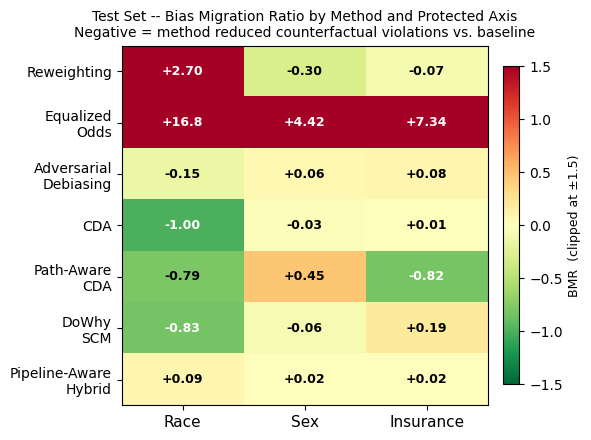

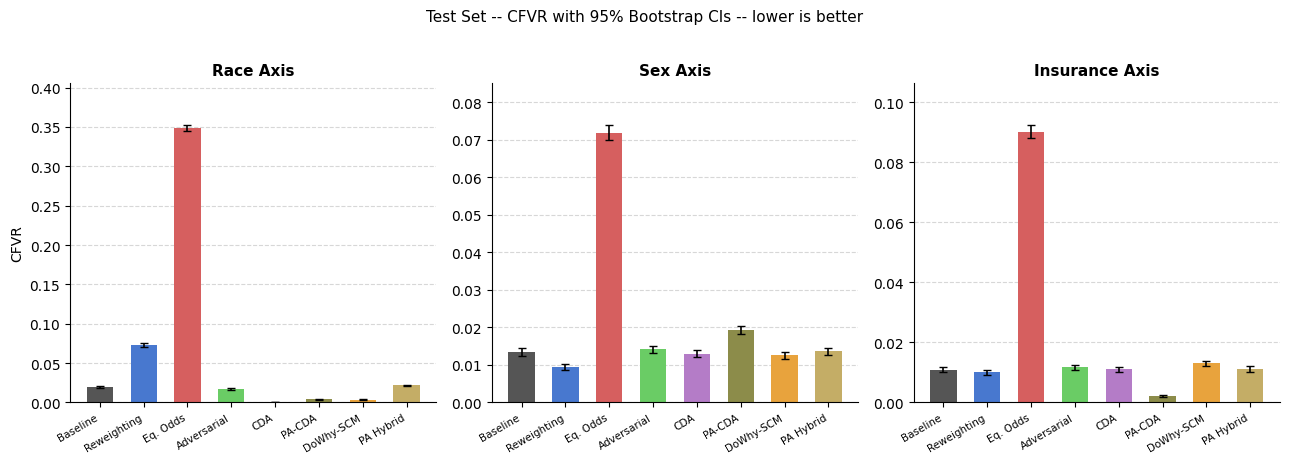

In [70]:
methods_keys_t  = ["reweighting", "equalized_odds", "adversarial_debiasing", "cda", "path_aware_cda", "dowhy_scm", "pipeline_aware_hybrid"]
methods_short_t = ["Reweighting", "Equalized\nOdds", "Adversarial\nDebiasing", "CDA", "Path-Aware\nCDA", "DoWhy\nSCM", "Pipeline-Aware\nHybrid"]
method_order_t  = ["baseline"] + methods_keys_t
method_labels_t = ["Baseline", "Reweighting", "Eq. Odds", "Adversarial", "CDA", "PA-CDA", "DoWhy-SCM", "PA Hybrid"]

bmr_matrix_test = np.array([
    [float(test_matrix.loc[test_matrix["method"]==m, "bmr_race"].values[0]),
     float(test_matrix.loc[test_matrix["method"]==m, "bmr_sex"].values[0]),
     float(test_matrix.loc[test_matrix["method"]==m, "bmr_ins"].values[0])]
    for m in methods_keys_t
])

cfvr_data_test = {}
for ax_key in ["race", "sex", "insurance"]:
    cfvr_data_test[ax_key] = {}
    for m in method_order_t:
        row = stat_df_test[(stat_df_test["method"]==m) & (stat_df_test["axis"]==ax_key)].iloc[0]
        cfvr_data_test[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1t, ax1t = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1t.imshow(bmr_matrix_test, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1t.set_xticks(range(3))
ax1t.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1t.set_yticks(range(7))
ax1t.set_yticklabels(methods_short_t, fontsize=10)
for i in range(7):
    for j in range(3):
        v = bmr_matrix_test[i, j]
        label = f"{v:+.2f}" if abs(v) < 10 else f"{v:+.1f}"
        color = "white" if abs(v) > 0.8 else "black"
        ax1t.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1t.colorbar(im, ax=ax1t, fraction=0.04, pad=0.04)
cbar.set_label("BMR  (clipped at \u00b11.5)", fontsize=9)
ax1t.set_title("Test Set -- Bias Migration Ratio by Method and Protected Axis\n"
               "Negative = method reduced counterfactual violations vs. baseline", fontsize=10)
fig1t.tight_layout()
fig1t.savefig("/kaggle/working/fig1_bmr_heatmap_test.png", dpi=150, bbox_inches="tight")

method_colors = ["#555555","#4878CF","#D65F5F","#6ACC65","#B47CC7","#8C8C4A","#E8A33D","#C4AD66"]
ax_keys   = ["race", "sex", "insurance"]
ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes    = [max(cfvr_data_test["race"][m][2] for m in method_order_t) * 1.15,
             max(cfvr_data_test["sex"][m][2]  for m in method_order_t) * 1.15,
             max(cfvr_data_test["insurance"][m][2] for m in method_order_t) * 1.15]

fig2t, axes2t = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(ax_keys, ax_titles, ymaxes)):
    ax = axes2t[col]
    for i, m in enumerate(method_order_t):
        mean, lo, hi = cfvr_data_test[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order_t)))
    ax.set_xticklabels(method_labels_t, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2t.suptitle("Test Set -- CFVR with 95% Bootstrap CIs -- lower is better", fontsize=11, y=1.02)
fig2t.tight_layout()
fig2t.savefig("/kaggle/working/fig2_cfvr_bars_test.png", dpi=150, bbox_inches="tight")
plt.show()


In [71]:
print("VAL vs TEST -- race axis dp_ratio and CFVR")
for m in method_order_all:
    dp_val = matrix.loc[matrix["method"]==m, "dp_ratio_race"].values[0]
    dp_tst = test_matrix.loc[test_matrix["method"]==m, "dp_ratio_race"].values[0]
    cf_val = matrix.loc[matrix["method"]==m, "cfvr_race"].values[0]
    cf_tst = test_matrix.loc[test_matrix["method"]==m, "cfvr_race"].values[0]
    print(f"{m:25s} dp_ratio: val={dp_val:.3f} test={dp_tst:.3f}   cfvr: val={cf_val:.4f} test={cf_tst:.4f}")


VAL vs TEST -- race axis dp_ratio and CFVR
baseline                  dp_ratio: val=0.371 test=0.420   cfvr: val=0.0208 test=0.0197
reweighting               dp_ratio: val=0.603 test=0.705   cfvr: val=0.0744 test=0.0728
equalized_odds            dp_ratio: val=0.910 test=0.883   cfvr: val=0.3474 test=0.3500
adversarial_debiasing     dp_ratio: val=0.474 test=0.492   cfvr: val=0.0171 test=0.0168
cda                       dp_ratio: val=0.435 test=0.512   cfvr: val=0.0000 test=0.0000
path_aware_cda            dp_ratio: val=0.429 test=0.488   cfvr: val=0.0039 test=0.0041
dowhy_scm                 dp_ratio: val=0.429 test=0.500   cfvr: val=0.0035 test=0.0034
pipeline_aware_hybrid     dp_ratio: val=0.359 test=0.430   cfvr: val=0.0219 test=0.0215


In [72]:
stage2_rows_test = []
for m in continuous_methods_test:
    orig = orig_scores_test[m]
    for ax, (groups, gcol) in axes_s2.items():
        md_ = np.zeros(n_test)
        for g in groups:
            if g not in cf_scores_test[m][ax]:
                continue
            delta = np.abs(orig - cf_scores_test[m][ax][g])
            md_ = np.maximum(md_, delta)
        for delta_thr in [0.005, 0.01, 0.02, 0.05]:
            cfvr_s2 = round((md_ > delta_thr).mean(), 4)
            stage2_rows_test.append({"method": m, "axis": ax, "delta": delta_thr, "cfvr_stage2": cfvr_s2})

stage2_df_test = pd.DataFrame(stage2_rows_test)

stage3_cfvr_lookup_test = {
    "race": cfvr_test_race,
    "sex": cfvr_test_sex,
    "insurance": cfvr_test_ins,
}
print("TEST SET -- STAGE 2 vs STAGE 3 (delta=0.01), by method")
for m in continuous_methods_test:
    print(f"\n{m}")
    for ax_name in ["race", "sex", "insurance"]:
        s2 = stage2_df_test[(stage2_df_test["method"]==m) & (stage2_df_test["axis"]==ax_name) & (stage2_df_test["delta"]==0.01)]["cfvr_stage2"].values[0]
        s3 = stage3_cfvr_lookup_test[ax_name][m]
        absorb = round(1 - s3/s2, 3) if s2 > 0 else float("nan")
        print(f"  {ax_name:<12} stage2={s2:<8.4f} stage3={s3:<8.4f} {absorb:.1%} absorbed by threshold")

stage2_df_test.to_parquet("/kaggle/working/stage2_cfvr_test.parquet", index=False)


TEST SET -- STAGE 2 vs STAGE 3 (delta=0.01), by method

baseline
  race         stage2=0.8606   stage3=0.0197   97.7% absorbed by threshold
  sex          stage2=0.4492   stage3=0.0134   97.0% absorbed by threshold
  insurance    stage2=0.4762   stage3=0.0109   97.7% absorbed by threshold

reweighting
  race         stage2=0.9505   stage3=0.0728   92.3% absorbed by threshold
  sex          stage2=0.4201   stage3=0.0094   97.8% absorbed by threshold
  insurance    stage2=0.4744   stage3=0.0101   97.9% absorbed by threshold

adversarial_debiasing
  race         stage2=0.3367   stage3=0.0168   95.0% absorbed by threshold
  sex          stage2=0.4726   stage3=0.0142   97.0% absorbed by threshold
  insurance    stage2=0.4483   stage3=0.0118   97.4% absorbed by threshold

cda
  race         stage2=0.0000   stage3=0.0000   nan% absorbed by threshold
  sex          stage2=0.4614   stage3=0.0130   97.2% absorbed by threshold
  insurance    stage2=0.4690   stage3=0.0110   97.7% absorbed by thres

## Equalized Odds Gap, Calibration, and Path-Specific Effects: Test Set

Same three checks as the val section above, run on the held-out test set with no refitting. The functions defined above are reused as is.

The intersectional CFVR and BMR check is included here too, again reusing the val-defined pair-swap function.


In [73]:
eo_gap_groups_test = {
    "race":      (test["race_clean"].values,     RACES),
    "sex":       (test["sex"].values,             SEXES),
    "insurance": (test["insurance_clean"].values, INS_GROUPS),
}

eo_gap_rows_test = []
for m in method_order_all:
    preds = test_enrolled[m]
    for ax, (labels, groups) in eo_gap_groups_test.items():
        tpr_gap, fpr_gap = compute_eo_gap(y_test.values, preds, labels, groups)
        eo_gap_rows_test.append({"method": m, "axis": ax, "tpr_gap": tpr_gap, "fpr_gap": fpr_gap})

eo_gap_df_test = pd.DataFrame(eo_gap_rows_test)

print("TEST SET -- TPR gap by method and axis:")
print(eo_gap_df_test.pivot(index="method", columns="axis", values="tpr_gap").reindex(method_order_all).to_string())
print("\nTEST SET -- FPR gap by method and axis:")
print(eo_gap_df_test.pivot(index="method", columns="axis", values="fpr_gap").reindex(method_order_all).to_string())

eo_gap_df_test.to_parquet("/kaggle/working/eo_gap_test.parquet", index=False)


TEST SET -- TPR gap by method and axis:
axis                   insurance    race     sex
method                                          
baseline                  0.1111  0.0743  0.0134
reweighting               0.0977  0.0758  0.0049
equalized_odds            0.1124  0.0325  0.0545
adversarial_debiasing     0.1100  0.0500  0.0097
cda                       0.1135  0.0667  0.0067
path_aware_cda            0.1178  0.0639  0.0224
dowhy_scm                 0.1173  0.0609  0.0087
pipeline_aware_hybrid     0.1176  0.0886  0.0122

TEST SET -- FPR gap by method and axis:
axis                   insurance    race     sex
method                                          
baseline                  0.0595  0.0587  0.0167
reweighting               0.0477  0.0291  0.0143
equalized_odds            0.1254  0.0262  0.0553
adversarial_debiasing     0.0555  0.0528  0.0177
cda                       0.0585  0.0499  0.0156
path_aware_cda            0.0685  0.0714  0.0216
dowhy_scm                 0.0600  0.0

In [74]:
test["group_race_sex"] = test["race_clean"] + " | " + test["sex"]
test["group_race_ins"] = test["race_clean"] + " | " + test["insurance_clean"]

ece_group_cols_test = {
    "race": "race_clean", "sex": "sex", "insurance": "insurance_clean",
    "race_x_sex": "group_race_sex", "race_x_ins": "group_race_ins",
}

ece_summary_rows_test = []
ece_detail_rows_test  = []
for m in continuous_methods_test:
    probs = test_scores[m]
    overall_ece = compute_ece(y_test.values, probs)
    worst_by_axis = {}
    for ax, gcol in ece_group_cols_test.items():
        for g in test[gcol].dropna().unique():
            mask = test[gcol].values == g
            g_ece = compute_ece(y_test.values[mask], probs[mask])
            ece_detail_rows_test.append({"method": m, "axis": ax, "group": g, "n": int(mask.sum()), "ece": g_ece})
        worst_by_axis[ax] = max(r["ece"] for r in ece_detail_rows_test if r["method"] == m and r["axis"] == ax)
    ece_summary_rows_test.append({
        "method":             m,
        "ece_overall":        overall_ece,
        "ece_max_race":       worst_by_axis["race"],
        "ece_max_sex":        worst_by_axis["sex"],
        "ece_max_insurance":  worst_by_axis["insurance"],
        "ece_max_race_x_sex": worst_by_axis["race_x_sex"],
        "ece_max_race_x_ins": worst_by_axis["race_x_ins"],
    })

ece_summary_df_test = pd.DataFrame(ece_summary_rows_test)
ece_detail_df_test  = pd.DataFrame(ece_detail_rows_test)

print(ece_summary_df_test.to_string(index=False))

ece_summary_df_test.to_parquet("/kaggle/working/ece_summary_test.parquet", index=False)
ece_detail_df_test.to_parquet("/kaggle/working/ece_detail_test.parquet", index=False)


               method  ece_overall  ece_max_race  ece_max_sex  ece_max_insurance  ece_max_race_x_sex  ece_max_race_x_ins
             baseline       0.0023        0.0228       0.0061             0.0178              0.0304              0.1005
          reweighting       0.0041        0.0466       0.0071             0.0194              0.0515              0.0962
adversarial_debiasing       0.0044        0.0537       0.0088             0.0193              0.0561              0.0854
                  cda       0.0042        0.0499       0.0080             0.0159              0.0523              0.1032
       path_aware_cda       0.0036        0.0485       0.0050             0.0220              0.0513              0.0953
            dowhy_scm       0.0051        0.0457       0.0087             0.0231              0.0486              0.1062
pipeline_aware_hybrid       0.0029        0.0214       0.0063             0.0184              0.0299              0.1050


In [75]:
mediator_cf_test = {race: build_mediator_cf_full(test, race) for race in RACES}

direct_effect_lookup_test = {m: cfvr_test_race[m] for m in method_order_all}

path_effect_methods_test = {
    "baseline":              (score_fn_base,  threshold_base,  False),
    "reweighting":           (score_fn_rw,    threshold_rw,    False),
    "equalized_odds":        (predict_fn_eo,  None,            True),
    "adversarial_debiasing": (score_fn_adv,   threshold_adv,   False),
    "cda":                   (score_fn_cda,   threshold_cda,   False),
    "path_aware_cda":        (score_fn_pace,  threshold_pace,  False),
    "dowhy_scm":             (score_fn_dowhy, threshold_dowhy, False),
    "pipeline_aware_hybrid": (score_fn_pa,    threshold_pa,    False),
}

path_rows_test = []
for m, (fn, thr, is_bin) in path_effect_methods_test.items():
    indirect, total = compute_path_effects(fn, thr, test, mediator_cf_test, is_binary=is_bin)
    path_rows_test.append({
        "method":          m,
        "direct_effect":   direct_effect_lookup_test[m],
        "indirect_effect": indirect,
        "total_effect":    total,
    })

path_effects_df_test = pd.DataFrame(path_rows_test)
print(path_effects_df_test.to_string(index=False))

path_effects_df_test.to_parquet("/kaggle/working/path_specific_effects_test.parquet", index=False)


               method  direct_effect  indirect_effect  total_effect
             baseline         0.0197           0.0036        0.0199
          reweighting         0.0728           0.0039        0.0731
       equalized_odds         0.3500           0.0806        0.3502
adversarial_debiasing         0.0168           0.0030        0.0201
                  cda         0.0000           0.0035        0.0035
       path_aware_cda         0.0041           0.0005        0.0042
            dowhy_scm         0.0034           0.0035        0.0038
pipeline_aware_hybrid         0.0215           0.0036        0.0216


In [76]:
combos_race_sex_test = [tuple(x) for x in test[["race_clean", "sex"]].drop_duplicates().values]
combos_race_ins_test = [tuple(x) for x in test[["race_clean", "insurance_clean"]].drop_duplicates().values]

orig_scores_pair_test = {m: fn(test) for m, (fn, thr, is_bin) in path_effect_methods_test.items()}

true_race_test = test["race_clean"].values
true_sex_test  = test["sex"].values
true_ins_test  = test["insurance_clean"].values

cf_scores_pair_rs_test = precompute_pair_scores(test, path_effect_methods_test, "race_clean", ("race_enc", RACE_TO_ENC), "sex", ("sex_enc", SEX_TO_ENC), combos_race_sex_test)
cf_scores_pair_ri_test = precompute_pair_scores(test, path_effect_methods_test, "race_clean", ("race_enc", RACE_TO_ENC), "insurance_clean", ("insurance_enc", INS_TO_ENC), combos_race_ins_test)

intersect_cfvr_rows_test = []
for m, (fn, thr, is_bin) in path_effect_methods_test.items():
    cfvr_rs = cfvr_pair_from_cache(orig_scores_pair_test, cf_scores_pair_rs_test, m, thr, is_bin, true_race_test, true_sex_test, combos_race_sex_test)
    cfvr_ri = cfvr_pair_from_cache(orig_scores_pair_test, cf_scores_pair_ri_test, m, thr, is_bin, true_race_test, true_ins_test, combos_race_ins_test)
    intersect_cfvr_rows_test.append({"method": m, "cfvr_race_x_sex": cfvr_rs, "cfvr_race_x_ins": cfvr_ri})

intersect_cfvr_df_test = pd.DataFrame(intersect_cfvr_rows_test)

base_rs_t = intersect_cfvr_df_test.loc[intersect_cfvr_df_test["method"] == "baseline", "cfvr_race_x_sex"].values[0]
base_ri_t = intersect_cfvr_df_test.loc[intersect_cfvr_df_test["method"] == "baseline", "cfvr_race_x_ins"].values[0]
intersect_cfvr_df_test["bmr_race_x_sex"] = intersect_cfvr_df_test["cfvr_race_x_sex"].apply(lambda c: round((c - base_rs_t) / base_rs_t, 4) if base_rs_t > 0 else 0.0)
intersect_cfvr_df_test["bmr_race_x_ins"] = intersect_cfvr_df_test["cfvr_race_x_ins"].apply(lambda c: round((c - base_ri_t) / base_ri_t, 4) if base_ri_t > 0 else 0.0)

print(intersect_cfvr_df_test.to_string(index=False))

intersect_cfvr_df_test.to_parquet("/kaggle/working/intersectional_cfvr_test.parquet", index=False)


               method  cfvr_race_x_sex  cfvr_race_x_ins  bmr_race_x_sex  bmr_race_x_ins
             baseline           0.0319           0.0297          0.0000          0.0000
          reweighting           0.0825           0.0837          1.5862          1.8182
       equalized_odds           0.5033           0.6532         14.7774         20.9933
adversarial_debiasing           0.0304           0.0287         -0.0470         -0.0337
                  cda           0.0130           0.0110         -0.5925         -0.6296
       path_aware_cda           0.0229           0.0060         -0.2821         -0.7980
            dowhy_scm           0.0165           0.0182         -0.4828         -0.3872
pipeline_aware_hybrid           0.0355           0.0326          0.1129          0.0976


In [77]:
boot_cfvr_rs_test = bootstrap_pair(orig_scores_pair_test, cf_scores_pair_rs_test, combos_race_sex_test, len(test), path_effect_methods_test, true_race_test, true_sex_test)
boot_cfvr_ri_test = bootstrap_pair(orig_scores_pair_test, cf_scores_pair_ri_test, combos_race_ins_test, len(test), path_effect_methods_test, true_race_test, true_ins_test)

stat_df_rs_test = significance_table_pair(boot_cfvr_rs_test, method_order_all, "race_x_sex")
stat_df_ri_test = significance_table_pair(boot_cfvr_ri_test, method_order_all, "race_x_ins")
stat_df_intersect_test = pd.concat([stat_df_rs_test, stat_df_ri_test], ignore_index=True)

for ax_name, df_ in [("RACE x SEX", stat_df_rs_test), ("RACE x INSURANCE", stat_df_ri_test)]:
    print(f"\nTEST SET -- {ax_name}")
    print(df_[["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]].to_string(index=False))

stat_df_intersect_test.to_parquet("/kaggle/working/statistical_results_intersectional_test.parquet", index=False)


bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000
bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000

TEST SET -- RACE x SEX
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0319 0.0305 0.0333      0.0000      0.0000    NaN     0.000
          reweighting     0.0825 0.0803 0.0846     -0.0528     -0.0486  0.000    -0.224
       equalized_odds     0.5032 0.4995 0.5070     -0.4756     -0.4671  0.000    -1.218
adversarial_debiasing     0.0304 0.0290 0.0318     -0.0003      0.0032  0.124     0.008
                  cda     0.0130 0.0121 0.0140      0.0175      0.0202  0.000     0.131
       path_aware_cda     0.0229 0.0217 0.0242      0.0072      0.0108  0.000     0.055
            dowhy_scm     0.0165 0.0155 0.0175      0.0140      0.0166  0.000     0.101
pipeline_aware_hybrid     0.0355 0.0340 0.0370     -0.0047     -0.0026  0.000   

## Level 2: Test-Set Replication

Same as Level 1's test-set section: no thresholds or scalers are re-fit here, the encoder scaler, decoder, and every method's threshold are all reused exactly as fixed on val. Only the data changes.

In [78]:
vae_encoder.eval()
x_test_enc = scaler_enc.transform(test[vae_feature_cols].values)
with torch.no_grad():
    mu_test_full, _ = vae_encoder(torch.FloatTensor(x_test_enc))

race_test_vae = test["race_clean"].map(RACE_TO_ENC).values
sex_test_vae  = test["sex"].map(SEX_TO_ENC).values
ins_test_vae  = test["insurance_clean"].map(INS_TO_ENC).values

level2_axes_test = {
    "race":      (race_test_vae, RACE_TO_ENC, RACES),
    "sex":       (sex_test_vae,  SEX_TO_ENC,  SEXES),
    "insurance": (ins_test_vae,  INS_TO_ENC,  INS_GROUPS),
}

orig_scores_l2_test, cf_scores_l2_test = precompute_level2(
    test, mu_test_full, race_test_vae, sex_test_vae, ins_test_vae, level2_axes_test, level2_methods
)

In [79]:
cfvr_level1_lookup_test = {
    "race":      dict(zip(test_matrix["method"], test_matrix["cfvr_race"])),
    "sex":       dict(zip(test_matrix["method"], test_matrix["cfvr_sex"])),
    "insurance": dict(zip(test_matrix["method"], test_matrix["cfvr_ins"])),
}

level2_rows_test = []
for name, (fn, thr, is_bin) in level2_methods.items():
    noise_floor = noise_floor_from_decode(test, mu_test_full, race_test_vae, sex_test_vae, ins_test_vae, fn, thr, is_bin)
    row = {"method": name, "noise_floor": noise_floor}
    for axis in level2_axes_test:
        cfvr_l1 = cfvr_level1_lookup_test[axis][name]
        cfvr_l2 = cfvr_from_cache(orig_scores_l2_test, cf_scores_l2_test, level2_axes_test, name, axis, thr, is_bin)
        row[f"cfvr_l1_{axis}"] = cfvr_l1
        row[f"cfvr_l2_{axis}"] = cfvr_l2
        row[f"cfvr_l2_adj_{axis}"] = round(cfvr_l2 - noise_floor, 4)
    level2_rows_test.append(row)
    print(f"{name:22s} noise_floor={noise_floor:.4f}")
    for axis in level2_axes_test:
        print(f"  {axis:10s} L1={row[f'cfvr_l1_{axis}']:.4f}  L2={row[f'cfvr_l2_{axis}']:.4f}  adjusted={row[f'cfvr_l2_adj_{axis}']:+.4f}")

level2_df_test = pd.DataFrame(level2_rows_test)

for axis in level2_axes_test:
    base_cfvr_l2 = level2_df_test.loc[level2_df_test["method"] == "baseline", f"cfvr_l2_{axis}"].values[0]
    level2_df_test[f"bmr_l2_{axis}"] = level2_df_test[f"cfvr_l2_{axis}"].apply(
        lambda c: round((c - base_cfvr_l2) / base_cfvr_l2, 4) if base_cfvr_l2 > 0 else 0.0
    )

level2_df_test.to_parquet("/kaggle/working/level2_vae_full_matrix_test.parquet", index=False)

baseline               noise_floor=0.0400
  race       L1=0.0197  L2=0.0511  adjusted=+0.0111
  sex        L1=0.0134  L2=0.0412  adjusted=+0.0012
  insurance  L1=0.0109  L2=0.0484  adjusted=+0.0084
reweighting            noise_floor=0.0405
  race       L1=0.0728  L2=0.0752  adjusted=+0.0347
  sex        L1=0.0094  L2=0.0411  adjusted=+0.0006
  insurance  L1=0.0101  L2=0.0488  adjusted=+0.0083
equalized_odds         noise_floor=0.1508
  race       L1=0.3500  L2=0.3688  adjusted=+0.2180
  sex        L1=0.0726  L2=0.1557  adjusted=+0.0049
  insurance  L1=0.0909  L2=0.2000  adjusted=+0.0492
adversarial_debiasing  noise_floor=0.0299
  race       L1=0.0168  L2=0.0402  adjusted=+0.0103
  sex        L1=0.0142  L2=0.0315  adjusted=+0.0016
  insurance  L1=0.0118  L2=0.0349  adjusted=+0.0050
cda                    noise_floor=0.0412
  race       L1=0.0000  L2=0.0474  adjusted=+0.0062
  sex        L1=0.0130  L2=0.0425  adjusted=+0.0013
  insurance  L1=0.0110  L2=0.0495  adjusted=+0.0083
path_aware

In [80]:
combos_race_sex_enc_test = [tuple(x) for x in np.unique(np.stack([race_test_vae, sex_test_vae], axis=1), axis=0)]
combos_race_ins_enc_test = [tuple(x) for x in np.unique(np.stack([race_test_vae, ins_test_vae], axis=1), axis=0)]

cf_scores_l2_rs_test = precompute_level2_pair(mu_test_full, race_test_vae, sex_test_vae, ins_test_vae, combos_race_sex_enc_test, level2_methods, vary="race_sex")
cf_scores_l2_ri_test = precompute_level2_pair(mu_test_full, race_test_vae, sex_test_vae, ins_test_vae, combos_race_ins_enc_test, level2_methods, vary="race_ins")

level2_intersect_rows_test = []
for name, (fn, thr, is_bin) in level2_methods.items():
    noise_floor = level2_df_test.loc[level2_df_test["method"] == name, "noise_floor"].values[0]
    cfvr_rs = cfvr_pair_level2_from_cache(orig_scores_l2_test, cf_scores_l2_rs_test, name, thr, is_bin, race_test_vae, sex_test_vae, combos_race_sex_enc_test)
    cfvr_ri = cfvr_pair_level2_from_cache(orig_scores_l2_test, cf_scores_l2_ri_test, name, thr, is_bin, race_test_vae, ins_test_vae, combos_race_ins_enc_test)
    level2_intersect_rows_test.append({
        "method": name,
        "cfvr_l2_race_x_sex": cfvr_rs,
        "cfvr_l2_adj_race_x_sex": round(cfvr_rs - noise_floor, 4),
        "cfvr_l2_race_x_ins": cfvr_ri,
        "cfvr_l2_adj_race_x_ins": round(cfvr_ri - noise_floor, 4),
    })

level2_intersect_df_test = pd.DataFrame(level2_intersect_rows_test)

base_rs_l2_test = level2_intersect_df_test.loc[level2_intersect_df_test["method"] == "baseline", "cfvr_l2_race_x_sex"].values[0]
base_ri_l2_test = level2_intersect_df_test.loc[level2_intersect_df_test["method"] == "baseline", "cfvr_l2_race_x_ins"].values[0]
level2_intersect_df_test["bmr_l2_race_x_sex"] = level2_intersect_df_test["cfvr_l2_race_x_sex"].apply(lambda c: round((c - base_rs_l2_test) / base_rs_l2_test, 4) if base_rs_l2_test > 0 else 0.0)
level2_intersect_df_test["bmr_l2_race_x_ins"] = level2_intersect_df_test["cfvr_l2_race_x_ins"].apply(lambda c: round((c - base_ri_l2_test) / base_ri_l2_test, 4) if base_ri_l2_test > 0 else 0.0)

print(level2_intersect_df_test.to_string(index=False))

level2_intersect_df_test.to_parquet("/kaggle/working/level2_intersectional_cfvr_test.parquet", index=False)


               method  cfvr_l2_race_x_sex  cfvr_l2_adj_race_x_sex  cfvr_l2_race_x_ins  cfvr_l2_adj_race_x_ins  bmr_l2_race_x_sex  bmr_l2_race_x_ins
             baseline              0.0577                  0.0177              0.0618                  0.0218             0.0000             0.0000
          reweighting              0.0836                  0.0431              0.0892                  0.0487             0.4489             0.4434
       equalized_odds              0.5008                  0.3500              0.6487                  0.4979             7.6794             9.4968
adversarial_debiasing              0.0467                  0.0168              0.0487                  0.0188            -0.1906            -0.2120
                  cda              0.0547                  0.0135              0.0578                  0.0166            -0.0520            -0.0647
       path_aware_cda              0.0682                  0.0195              0.0710                  0.0223   

In [81]:
boot_cfvr_l2_test = bootstrap_level2(orig_scores_l2_test, cf_scores_l2_test, level2_axes_test, len(test), level2_methods)

bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [82]:
stat_df_l2_test = significance_table_level2(boot_cfvr_l2_test, axes_list, method_order)

for ax in axes_list:
    print(f"\nTEST SET -- {ax.upper()} AXIS")
    sub = stat_df_l2_test[stat_df_l2_test["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))

stat_df_l2_test.to_parquet("/kaggle/working/statistical_results_level2_test.parquet", index=False)


TEST SET -- RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h
             baseline     0.0511 0.0494 0.0529      0.0000      0.0000      NaN     0.000
          reweighting     0.0752 0.0730 0.0774     -0.0258     -0.0223 0.000000    -0.099
       equalized_odds     0.3689 0.3650 0.3727     -0.3219     -0.3136 0.000000    -0.849
adversarial_debiasing     0.0401 0.0386 0.0418      0.0093      0.0128 0.000000     0.053
                  cda     0.0473 0.0456 0.0491      0.0025      0.0051 0.000000     0.018
       path_aware_cda     0.0581 0.0563 0.0600     -0.0088     -0.0050 0.000000    -0.031
            dowhy_scm     0.0487 0.0469 0.0504      0.0011      0.0038 0.000000     0.011
pipeline_aware_hybrid     0.0522 0.0505 0.0541     -0.0019     -0.0002 0.017294    -0.005

TEST SET -- SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0412 0.0397 0.0429      0.000

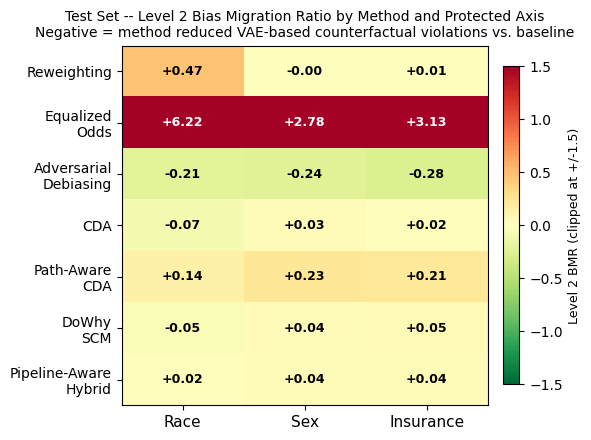

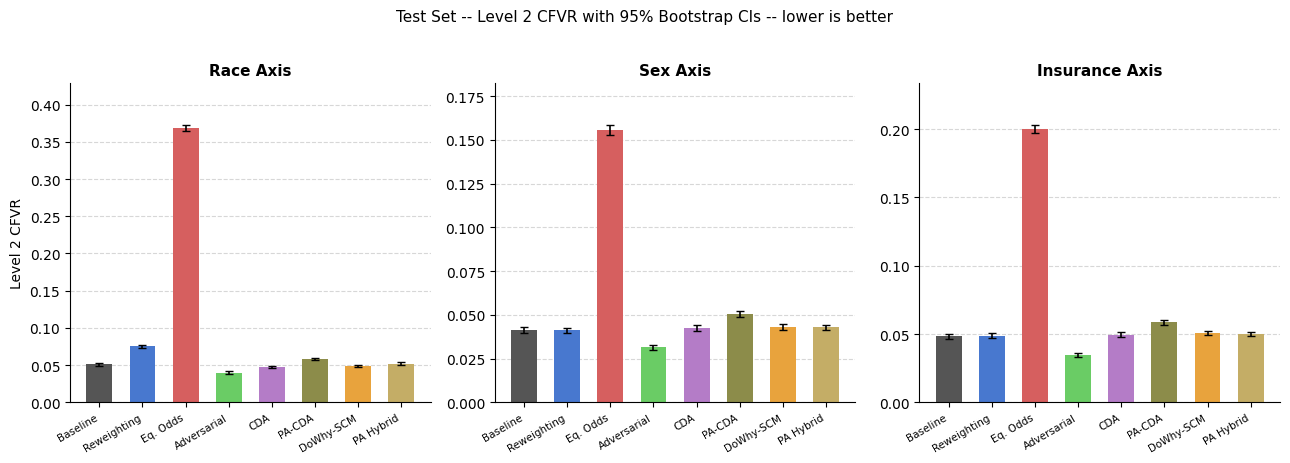

In [83]:
bmr_matrix_l2_test = np.array([
    [float(level2_df_test.loc[level2_df_test["method"]==m, "bmr_l2_race"].values[0]),
     float(level2_df_test.loc[level2_df_test["method"]==m, "bmr_l2_sex"].values[0]),
     float(level2_df_test.loc[level2_df_test["method"]==m, "bmr_l2_insurance"].values[0])]
    for m in methods_keys_t
])

cfvr_data_l2_test = {}
for ax_key in axes_list:
    cfvr_data_l2_test[ax_key] = {}
    for m in method_order_t:
        row = stat_df_l2_test[(stat_df_l2_test["method"]==m) & (stat_df_l2_test["axis"]==ax_key)].iloc[0]
        cfvr_data_l2_test[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1_l2t, ax1_l2t = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1_l2t.imshow(bmr_matrix_l2_test, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1_l2t.set_xticks(range(3))
ax1_l2t.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1_l2t.set_yticks(range(len(methods_keys_t)))
ax1_l2t.set_yticklabels(methods_short_t, fontsize=10)
for i in range(len(methods_keys_t)):
    for j in range(3):
        cell_val = bmr_matrix_l2_test[i, j]
        label = f"{cell_val:+.2f}" if abs(cell_val) < 10 else f"{cell_val:+.1f}"
        color = "white" if abs(cell_val) > 0.8 else "black"
        ax1_l2t.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1_l2t.colorbar(im, ax=ax1_l2t, fraction=0.04, pad=0.04)
cbar.set_label("Level 2 BMR (clipped at +/-1.5)", fontsize=9)
ax1_l2t.set_title("Test Set -- Level 2 Bias Migration Ratio by Method and Protected Axis\n"
                   "Negative = method reduced VAE-based counterfactual violations vs. baseline", fontsize=10)
fig1_l2t.tight_layout()
fig1_l2t.savefig("/kaggle/working/fig1_bmr_heatmap_level2_test.png", dpi=150, bbox_inches="tight")

ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes = [max(cfvr_data_l2_test[ax][m][2] for m in method_order_t) * 1.15 for ax in axes_list]

fig2_l2t, axes2_l2t = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(axes_list, ax_titles, ymaxes)):
    ax = axes2_l2t[col]
    for i, m in enumerate(method_order_t):
        mean, lo, hi = cfvr_data_l2_test[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order_t)))
    ax.set_xticklabels(method_labels_t, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("Level 2 CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2_l2t.suptitle("Test Set -- Level 2 CFVR with 95% Bootstrap CIs -- lower is better", fontsize=11, y=1.02)
fig2_l2t.tight_layout()
fig2_l2t.savefig("/kaggle/working/fig2_cfvr_bars_level2_test.png", dpi=150, bbox_inches="tight")
plt.show()

Same bootstrap and significance treatment on the test set, for both Level 1 and Level 2, reusing every function defined in the val section above.


In [84]:
boot_cfvr_l2_rs_test = bootstrap_pair(orig_scores_l2_test, cf_scores_l2_rs_test, combos_race_sex_enc_test, len(test), level2_methods, race_test_vae, sex_test_vae)
boot_cfvr_l2_ri_test = bootstrap_pair(orig_scores_l2_test, cf_scores_l2_ri_test, combos_race_ins_enc_test, len(test), level2_methods, race_test_vae, ins_test_vae)

stat_df_l2_rs_test = significance_table_pair(boot_cfvr_l2_rs_test, method_order, "race_x_sex")
stat_df_l2_ri_test = significance_table_pair(boot_cfvr_l2_ri_test, method_order, "race_x_ins")
stat_df_l2_intersect_test = pd.concat([stat_df_l2_rs_test, stat_df_l2_ri_test], ignore_index=True)

for ax_name, df_ in [("RACE x SEX", stat_df_l2_rs_test), ("RACE x INSURANCE", stat_df_l2_ri_test)]:
    print(f"\nTEST SET -- {ax_name}")
    print(df_[["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]].to_string(index=False))

stat_df_l2_intersect_test.to_parquet("/kaggle/working/statistical_results_level2_intersectional_test.parquet", index=False)


bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000
bootstrap 200/1000
bootstrap 400/1000
bootstrap 600/1000
bootstrap 800/1000
bootstrap 1000/1000

TEST SET -- RACE x SEX
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0577 0.0560 0.0597      0.0000      0.0000    NaN     0.000
          reweighting     0.0835 0.0812 0.0859     -0.0275     -0.0240  0.000    -0.101
       equalized_odds     0.5007 0.4970 0.5045     -0.4474     -0.4386  0.000    -1.087
adversarial_debiasing     0.0466 0.0449 0.0483      0.0093      0.0130  0.000     0.050
                  cda     0.0547 0.0529 0.0566      0.0018      0.0043  0.000     0.013
       path_aware_cda     0.0681 0.0663 0.0702     -0.0124     -0.0085  0.000    -0.043
            dowhy_scm     0.0558 0.0539 0.0576      0.0006      0.0033  0.004     0.009
pipeline_aware_hybrid     0.0599 0.0582 0.0618     -0.0031     -0.0014  0.000   